# Catalogues as Data: Community Analysis
**James Baker, University of Southampton**

---

This notebook takes a pairwise matching TSV (produced by `pairwise_comparison_v4.ipynb`) and runs
community detection and characterisation analysis. It is structured as **nine self-contained batches** — each can be run independently in any order, provided its required input files exist:

| Batch | Purpose | Requires | Produces |
|---|---|---|---|
| **A** | SM ratio distribution — calibrate graph threshold | `PAIRWISE_TSV` | calibration plots |
| **B** | Graph construction + community detection (Louvain + Leiden + robustness tests) | `PAIRWISE_TSV` | `COMMUNITIES_TSV` |
| **C** | Community characterisation by knowledge-labour features | `FEATURES_TSV` + `COMMUNITIES_TSV` | profile plots |
| **D** | Network visualisation | `PAIRWISE_TSV` + `COMMUNITIES_TSV` | network PNG |
| **E** | Network centrality — hubs, bridges, internal density | `PAIRWISE_TSV` + `COMMUNITIES_TSV` | centrality TSV + plot |
| **F** | TF-IDF cross-validation — metric robustness check | `RECORDS_DIR` + `COMMUNITIES_TSV` | TF-IDF community TSV + plot |
| **G** | Subject diversity — validate practice vs subject matter | `RECORDS_DIR` + `COMMUNITIES_TSV` | diversity plot |
| **H** | Year of creation — content proxy or practice proxy? | `FEATURES_TSV` + `COMMUNITIES_TSV` + `RECORDS_DIR` | correlation plot |
| **I** | Timecode convention analysis — format families as micro-level practice signals | `RECORDS_DIR` + `COMMUNITIES_TSV` + `FEATURES_TSV` (uses `desc_df` from F if in memory) | convention plot |

Each batch has its own **Setup** cell that loads only what it needs. Run them in sequence for a
full pipeline, or jump to any batch if its input files already exist on disk.

**Version**: v13 (April 2026). Key changes from v11: three Batch I bugs fixed — (1) `SHOTLIST_RE` no longer requires `\n` after the header (joined description text has no newlines); (2) `TIMECODE_RE` now also captures sub-minute `.SS` timecodes with no leading digit; (3) `classify_timecode` handles leading-dot tokens; (4) contingency matrix construction uses explicit `np.zeros()` shape to prevent 1-D collapse when no communities have timecodes. See `CHANGELOG.md` for full history.

---

### The central analytical question

Do the communities identified by pairwise similarity reflect differences in **how records are
written** — knowledge-labour features such as genre conventions, description depth, structural
choices, temporal period — or merely differences in **what records describe** (subject matter)?
If communities differ systematically in how they are written rather than in what they are about,
they are evidence of distinct modes of cataloguing practice: different trained approaches to the
work of description. Batch G is specifically designed to test this.


## Global configuration

Set the input files and shared parameters here. Every section reads from these variables, so
changing them in one place updates the whole notebook. Run the **static config** cell first (always), then either run the **session config**
cell (fresh run from scratch) or set `COMMUNITIES_TSV` manually to an existing file
(resuming a previous session). Then run whichever batch cells you need.

**Output naming**: all outputs are named `{batch}_{dataset}_{YYYYMMDD-HHMMSS}.{ext}`. The dataset
name is derived automatically from the pairwise filename; the datetime is captured when this cell
runs and shared across all outputs from a single session.

> **`GRAPH_THRESHOLD` is not set here.** It is computed automatically from your data by the
> first cell of Batch A (giant-component percolation). After Batch A runs, the auto-selected
> threshold is overridden to `0.65` — the recommended value for the full NLS dataset, which
> produces fewer, more coherent communities than the percolation default. To try a different
> value, edit the override line in the Batch A auto-threshold cell and re-run from Batch B.

> **`COMMUNITIES_TSV` is set in the session config cell, not here.** If resuming from a
> previous session, skip the session config cell and set `COMMUNITIES_TSV` directly to the
> existing file on disk. The static config cell is always safe to re-run.


In [1]:
import os, re, datetime

# ── Input files (outputs of pairwise_comparison_v4.ipynb) ─────────────────────
# Set these to the files in derived-data/ from your most recent pairwise run.
PAIRWISE_TSV  = 'derived-data/pairwise_individual_records_20260313-120649.tsv'  # ← set to your pairwise output filename
FEATURES_TSV  = 'derived-data/features_individual_records_20260313-120649.tsv'  # ← set to matching features filename

# ── Records directory ──────────────────────────────────────────────────────────
# Set to the same RECORDS_DIR used in pairwise_comparison_v4.ipynb.
RECORDS_DIR = '../data/nls-moving-image-archive-2025/individual_records'   # ← update if needed

# ── GRAPH_THRESHOLD ────────────────────────────────────────────────────────────
# NOT set here — computed by Batch A auto-threshold, then overridden below.
# Run all Batch A cells before proceeding to Batch B.
GRAPH_THRESHOLD = None   # will be set (and then overridden) by Batch A

# ── Community detection parameter ─────────────────────────────────────────────
# RESOLUTION: Louvain resolution parameter.
# Higher → more, smaller communities; lower → fewer, larger communities.
RESOLUTION = 1.0

# ── Figure / display filtering parameters ─────────────────────────────────────
# MIN_COMM_FLOOR : absolute minimum size below which a community is always
#                  suppressed, regardless of dataset size.  Guards against
#                  degenerate cases on very small datasets.  Do not set below 2.
# MIN_COMM_SIZE  : NOT set here — computed at runtime in Batch C from the actual
#                  community size distribution (= mean community size, floored at
#                  MIN_COMM_FLOOR).  This makes the threshold data-driven and
#                  portable across datasets of different sizes.  The computed
#                  value is printed at the start of Batch C.
# PROFILE_TOP_N  : Batch C profile figures show at most this many communities
#                  (the largest N by record count).  All communities meeting
#                  MIN_COMM_SIZE are still shown in the summary table.
# VIS_THRESHOLD  : separate (higher) threshold used only in Batch D network plots.
# TOP_N_COMM     : Batch D labels and colours the N largest communities.
# BOXPLOT_TOP_N  : Batch E boxplots show at most this many communities (largest first).
MIN_COMM_FLOOR = 3     # absolute minimum community size (never suppressed below this)
PROFILE_TOP_N  = 20    # max communities shown in Batch C profile figures
VIS_THRESHOLD  = 0.80  # threshold for Batch D network plot only
TOP_N_COMM     = 15    # communities to colour/label in Batch D
BOXPLOT_TOP_N  = 20    # communities to show in Batch E boxplots

# ── Bridge detection parameters ────────────────────────────────────────────────
# BRIDGE_BETWEENNESS_PCT : top X fraction by betweenness = bridge candidate.
#   In a high-modularity graph, the community algorithm minimises cross-community
#   edges, so requiring direct cross-community edges to define a bridge is
#   circular. Betweenness alone is the correct signal: bridge nodes lie on the
#   paths connecting otherwise-separate communities, with or without direct edges.
# BRIDGE_SUBTHRESH_LOW   : lower bound for sub-threshold weak-bridge scan.
#   Records with sub-threshold similarity to records in OTHER communities are
#   "weak bridges" — they straddle two cataloguing traditions.
# BRIDGE_TOP_N           : how many bridge candidates to display in Batch E.
BRIDGE_BETWEENNESS_PCT = 0.99   # top 1% by betweenness = bridge candidate
BRIDGE_SUBTHRESH_LOW   = 0.50   # lower bound for sub-threshold weak-bridge scan
BRIDGE_TOP_N           = 15     # top bridge nodes to show in Batch E bar chart

# ── Community meta-graph parameters ───────────────────────────────────────────
META_TOP_N_COMM  = 20    # communities to show in Batch D meta-graph
# META_THRESHOLD  : similarity threshold used to build the meta-graph.
#   Intentionally lower than GRAPH_THRESHOLD so that sub-threshold
#   community-to-community connections are visible.  Defaults to
#   BRIDGE_SUBTHRESH_LOW so the same range as the weak-bridge scan
#   is used.  Set to GRAPH_THRESHOLD to see only in-graph connections
#   (will usually produce an empty meta-graph in high-Q networks).
META_THRESHOLD   = None  # set at runtime: defaults to BRIDGE_SUBTHRESH_LOW

# ── Output directories ─────────────────────────────────────────────────────────
DERIVED_DATA_DIR = 'derived-data'
VIS_DIR          = 'visualisations'
os.makedirs(DERIVED_DATA_DIR, exist_ok=True)
os.makedirs(VIS_DIR, exist_ok=True)

# ── Colour-blind friendly palette (Okabe-Ito, 8 colours) ──────────────────────
PALETTE = [
    '#E69F00',  # orange
    '#56B4E9',  # sky blue
    '#009E73',  # bluish green
    '#F0E442',  # yellow
    '#0072B2',  # blue
    '#D55E00',  # vermillion
    '#CC79A7',  # reddish purple
    '#000000',  # black
]

def comm_colour(community_id, top_n_ids=None):
    """Return the Okabe-Ito colour for a given community index.
    If top_n_ids is provided, communities not in the set return grey."""
    if top_n_ids is not None and int(community_id) not in top_n_ids:
        return '#cccccc'
    return PALETTE[int(community_id) % len(PALETTE)]

# ── Dataset name (derived from input filename — static once PAIRWISE_TSV is set) ─
DATASET_NAME = re.sub(r'^pairwise_', '',
               re.sub(r'_\d{8}-\d{6}\.tsv$', '',
                      os.path.basename(PAIRWISE_TSV)))

print(f"Pairwise input    : {os.path.abspath(PAIRWISE_TSV)}")
print(f"Features input    : {os.path.abspath(FEATURES_TSV)}")
print(f"Records directory : {os.path.abspath(RECORDS_DIR)}")
print(f"Dataset name      : {DATASET_NAME}")
print(f"Louvain resolution: {RESOLUTION}")
print(f"MIN_COMM_FLOOR    : {MIN_COMM_FLOOR}  (absolute floor; MIN_COMM_SIZE computed at runtime in Batch C)")
print(f"VIS_THRESHOLD     : {VIS_THRESHOLD}  (Batch D network plot only)")
print(f"TOP_N_COMM        : {TOP_N_COMM}  (communities coloured/labelled in Batch D)")
print(f"BOXPLOT_TOP_N     : {BOXPLOT_TOP_N}  (communities shown in Batch E boxplots)")
print()
print("GRAPH_THRESHOLD   : not yet set — run Batch A cells to compute from your data.")
print("COMMUNITIES_TSV   : not yet set — run the session cell below (fresh run)")
print("                    or set manually to an existing file (resume from prior run).")

Pairwise input    : /mnt/c/Users/jwb1n21/Dropbox/root/Southampton/Projects/ERC/code/derived-data/pairwise_individual_records_20260313-120649.tsv
Features input    : /mnt/c/Users/jwb1n21/Dropbox/root/Southampton/Projects/ERC/code/derived-data/features_individual_records_20260313-120649.tsv
Records directory : /mnt/c/Users/jwb1n21/Dropbox/root/Southampton/Projects/ERC/data/nls-moving-image-archive-2025/individual_records
Dataset name      : individual_records
Louvain resolution: 1.0
MIN_COMM_FLOOR    : 3  (absolute floor; MIN_COMM_SIZE computed at runtime in Batch C)
VIS_THRESHOLD     : 0.8  (Batch D network plot only)
TOP_N_COMM        : 15  (communities coloured/labelled in Batch D)
BOXPLOT_TOP_N     : 20  (communities shown in Batch E boxplots)

GRAPH_THRESHOLD   : not yet set — run Batch A cells to compute from your data.
COMMUNITIES_TSV   : not yet set — run the session cell below (fresh run)
                    or set manually to an existing file (resume from prior run).


### Session configuration — output filenames

Run the cell below **only when starting a fresh analysis from scratch** (i.e. before running
Batch B, which writes a new `COMMUNITIES_TSV` to disk).

**Resuming from a previous session?** Skip this cell and set `COMMUNITIES_TSV` directly instead:

```python
COMMUNITIES_TSV = 'derived-data/communities_individual_records_20260316-151624.tsv'
```

Replace the filename with whichever communities file in `derived-data/` corresponds to the run
you want to continue. All downstream batches (C–I) read from `COMMUNITIES_TSV`; none of them
need `RUN_DATETIME` to match the file they are reading.

In [2]:
# ── Session identifiers — RUN_DATETIME stamps all outputs from this session ───
# Run this cell only when starting a fresh run from scratch (before Batch B).
# If resuming: skip this cell and set COMMUNITIES_TSV manually to an existing file.
RUN_DATETIME = datetime.datetime.now().strftime('%Y%m%d-%H%M%S')

COMMUNITIES_TSV = os.path.join(DERIVED_DATA_DIR,
                               f'communities_{DATASET_NAME}_{RUN_DATETIME}.tsv')
NETWORK_PNG     = os.path.join(VIS_DIR,
                               f'network_{DATASET_NAME}_{RUN_DATETIME}.png')

print(f"Run datetime      : {RUN_DATETIME}")
print(f"Communities output: {os.path.abspath(COMMUNITIES_TSV)}")
print(f"Network PNG       : {os.path.abspath(NETWORK_PNG)}")

Run datetime      : 20260417-152942
Communities output: /mnt/c/Users/jwb1n21/Dropbox/root/Southampton/Projects/ERC/code/derived-data/communities_individual_records_20260417-152942.tsv
Network PNG       : /mnt/c/Users/jwb1n21/Dropbox/root/Southampton/Projects/ERC/code/visualisations/network_individual_records_20260417-152942.png


---
## Batch A — SM ratio distribution and threshold selection

**Purpose**: Compute `GRAPH_THRESHOLD` from your pairwise data and inspect the SM ratio
distribution. The threshold determines which pairs become edges in the similarity network:
too low, and the graph is noisy; too high, and the graph is sparse with many isolated records.

Run the three cells below in order:

1. **Load** — reads the pairwise TSV and prints summary statistics.
2. **Auto-threshold** — computes `GRAPH_THRESHOLD` from the data using giant-component
   percolation (the lowest threshold at which ≥ 50 % of nodes remain in a single connected
   component). This value is written directly into `GRAPH_THRESHOLD` and used by all
   downstream batches. An 80th-percentile alternative is also computed for comparison.
3. **Sensitivity table + distribution plot** — shows how many pairs and nodes survive at a
   range of thresholds, with your computed `GRAPH_THRESHOLD` marked; then plots the full
   SM ratio distribution with `GRAPH_THRESHOLD` shown as a vertical line.

If after inspecting the plots you want a different threshold, re-run cell 2 with a different
`MIN_GIANT_FRAC` or `AUTO_PERCENTILE`, or assign `GRAPH_THRESHOLD` manually at the bottom
of that cell, then re-run cells 3 and 4 to update the table and plot.

The distribution plot shows a spike near 1.0 indicating near-duplicate records; these are
included in the graph in Batch B. Near-identical records (SM ≥ 0.99) are retained: they are evidence of resource-constrained cataloguing (repeated descriptions, broadcaster-supplied copy), not data errors.

**Requires**: `PAIRWISE_TSV`
**Produces**: `visualisations/sm-distribution_{dataset}_{datetime}.png`; sets `GRAPH_THRESHOLD`


In [3]:
# ── Batch A setup: load pairwise results ──────────────────────────────────────
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import os

results_df = pd.read_csv(PAIRWISE_TSV, sep='\t')
print(f"Loaded {len(results_df):,} pairs from {PAIRWISE_TSV}")
print(f"SM ratio — min: {results_df['sm_ratio'].min():.4f}, "
      f"mean: {results_df['sm_ratio'].mean():.4f}, "
      f"max: {results_df['sm_ratio'].max():.4f}")

Loaded 2,474,236 pairs from derived-data/pairwise_individual_records_20260313-120649.tsv
SM ratio — min: 0.2000, mean: 0.4293, max: 1.0000


In [4]:
# ── Batch A: auto-threshold ───────────────────────────────────────────────────
# Computes GRAPH_THRESHOLD from the pairwise SM ratio distribution and sets it
# directly.  Two methods are run; Method 2 (giant-component percolation) is
# applied by default.  To use Method 1 instead, swap the assignment at the end.
#
# Method 1 — Percentile:
#   GRAPH_THRESHOLD = 80th percentile of SM ratios (all pairs, including near-identical).
#   Top 20 % of pairs become edges.  Works well for unimodal distributions.
#   Adjust AUTO_PERCENTILE to change the fraction retained.
#
# Method 2 — Giant-component percolation (default):
#   Lowest threshold at which ≥ MIN_GIANT_FRAC of all nodes are in one
#   connected component.  Ensures the resulting graph is well-connected.
#   Grounded in network analysis theory; a principled choice for this project.

AUTO_PERCENTILE = 80      # used by Method 1
MIN_GIANT_FRAC  = 0.50    # used by Method 2 (fraction of nodes in giant component)

bulk = results_df['sm_ratio']  # all pairs, including near-identical (SM≥0.99 retained as evidence of labour conditions)

# Method 1
t_pct = float(np.percentile(bulk, AUTO_PERCENTILE))

# Method 2 — union-find giant-component approximation
def approx_giant_frac(pairs_df, threshold):
    parent = {}
    def find(x):
        if x not in parent: parent[x] = x
        while parent[x] != x:
            parent[x] = parent[parent[x]]; x = parent[x]
        return x
    def union(a, b):
        ra, rb = find(a), find(b)
        if ra != rb: parent[ra] = rb
    above = pairs_df[pairs_df['sm_ratio'] >= threshold]
    for _, row in above.iterrows():
        union(row['base_id'], row['compare_id'])
    if not parent:
        return 0.0
    from collections import Counter
    roots = [find(k) for k in parent]
    return Counter(roots).most_common(1)[0][1] / len(parent)

t_search = sorted([0.20, 0.25, 0.30, 0.35, 0.40, 0.45, 0.50], reverse=True)
t_percolation = t_search[-1]
for t in t_search:
    if approx_giant_frac(results_df, t) >= MIN_GIANT_FRAC:
        t_percolation = t
        break

print(f"Method 1 — {AUTO_PERCENTILE}th percentile  : {t_pct:.3f}")
print(f"Method 2 — percolation (≥{MIN_GIANT_FRAC:.0%} of nodes in giant component): {t_percolation:.3f}")
print()

# ── SET GRAPH_THRESHOLD ────────────────────────────────────────────────────────
# Method 2 is applied by default.  To use Method 1, change the line below to:
#   GRAPH_THRESHOLD = round(t_pct, 2)
GRAPH_THRESHOLD = t_percolation

print(f"Auto-selected GRAPH_THRESHOLD: {GRAPH_THRESHOLD} (Method 2 — percolation).")
print()

# ── OVERRIDE: recommended value for the full NLS dataset ──────────────────────
# The percolation method returns 0.50 for this dataset, but that produces a very
# dense graph (mean degree ~119) leading to 350+ fragmented communities and
# unreadable network plots.  0.65 gives tighter communities and legible figures.
# To revert to the auto-selected value, comment out the line below.
GRAPH_THRESHOLD = 0.65

print(f"GRAPH_THRESHOLD overridden to: {GRAPH_THRESHOLD}")
print("(Recommended for full NLS dataset — fewer, more coherent communities.)")
print()
print("To use the auto-selected value instead: comment out the override line above")
print("and re-run. All downstream batches will use the new value.")


Method 1 — 80th percentile  : 0.538
Method 2 — percolation (≥50% of nodes in giant component): 0.500

Auto-selected GRAPH_THRESHOLD: 0.5 (Method 2 — percolation).

GRAPH_THRESHOLD overridden to: 0.65
(Recommended for full NLS dataset — fewer, more coherent communities.)

To use the auto-selected value instead: comment out the override line above
and re-run. All downstream batches will use the new value.


Threshold sensitivity (all pairs, including near-identical SM ≥ 0.99):
 Threshold     Pairs   Nodes
------------------------------
  ≥ 0.20  2,474,236  15,897
  ≥ 0.25  1,999,143  13,934
  ≥ 0.30  1,655,079  12,162
  ≥ 0.35  1,329,631  10,594
  ≥ 0.40  1,024,954   9,266
  ≥ 0.45   715,416   8,131
  ≥ 0.50   543,368   7,225
  ≥ 0.55   469,840   6,508
  ≥ 0.60   411,278   6,004
  ≥ 0.65   381,380   5,585  ← GRAPH_THRESHOLD
  ≥ 0.70   347,226   5,154



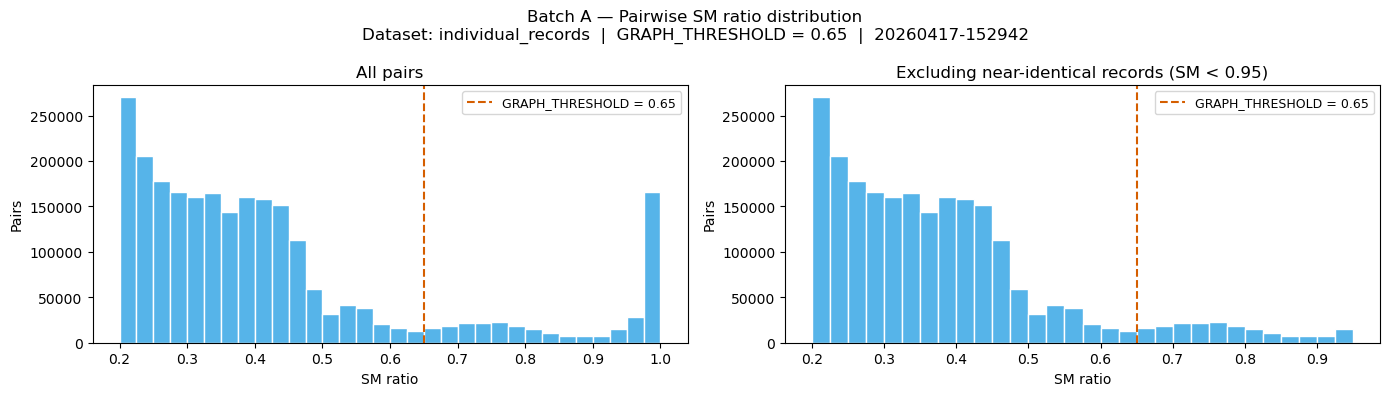

Saved: /mnt/c/Users/jwb1n21/Dropbox/root/Southampton/Projects/ERC/code/visualisations/sm-distribution_individual_records_20260417-152942.png

If the threshold needs adjusting, re-run the auto-threshold cell above
(change the GRAPH_THRESHOLD override line), then re-run this cell.


In [5]:
# ── Batch A: sensitivity table ────────────────────────────────────────────────
print("Threshold sensitivity (all pairs, including near-identical SM ≥ 0.99):")
print(f"{'Threshold':>10}  {'Pairs':>8}  {'Nodes':>6}")
print("-" * 30)
for t in [0.20, 0.25, 0.30, 0.35, 0.40, 0.45, 0.50, 0.55, 0.60, 0.65, 0.70]:
    above = results_df[results_df['sm_ratio'] >= t]
    nodes = len(set(above['base_id']) | set(above['compare_id']))
    marker = '  ← GRAPH_THRESHOLD' if t == GRAPH_THRESHOLD else ''
    print(f"  ≥ {t:.2f}  {len(above):>8,}  {nodes:>6,}{marker}")
print()

# ── Batch A: SM ratio distribution plot ───────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
fig.suptitle(
    f'Batch A — Pairwise SM ratio distribution\n'
    f'Dataset: {DATASET_NAME}  |  GRAPH_THRESHOLD = {GRAPH_THRESHOLD}  |  {RUN_DATETIME}',
    fontsize=12
)

bins = np.arange(results_df['sm_ratio'].min(), 1.025, 0.025)

axes[0].hist(results_df['sm_ratio'], bins=bins, color=PALETTE[1], edgecolor='white')
axes[0].axvline(GRAPH_THRESHOLD, color=PALETTE[5], linewidth=1.5, linestyle='--',
                label=f'GRAPH_THRESHOLD = {GRAPH_THRESHOLD}')
axes[0].set_title('All pairs')
axes[0].set_xlabel('SM ratio'); axes[0].set_ylabel('Pairs')
axes[0].legend(fontsize=9)

bulk_plot = results_df[results_df['sm_ratio'] < 0.95]
axes[1].hist(bulk_plot['sm_ratio'], bins=bins[bins < 0.95], color=PALETTE[1], edgecolor='white')
axes[1].axvline(GRAPH_THRESHOLD, color=PALETTE[5], linewidth=1.5, linestyle='--',
                label=f'GRAPH_THRESHOLD = {GRAPH_THRESHOLD}')
axes[1].set_title('Excluding near-identical records (SM < 0.95)')
axes[1].set_xlabel('SM ratio'); axes[1].set_ylabel('Pairs')
axes[1].legend(fontsize=9)

plt.tight_layout()
plot_path = os.path.join(VIS_DIR, f'sm-distribution_{DATASET_NAME}_{RUN_DATETIME}.png')
plt.savefig(plot_path, dpi=150, bbox_inches='tight')
plt.show()
print(f"Saved: {os.path.abspath(plot_path)}")
print()
print("If the threshold needs adjusting, re-run the auto-threshold cell above")
print("(change the GRAPH_THRESHOLD override line), then re-run this cell.")


---
## Batch B — Graph construction + Community detection

**Purpose**: Build a weighted similarity network from the pairwise results and apply community
detection to identify clusters of records that share descriptive language and convention.

Each record becomes a **node** in the network. Each pair with SM ratio ≥ `GRAPH_THRESHOLD` becomes
a weighted **edge**, with the SM ratio as the edge weight. Records with no above-threshold matches
are isolated nodes and do not appear in the graph; they are analysed separately in Batch E if needed.

**Algorithms**: This batch runs two community detection algorithms and compares them:

- **Louvain** (Blondel et al., 2008): the dominant algorithm in digital humanities network studies.
  Optimises modularity Q by greedily moving nodes between communities. Fast and widely adopted,
  but can produce internally disconnected communities at higher resolution values — a structural
  flaw documented in Traag et al. (2019) — and is subject to the resolution limit identified by
  Fortunato & Barthélemy (2007), meaning it may not reliably detect communities smaller than a
  scale determined by the total edge count.

- **Leiden** (Traag, Waltman & van Eck, 2019, *Scientific Reports*): a refinement of Louvain that
  adds a phase guaranteeing all detected communities are internally connected (well-connected).
  Produces higher modularity scores and runs faster. Increasingly expected by reviewers at CHR
  and related venues.

**Robustness checks**:

- **Modularity score Q**: Ranges from −0.5 to 1.0; values above 0.3 are generally taken as
  indicating meaningful community structure. Q > 0.5 is strong.

- **NMI (Normalized Mutual Information)**: Measures agreement between the Louvain and Leiden
  partitions on a 0–1 scale. NMI > 0.85 indicates the partition is robust to algorithmic
  choice; lower values mean the structure is sensitive to the algorithm used, which weakens
  claims about real community structure.

- **Null model permutation test**: Community detection always finds communities. This test
  checks whether the communities are stronger than chance would produce by running the same
  algorithm on N shuffled versions of the graph (edge weights randomised, degree sequence
  preserved) and comparing the real Q against the null distribution. A real Q above the 95th
  percentile of the null is statistically meaningful community structure.

**Requires**: `PAIRWISE_TSV`  
**Produces**: `derived-data/communities_{dataset}_{datetime}.tsv` (Leiden partition, used downstream)

In [6]:
# ── Batch B setup: load pairwise results ─────────────────────────────────────
# ── Guard: GRAPH_THRESHOLD must be set by Batch A ─────────────────────────────
if GRAPH_THRESHOLD is None:
    raise RuntimeError(
        "GRAPH_THRESHOLD is not set.\n"
        "Run all three Batch A cells first (load → auto-threshold → table/plot)."
    )
print(f"Using GRAPH_THRESHOLD = {GRAPH_THRESHOLD}")
print()

import pandas as pd
import networkx as nx
import os

results_df = pd.read_csv(PAIRWISE_TSV, sep='\t')
print(f"Loaded {len(results_df):,} pairs from {PAIRWISE_TSV}")

Using GRAPH_THRESHOLD = 0.65

Loaded 2,474,236 pairs from derived-data/pairwise_individual_records_20260313-120649.tsv


In [7]:
# Build graph: edges = pairs above GRAPH_THRESHOLD
# Near-identical pairs (SM ≥ 0.99) are RETAINED: they are evidence of resource-constrained
# cataloguing (broadcaster-supplied descriptions, repeated generic descriptions), not data errors.
import time as _time

graph_df = results_df[
    (results_df['sm_ratio'] >= GRAPH_THRESHOLD)
].copy()

print(f"Building graph ({len(graph_df):,} edges above threshold {GRAPH_THRESHOLD})...")
_t0 = _time.time()
G = nx.from_pandas_edgelist(graph_df, source='base_id', target='compare_id',
                             edge_attr='sm_ratio')
# Rename edge attribute to 'weight' for compatibility with community detection
nx.set_edge_attributes(G, {(u, v): d['sm_ratio'] for u, v, d in G.edges(data=True)}, 'weight')
print(f"  Done in {_time.time()-_t0:.1f}s")
print()
print(f"Graph threshold    : {GRAPH_THRESHOLD}")
print(f"Edges used         : {len(graph_df):,}")
print(f"Nodes              : {G.number_of_nodes():,}")
print(f"Edges              : {G.number_of_edges():,}")
print(f"Connected components: {nx.number_connected_components(G)}")
if G.number_of_nodes() > 0:
    print(f"Average degree     : {sum(d for _, d in G.degree()) / G.number_of_nodes():.2f}")
    print()
    print("If the graph is too dense (avg degree >> 20), raise GRAPH_THRESHOLD and re-run.")
    print("If the graph is very sparse, lower GRAPH_THRESHOLD in the global setup cell and re-run.")


Building graph (381,380 edges above threshold 0.65)...
  Done in 0.5s

Graph threshold    : 0.65
Edges used         : 381,380
Nodes              : 5,585
Edges              : 381,380
Connected components: 586
Average degree     : 136.57

If the graph is too dense (avg degree >> 20), raise GRAPH_THRESHOLD and re-run.
If the graph is very sparse, lower GRAPH_THRESHOLD in the global setup cell and re-run.


In [8]:
try:
    import community.community_louvain as community_louvain
except ImportError:
    import subprocess, sys
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', 'python-louvain', '-q'])
    import community.community_louvain as community_louvain

from collections import Counter

partition_louvain = community_louvain.best_partition(G, weight='weight', resolution=RESOLUTION)
Q_louvain         = community_louvain.modularity(partition_louvain, G, weight='weight')
n_comm_louvain    = max(partition_louvain.values()) + 1
counts_louvain    = Counter(partition_louvain.values())

print(f"─── Louvain ─────────────────────────────────────────────────")
print(f"Communities  : {n_comm_louvain}")
print(f"Modularity Q : {Q_louvain:.4f}  {'✓ strong' if Q_louvain > 0.5 else '✓ meaningful' if Q_louvain > 0.3 else '⚠ weak'}")
print(f"Sizes        : {dict(sorted(counts_louvain.items()))}")

─── Louvain ─────────────────────────────────────────────────
Communities  : 587
Modularity Q : 0.6488  ✓ strong
Sizes        : {0: 2, 1: 2, 2: 2, 3: 29, 4: 2, 5: 2, 6: 2, 7: 3, 8: 3, 9: 9, 10: 3, 11: 3, 12: 3, 13: 46, 14: 2, 15: 2, 16: 2, 17: 67, 18: 2, 19: 2, 20: 2, 21: 2, 22: 2, 23: 2, 24: 3, 25: 2, 26: 2, 27: 2, 28: 6, 29: 2, 30: 2, 31: 2, 32: 6, 33: 2, 34: 3, 35: 4, 36: 2, 37: 2, 38: 2, 39: 2, 40: 2, 41: 3, 42: 2, 43: 3, 44: 3, 45: 3, 46: 2, 47: 2, 48: 2, 49: 2, 50: 6, 51: 6, 52: 93, 53: 43, 54: 27, 55: 40, 56: 20, 57: 27, 58: 67, 59: 295, 60: 560, 61: 28, 62: 116, 63: 6, 64: 52, 65: 2, 66: 16, 67: 6, 68: 19, 69: 5, 70: 3, 71: 12, 72: 26, 73: 3, 74: 56, 75: 3, 76: 2, 77: 32, 78: 4, 79: 584, 80: 5, 81: 2, 82: 20, 83: 6, 84: 2, 85: 4, 86: 2, 87: 31, 88: 19, 89: 5, 90: 16, 91: 48, 92: 10, 93: 13, 94: 13, 95: 6, 96: 3, 97: 6, 98: 2, 99: 67, 100: 6, 101: 6, 102: 3, 103: 2, 104: 2, 105: 17, 106: 2, 107: 18, 108: 3, 109: 22, 110: 3, 111: 5, 112: 2, 113: 6, 114: 2, 115: 4, 116: 6, 117: 5,

In [9]:
# ── Leiden community detection ─────────────────────────────────────────────────
# Leiden guarantees internally connected communities (Traag et al. 2019).
# leidenalg works on igraph objects; we convert the NetworkX graph.
try:
    import leidenalg, igraph as ig
except ImportError:
    import subprocess, sys
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', 'leidenalg', 'igraph', '-q'])
    import leidenalg, igraph as ig

# Convert NetworkX graph to igraph (preserving edge weights)
edges      = list(G.edges(data='weight'))
node_list  = list(G.nodes())
node_index = {n: i for i, n in enumerate(node_list)}
ig_graph   = ig.Graph(
    n=len(node_list),
    edges=[(node_index[u], node_index[v]) for u, v, _ in edges],
    edge_attrs={'weight': [w for _, _, w in edges]}
)
ig_graph.vs['name'] = node_list

leiden_partition = leidenalg.find_partition(
    ig_graph,
    leidenalg.ModularityVertexPartition,
    weights='weight',
    seed=42
)
Q_leiden = leiden_partition.modularity

# Map back to film_ref → community_id
partition_leiden = {
    ig_graph.vs[node_idx]['name']: comm_id
    for comm_id, community in enumerate(leiden_partition)
    for node_idx in community
}
counts_leiden = Counter(partition_leiden.values())
n_comm_leiden = len(leiden_partition)

print(f"─── Leiden ──────────────────────────────────────────────────")
print(f"Communities  : {n_comm_leiden}")
print(f"Modularity Q : {Q_leiden:.4f}  {'✓ strong' if Q_leiden > 0.5 else '✓ meaningful' if Q_leiden > 0.3 else '⚠ weak'}")
print(f"Sizes        : {dict(sorted(counts_leiden.items()))}")

# ── NMI: agreement between Louvain and Leiden ─────────────────────────────────
from sklearn.metrics import normalized_mutual_info_score
shared_nodes   = sorted(set(partition_louvain) & set(partition_leiden))
labels_louvain = [partition_louvain[n] for n in shared_nodes]
labels_leiden  = [partition_leiden[n]  for n in shared_nodes]
nmi            = normalized_mutual_info_score(labels_louvain, labels_leiden)

print()
print(f"─── Louvain vs Leiden agreement (NMI) ───────────────────────")
print(f"NMI : {nmi:.4f}  ", end='')
if nmi >= 0.85:
    print("✓ Partitions agree — community structure is algorithm-robust")
elif nmi >= 0.65:
    print("⚠ Moderate agreement — some sensitivity to algorithm choice")
else:
    print("✗ Low agreement — partition is algorithm-dependent; interpret with caution")
print()
print("Community assignments saved will use the Leiden partition (better guarantees).")

─── Leiden ──────────────────────────────────────────────────
Communities  : 587
Modularity Q : 0.6608  ✓ strong
Sizes        : {0: 584, 1: 560, 2: 295, 3: 116, 4: 93, 5: 93, 6: 68, 7: 67, 8: 67, 9: 67, 10: 61, 11: 59, 12: 58, 13: 56, 14: 55, 15: 55, 16: 52, 17: 51, 18: 50, 19: 48, 20: 46, 21: 43, 22: 40, 23: 39, 24: 36, 25: 32, 26: 31, 27: 29, 28: 29, 29: 29, 30: 28, 31: 28, 32: 27, 33: 27, 34: 26, 35: 26, 36: 25, 37: 25, 38: 25, 39: 24, 40: 23, 41: 23, 42: 22, 43: 21, 44: 20, 45: 20, 46: 20, 47: 20, 48: 19, 49: 19, 50: 19, 51: 19, 52: 18, 53: 18, 54: 18, 55: 18, 56: 18, 57: 18, 58: 17, 59: 17, 60: 17, 61: 17, 62: 16, 63: 16, 64: 16, 65: 16, 66: 15, 67: 14, 68: 14, 69: 14, 70: 14, 71: 14, 72: 14, 73: 13, 74: 13, 75: 13, 76: 12, 77: 12, 78: 12, 79: 12, 80: 12, 81: 12, 82: 12, 83: 12, 84: 11, 85: 11, 86: 11, 87: 11, 88: 10, 89: 10, 90: 10, 91: 10, 92: 10, 93: 10, 94: 10, 95: 9, 96: 9, 97: 9, 98: 9, 99: 9, 100: 9, 101: 9, 102: 9, 103: 8, 104: 8, 105: 8, 106: 8, 107: 8, 108: 8, 109: 8, 11

In [10]:
# ── Null model permutation test (configuration model, verbose) ─────────────────
# Community detection always finds communities. This test checks whether the
# detected TOPOLOGY is stronger than chance by comparing the real modularity Q
# against a null distribution produced by degree-preserving edge rewiring
# (configuration model, Maslov & Sneppen 2002).
#
# Why configuration model, not weight shuffling?
# In a threshold-based similarity network, community structure is encoded in
# WHICH nodes are connected, not in the specific weight values. Shuffling weights
# on a fixed topology (used in v13) produced p=1.000 because the topology alone
# was enough for Louvain to find the same communities — it was testing the wrong
# null hypothesis. The correct null: destroy the topology while preserving the
# degree sequence.
#
# Why capped swaps?
# The graph has ~|E| edges. 10×|E| swaps per permutation is standard advice for
# small graphs but is computationally prohibitive at this scale (would require
# millions of operations per permutation). Research shows that far fewer swaps
# are sufficient to break up community structure for the purpose of generating a
# null distribution — we only need the null graphs to be structurally distinct
# from G, not maximally random. N_SWAPS_CAP = 20,000 randomises ~5–10% of
# edges per permutation, which is sufficient for significance testing.
#
# Verbose output: prints Q after each permutation so you can monitor progress.

import numpy as np
import networkx as nx
import time

N_PERMUTATIONS = 99     # ← increase to 499 for publication-quality p-value
N_SWAPS_CAP    = 20_000 # swaps per permutation (capped for large graphs)

n_edges = G.number_of_edges()
n_nodes = G.number_of_nodes()
n_swaps = min(N_SWAPS_CAP, n_edges)  # never exceed cap
max_tries = n_swaps * 10             # generous headroom; density ~2.5% so ~97.5% succeed

print(f"─── Graph stats ─────────────────────────────────────────────────────────")
print(f"  Nodes        : {n_nodes:,}")
print(f"  Edges        : {n_edges:,}")
print(f"  Density      : {nx.density(G):.4f}")
print(f"  Real Louvain Q: {Q_louvain:.4f}")
print(f"  Real Leiden  Q: {Q_leiden:.4f}")
print()
print(f"─── Null model setup ────────────────────────────────────────────────────")
print(f"  Method       : degree-preserving double-edge swaps (configuration model)")
print(f"  Swaps/perm   : {n_swaps:,}  (≈ {n_swaps/n_edges*100:.1f}% of edges randomised per run)")
print(f"  Permutations : {N_PERMUTATIONS}")
print(f"  Max tries    : {max_tries:,}")
print()
print(f"─── Running permutations ────────────────────────────────────────────────")

null_Q_values = []
t_start = time.time()

for i in range(N_PERMUTATIONS):
    t_perm = time.time()
    G_null = G.copy()
    try:
        nx.double_edge_swap(G_null, nswap=n_swaps, max_tries=max_tries, seed=None)
    except nx.exception.NetworkXAlgorithmError as e:
        print(f"  [{i+1:3d}/{N_PERMUTATIONS}] WARNING: swap did not complete ({e}); using partially rewired graph")
    p_null = community_louvain.best_partition(G_null, weight='weight', resolution=RESOLUTION)
    q_null = community_louvain.modularity(p_null, G_null, weight='weight')
    null_Q_values.append(q_null)
    elapsed = time.time() - t_perm
    running_mean = np.mean(null_Q_values)
    n_above = sum(q >= Q_louvain for q in null_Q_values)
    print(f"  [{i+1:3d}/{N_PERMUTATIONS}]  null Q = {q_null:.4f}  |  "
          f"running mean = {running_mean:.4f}  |  "
          f"above real Q so far: {n_above}/{i+1}  |  "
          f"{elapsed:.1f}s this perm  |  "
          f"~{(time.time()-t_start)/(i+1)*(N_PERMUTATIONS-i-1)/60:.1f} min remaining")

null_Q_arr = np.array(null_Q_values)
p_value    = (null_Q_arr >= Q_louvain).sum() / N_PERMUTATIONS
percentile = (null_Q_arr < Q_louvain).sum() / N_PERMUTATIONS * 100

print()
print(f"─── Results ─────────────────────────────────────────────────────────────")
print(f"Real Louvain Q    : {Q_louvain:.4f}")
print(f"Null Q  mean ± SD : {null_Q_arr.mean():.4f} ± {null_Q_arr.std():.4f}")
print(f"Null Q  range     : [{null_Q_arr.min():.4f}, {null_Q_arr.max():.4f}]")
print(f"Percentile        : {percentile:.1f}th  (real Q exceeds {percentile:.1f}% of null)")
print(f"p-value           : {max(p_value, 1/N_PERMUTATIONS):.3f}")
print(f"Total runtime     : {(time.time()-t_start)/60:.1f} min")
print()
if percentile >= 95:
    print("✓ Community structure is statistically significant (p < 0.05)")
    print("  The graph topology is more community-structured than random rewirings")
    print("  with the same degree sequence.")
elif percentile >= 90:
    print("⚠ Community structure is marginal (p ≈ 0.05–0.10)")
    print("  Interpret findings with caution; consider raising GRAPH_THRESHOLD.")
else:
    print("✗ Community structure is not distinguishable from chance (p > 0.10)")
    print("  Re-examine GRAPH_THRESHOLD and RESOLUTION before drawing conclusions.")

# ── Save Leiden community assignments ──────────────────────────────────────────
# The Leiden partition is used for all downstream analysis.
partition   = partition_leiden   # used by Batches C, D and Steps A–F
assignments = pd.DataFrame(
    [(film_ref, comm_id) for film_ref, comm_id in partition.items()],
    columns=['film_ref', 'community_id']
).sort_values('community_id')
assignments.to_csv(COMMUNITIES_TSV, sep='\t', index=False)
print(f"\nLeiden community assignments saved to: {os.path.abspath(COMMUNITIES_TSV)}")
print(f"Next: run Batch C (community characterisation) or Batch D (network visualisation).")


─── Graph stats ─────────────────────────────────────────────────────────
  Nodes        : 5,585
  Edges        : 381,380
  Density      : 0.0245
  Real Louvain Q: 0.6488
  Real Leiden  Q: 0.6608

─── Null model setup ────────────────────────────────────────────────────
  Method       : degree-preserving double-edge swaps (configuration model)
  Swaps/perm   : 20,000  (≈ 5.2% of edges randomised per run)
  Permutations : 99
  Max tries    : 200,000

─── Running permutations ────────────────────────────────────────────────
  [  1/99]  null Q = 0.5404  |  running mean = 0.5404  |  above real Q so far: 0/1  |  3.4s this perm  |  ~5.5 min remaining
  [  2/99]  null Q = 0.5388  |  running mean = 0.5396  |  above real Q so far: 0/2  |  3.0s this perm  |  ~5.1 min remaining
  [  3/99]  null Q = 0.5406  |  running mean = 0.5399  |  above real Q so far: 0/3  |  3.2s this perm  |  ~5.1 min remaining
  [  4/99]  null Q = 0.5402  |  running mean = 0.5400  |  above real Q so far: 0/4  |  3.1s this 

---
## Batch C — Community characterisation

**Purpose**: Profile each community by knowledge-labour features to assess whether communities
differ in *how records are written* rather than *what they describe*. This is the core
interpretive step of the pipeline.

Each panel in the output figure targets a different dimension of cataloguing practice:

- **Description word count**: A proxy for the labour invested in a record. Communities with
  consistently longer descriptions may reflect a more intensive or specialised cataloguing approach.
  High within-community consistency suggests a shared standard; high between-community variation
  suggests different norms for how much to write.

- **SHOTLIST presence**: A structural convention indicating whether a record contains a
  shot-by-shot breakdown of content. In cataloguing traditions that use this convention, presence
  or absence is a deliberate choice that signals the depth of treatment. Communities that
  systematically use or avoid this convention are likely associated with a specific cataloguing
  approach or period.

- **Film year by community**: Used here as a proxy for the era in which records were created
  (assuming records were catalogued close to the date of the item). Communities that cluster
  around particular decades may reflect cataloguing campaigns — systematic efforts to describe
  a specific tranche of a collection — rather than stylistic communities that cross time periods.

- **Genre tag composition**: Genre tags represent the use of a controlled vocabulary term for
  the type or genre of the item. Systematic differences in genre tag usage across communities
  indicate that cataloguers made different classificatory choices — a direct reflection of practice.

- **Mean subject headings**: The number of subject headings reflects the depth of controlled
  vocabulary indexing. Communities with consistently more or fewer headings may reflect different
  policies, different cataloguers, or different institutional periods.

- **Description fields per record**: Some cataloguing traditions use many short fields; others
  consolidate description into fewer, longer fields. Structural differences here point to
  different templates or style guides.

**Requires**: `FEATURES_TSV` + `COMMUNITIES_TSV`  
**Produces**: `visualisations/community-profiles_{dataset}_{datetime}.png`

This batch can be re-run with different `COMMUNITIES_TSV` files (e.g. from runs at different
`GRAPH_THRESHOLD` or `RESOLUTION` values) without touching the pairwise computation.

In [11]:
# ── Batch C setup: load features and community assignments ────────────────────
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import os

features_df  = pd.read_csv(FEATURES_TSV, sep='\t')
assignments  = pd.read_csv(COMMUNITIES_TSV, sep='\t')
merged_df    = features_df.merge(assignments, on='film_ref', how='inner')

n_communities = merged_df['community_id'].nunique()
comm_ids_uniq = sorted(merged_df['community_id'].unique())
from collections import Counter
_counts_c = Counter(merged_df['community_id'])

# ── Data-driven MIN_COMM_SIZE: set at mean community size ─────────────────────
# A community must be at least as large as the average community in this dataset
# to appear in figures.  This scales automatically: a larger dataset with more
# records will have a higher mean, raising the threshold proportionally.
# The absolute floor MIN_COMM_FLOOR (set in config) prevents degenerate results
# on very small datasets.
_mean_comm_size = len(merged_df) / n_communities
MIN_COMM_SIZE   = max(MIN_COMM_FLOOR, round(_mean_comm_size))

# Communities passing size filter, sorted by size descending (largest first)
# so that figures always show the most structurally significant communities.
plot_comm_ids = sorted(
    [c for c in comm_ids_uniq if _counts_c[c] >= MIN_COMM_SIZE],
    key=lambda c: _counts_c[c], reverse=True
)
n_plot_comms  = len(plot_comm_ids)

print(f"Features loaded    : {len(features_df)} records from {FEATURES_TSV}")
print(f"Communities loaded : {len(assignments)} assignments from {COMMUNITIES_TSV}")
print(f"Records in graph   : {len(merged_df)} (remainder had no above-threshold matches)")
print(f"Communities total  : {n_communities}")
print(f"Mean community size: {_mean_comm_size:.1f}  →  MIN_COMM_SIZE = {MIN_COMM_SIZE} "
      f"(floor = {MIN_COMM_FLOOR})")
print(f"Communities shown  : {n_plot_comms}  (MIN_COMM_SIZE={MIN_COMM_SIZE}; "
      f"{n_communities - n_plot_comms} smaller communities suppressed in figures)")
print(f"Profile figure     : top {min(PROFILE_TOP_N, n_plot_comms)} communities by size")


Features loaded    : 23491 records from derived-data/features_individual_records_20260313-120649.tsv
Communities loaded : 5585 assignments from derived-data/communities_individual_records_20260417-152942.tsv
Records in graph   : 5585 (remainder had no above-threshold matches)
Communities total  : 587
Mean community size: 9.5  →  MIN_COMM_SIZE = 10 (floor = 3)
Communities shown  : 95  (MIN_COMM_SIZE=10; 492 smaller communities suppressed in figures)
Profile figure     : top 20 communities by size


In [12]:
# Community summary statistics
summary = merged_df.groupby('community_id').agg(
    n_records       = ('film_ref',       'count'),
    mean_word_count = ('desc_word_count', 'mean'),
    pct_shotlist    = ('has_shotlist',    'mean'),
    pct_credit      = ('has_credit_line', 'mean'),
    pct_timecodes   = ('has_timecodes',   'mean'),
    mean_subjects   = ('n_subjects',      'mean'),
    median_year     = ('year',            'median'),
).round(2)

# Show only communities meeting minimum size threshold
summary_plot = summary[summary['n_records'] >= MIN_COMM_SIZE]
print(f"Community profiles (n >= {MIN_COMM_SIZE}, {len(summary_plot)} communities):")
display(summary_plot)
if len(summary) > len(summary_plot):
    print(f"\n({len(summary) - len(summary_plot)} communities with n < {MIN_COMM_SIZE} not shown; "
          f"all are saved in COMMUNITIES_TSV)")


Community profiles (n >= 10, 95 communities):


,n_records,mean_word_count,pct_shotlist,pct_credit,pct_timecodes,mean_subjects,median_year
community_id,,,,,,,
0,584,25.35,0.00,1.00,0.00,0.28,2005.0
1,560,56.50,0.00,0.93,0.00,0.28,1995.0
2,295,30.92,0.00,0.96,0.00,0.03,1995.0
3,116,16.14,0.00,0.97,0.00,0.76,2009.0
4,93,23.10,0.99,0.54,0.73,0.32,1971.0
...,...,...,...,...,...,...,...
90,10,23.60,0.00,0.00,0.00,1.00,2016.0
91,10,28.00,0.00,1.00,0.00,0.00,NaN
92,10,55.90,0.00,0.90,0.00,0.00,NaN



(492 communities with n < 10 not shown; all are saved in COMMUNITIES_TSV)


/tmp/ipykernel_2483/623395543.py:34: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(xlabels, rotation=45, ha='right', fontsize=8)
/tmp/ipykernel_2483/623395543.py:96: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(xlabels, rotation=45, ha='right', fontsize=8)
/tmp/ipykernel_2483/623395543.py:105: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  _merged['_field_bin'] = _merged['n_desc_fields'].apply(_field_label)
/tmp/ipykernel_2483/623395543.py:120: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks(

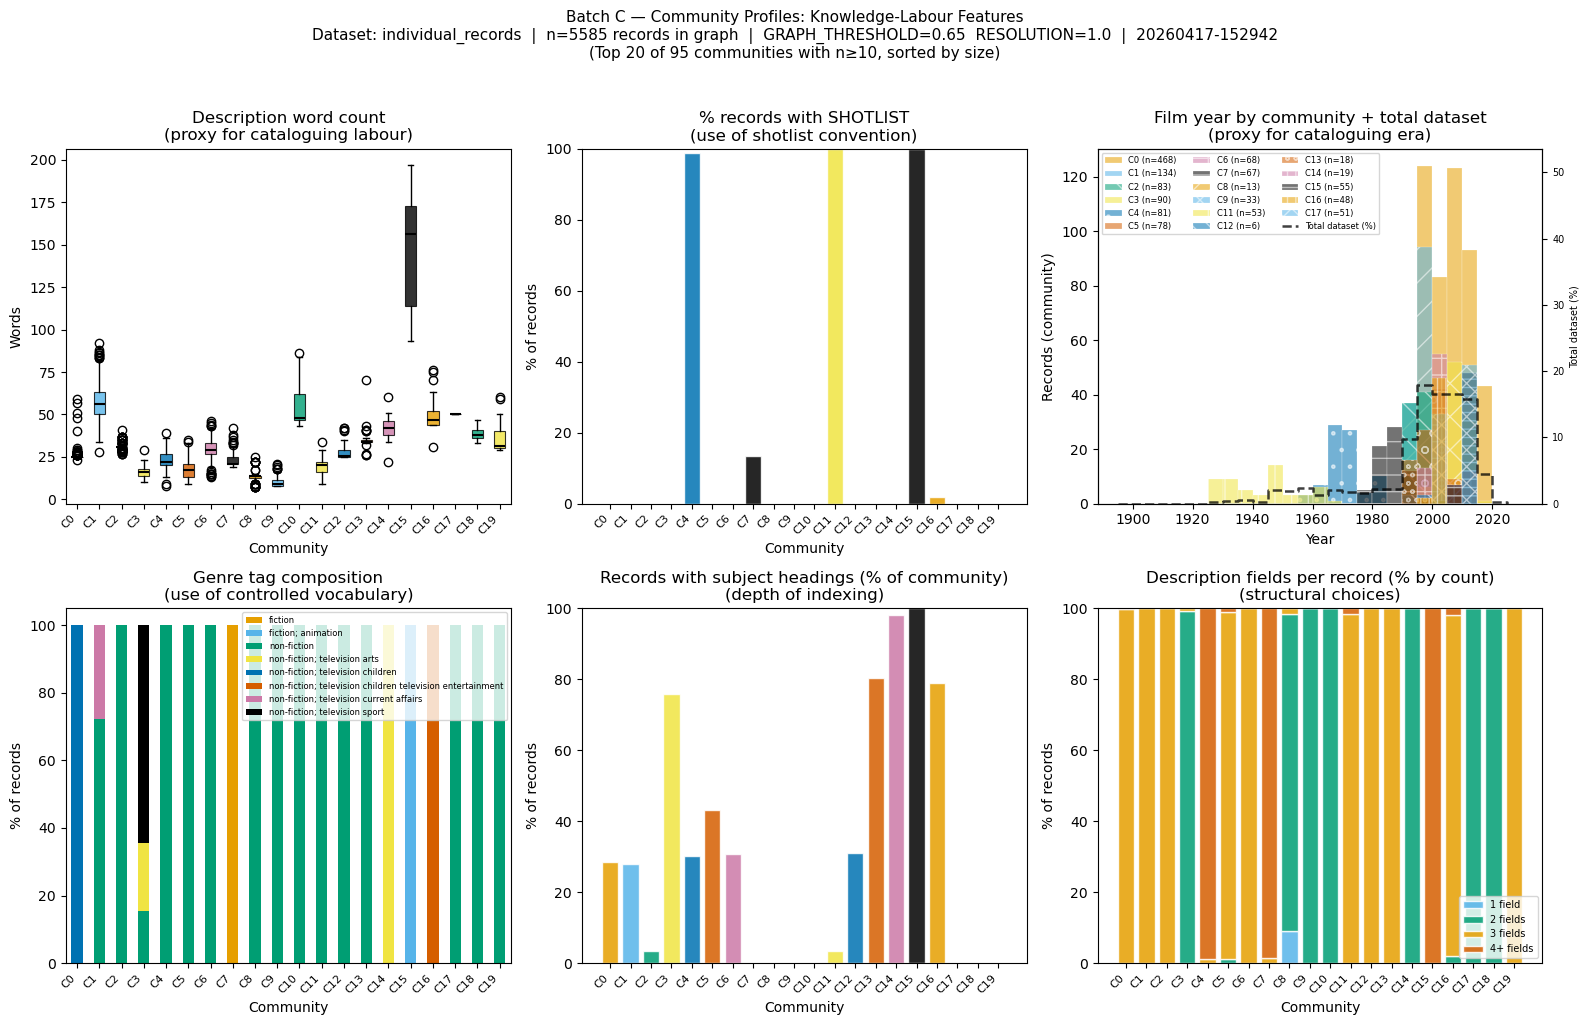

Saved to: /mnt/c/Users/jwb1n21/Dropbox/root/Southampton/Projects/ERC/code/visualisations/community-profiles_individual_records_20260417-152942.png


In [13]:
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
fig.suptitle(
    f'Batch C — Community Profiles: Knowledge-Labour Features\n'
    f'Dataset: {DATASET_NAME}  |  n={len(merged_df)} records in graph  |  '
    f'GRAPH_THRESHOLD={GRAPH_THRESHOLD}  RESOLUTION={RESOLUTION}  |  {RUN_DATETIME}\n'
    f'(Top {min(PROFILE_TOP_N, n_plot_comms)} of {n_plot_comms} communities with n≥{MIN_COMM_SIZE}, sorted by size)',
    fontsize=11, y=1.02
)

# Use top PROFILE_TOP_N communities by size (already sorted largest-first)
_c_ids = plot_comm_ids[:PROFILE_TOP_N]
_merged = merged_df[merged_df['community_id'].isin(_c_ids)]
bar_colors = [comm_colour(c) for c in _c_ids]
xlabels = [f'C{c}' for c in _c_ids]

# 1. Description word count by community
ax = axes[0, 0]
data_wc = [_merged[_merged['community_id'] == c]['desc_word_count'].values for c in _c_ids]
bp = ax.boxplot(data_wc, patch_artist=True, notch=False,
                boxprops=dict(linewidth=0.8), medianprops=dict(color='black', linewidth=1.5))
for patch, c in zip(bp['boxes'], _c_ids):
    patch.set_facecolor(comm_colour(c)); patch.set_alpha(0.8)
ax.set_xticklabels(xlabels, rotation=45, ha='right', fontsize=8)
ax.set_title('Description word count\n(proxy for cataloguing labour)')
ax.set_xlabel('Community'); ax.set_ylabel('Words')

# 2. SHOTLIST presence
ax = axes[0, 1]
pct_sl = _merged.groupby('community_id')['has_shotlist'].mean() * 100
ax.bar(xlabels, [pct_sl.get(c, 0) for c in _c_ids],
       color=bar_colors, alpha=0.85, edgecolor='white')
ax.set_title('% records with SHOTLIST\n(use of shotlist convention)')
ax.set_xlabel('Community'); ax.set_ylabel('% of records'); ax.set_ylim(0, 100)
ax.set_xticklabels(xlabels, rotation=45, ha='right', fontsize=8)

# 3. Film year distribution — community histograms + total dataset overlay
ax = axes[0, 2]
_yr_bins = list(range(1895, 2035, 5))
_hatches = ['', '/', '\\', 'x', '.', 'o', '+', '-', '//', 'XX',
            '*', '|', '\\\\', 'oo', '++', '--', '||', 'xx', '**', 'O']
for idx, c in enumerate(_c_ids):
    yrs = _merged[_merged['community_id'] == c]['year'].dropna()
    if len(yrs) > 1:
        _n, _b, _patches = ax.hist(
            yrs, bins=_yr_bins, alpha=0.55,
            label=f'C{c} (n={len(yrs)})',
            color=comm_colour(c), edgecolor='white', linewidth=0.3)
        _h = _hatches[idx % len(_hatches)]
        for _p in _patches:
            _p.set_hatch(_h)
# Total dataset overlay (all communities, not just top PROFILE_TOP_N) — secondary axis
ax2 = ax.twinx()
_all_yrs = merged_df['year'].dropna()
_tot_counts, _tot_bins = np.histogram(_all_yrs, bins=_yr_bins)
_tot_pct = _tot_counts / _tot_counts.sum() * 100
ax2.step(_tot_bins[:-1], _tot_pct, where='post',
         color='black', linewidth=1.8, linestyle='--', alpha=0.75,
         label='Total dataset (%)')
ax2.set_ylabel('Total dataset (%)', fontsize=7, color='black')
ax2.tick_params(axis='y', labelsize=7)
ax2.set_ylim(0, _tot_pct.max() * 3)   # keep overlay unobtrusive
# Combined legend
_h1, _l1 = ax.get_legend_handles_labels()
_h2, _l2 = ax2.get_legend_handles_labels()
ax.legend(_h1 + _h2, _l1 + _l2, fontsize=6, ncol=3)
ax.set_title('Film year by community + total dataset\n(proxy for cataloguing era)')
ax.set_xlabel('Year'); ax.set_ylabel('Records (community)')

# 4. Genre tag composition (stacked bar)
ax = axes[1, 0]
top_genres  = _merged['genre_tag'].value_counts().head(8).index
genre_pivot = (
    _merged[_merged['genre_tag'].isin(top_genres)]
    .groupby(['community_id', 'genre_tag']).size().unstack(fill_value=0)
)
genre_pct = genre_pivot.div(genre_pivot.sum(axis=1), axis=0) * 100
genre_pct.plot(kind='bar', stacked=True, ax=ax,
               color=[PALETTE[i % len(PALETTE)] for i in range(len(genre_pct.columns))],
               edgecolor='none')
ax.set_title('Genre tag composition\n(use of controlled vocabulary)')
ax.set_xlabel('Community'); ax.set_ylabel('% of records')
ax.set_xticklabels([f'C{c}' for c in genre_pct.index], rotation=45, ha='right', fontsize=8)
ax.legend(loc='upper right', fontsize=6)

# 5. Proportion of records with ≥1 subject heading
ax = axes[1, 1]
# n_subjects is effectively binary in this dataset (0 or 1 per record);
# averaging gives the proportion with any subject heading, not a mean count.
pct_subj = _merged.groupby('community_id')['n_subjects'].apply(
    lambda s: (s > 0).mean() * 100
)
ax.bar(xlabels, [pct_subj.get(c, 0) for c in _c_ids],
       color=bar_colors, alpha=0.85, edgecolor='white')
ax.set_title('Records with subject headings (% of community)\n(depth of indexing)')
ax.set_xlabel('Community'); ax.set_ylabel('% of records'); ax.set_ylim(0, 100)
ax.set_xticklabels(xlabels, rotation=45, ha='right', fontsize=8)

# 6. Description fields per record — stacked proportion bar
# n_desc_fields takes a small set of integer values (1, 2, 3, 4+);
# a stacked proportion bar is far more readable than a boxplot here.
ax = axes[1, 2]
field_bins = {1: '1 field', 2: '2 fields', 3: '3 fields'}
def _field_label(n):
    return field_bins.get(int(n), '4+ fields')
_merged['_field_bin'] = _merged['n_desc_fields'].apply(_field_label)
bin_order  = ['1 field', '2 fields', '3 fields', '4+ fields']
bin_colors = ['#56B4E9', '#009E73', '#E69F00', '#D55E00']
bottom = [0.0] * len(_c_ids)
for bin_label, bin_col in zip(bin_order, bin_colors):
    heights = []
    for c in _c_ids:
        grp = _merged[_merged['community_id'] == c]
        pct = (grp['_field_bin'] == bin_label).mean() * 100
        heights.append(pct)
    ax.bar(xlabels, heights, bottom=bottom, label=bin_label,
           color=bin_col, alpha=0.85, edgecolor='white')
    bottom = [b + h for b, h in zip(bottom, heights)]
ax.set_title('Description fields per record (% by count)\n(structural choices)')
ax.set_xlabel('Community'); ax.set_ylabel('% of records'); ax.set_ylim(0, 100)
ax.set_xticklabels(xlabels, rotation=45, ha='right', fontsize=8)
ax.legend(fontsize=7, loc='lower right')
_merged.drop(columns=['_field_bin'], inplace=True)

plt.tight_layout()
plot_path = os.path.join(VIS_DIR, f'community-profiles_{DATASET_NAME}_{RUN_DATETIME}.png')
plt.savefig(plot_path, dpi=150, bbox_inches='tight')
plt.show()
print(f"Saved to: {os.path.abspath(plot_path)}")


In [14]:
# Top genre tags per community — most direct test of the central argument
# If communities differ in genre tag usage, they reflect different cataloguing conventions
# Only shows communities with n >= MIN_COMM_SIZE
print(f"Top genre tags per community (n >= {MIN_COMM_SIZE}):\n")
for c in plot_comm_ids:
    comm_records = merged_df[merged_df['community_id'] == c]
    top_genres   = comm_records['genre_tag'].value_counts().head(5)
    print(f"Community {c} (n={len(comm_records)}):")
    for genre, count in top_genres.items():
        print(f"  {genre!r:45s} {count:4d}  ({count/len(comm_records)*100:.0f}%)")
    print()


Top genre tags per community (n >= 10):

Community 0 (n=584):
  'non-fiction; television children'             584  (100%)

Community 1 (n=560):
  'non-fiction'                                  403  (72%)
  'non-fiction; television current affairs'      156  (28%)
  'television current affairs'                     1  (0%)

Community 2 (n=295):
  'non-fiction'                                  284  (96%)
  'non-fiction; television news'                  11  (4%)

Community 3 (n=116):
  'non-fiction; television sport'                 67  (58%)
  'non-fiction; television arts'                  21  (18%)
  'non-fiction'                                   16  (14%)
  'non-fiction; television documentary'           12  (10%)

Community 4 (n=93):
  'non-fiction'                                   88  (95%)
  'non-fiction; television news'                   5  (5%)

Community 5 (n=93):
  'non-fiction'                                   52  (56%)
  'non-fiction; religion television religion'     20

### Inspecting `n_desc_fields` — what does this feature count?

`n_desc_fields` is the number of distinct `<dcterms:description>` XML elements in a record.
The boxplot in Batch C shows how this varies by community, but its meaning depends on the
cataloguing template used: does a higher count reflect a more detailed record, or simply
the use of a different structural template that splits description across more fields?

The cell below prints example records with 0, 1, 2, 3, and 4+ fields so you can inspect
what the variation actually represents before interpreting the community-level differences.


In [15]:
# ── Description fields inspector ─────────────────────────────────────────────
# Prints example records grouped by n_desc_fields count (0, 1, 2, 3, 4+).
# For each group, at most N_EXAMPLES = 3 records are shown with their actual
# description text from RECORDS_DIR.

N_EXAMPLES = 3

import os, re

# ── Distribution summary ──────────────────────────────────────────────────────
field_counts_raw = sorted(merged_df['n_desc_fields'].unique())
print(f"n_desc_fields values seen: {[int(v) for v in field_counts_raw]}")
print("Distribution:")
vc = merged_df['n_desc_fields'].value_counts().sort_index()
for k, v in vc.items():
    print(f"  {int(k):2d} field(s): {v:4d} records  ({v/len(merged_df)*100:.1f}%)")
print()

# ── Group as 0, 1, 2, 3, 4+ ──────────────────────────────────────────────────
groups = {}
for n in field_counts_raw:
    label = str(int(n)) if n <= 3 else '4+'
    if label not in groups:
        groups[label] = []
    groups[label].extend(
        merged_df[merged_df['n_desc_fields'] == n]['film_ref']
        .drop_duplicates().tolist()
    )

# ── Pre-build lookup: film_ref → description fields ───────────────────────────
# Scans RECORDS_DIR once.  Uses the same filmRef format as the communities file:
# '(filmRef)0064' — i.e. the full identifier including prefix.
_desc_lookup = {}
for fname in sorted(os.listdir(RECORDS_DIR)):
    fpath = os.path.join(RECORDS_DIR, fname)
    try:
        text = open(fpath, encoding='utf-8').read()
    except Exception:
        continue
    ref_match = re.search(r'\(filmRef\)([^<\s]+)', text)
    if not ref_match:
        continue
    film_ref = '(filmRef)' + ref_match.group(1)
    descs = re.findall(r'<dcterms:description>(.*?)</dcterms:description>', text, re.DOTALL)
    _desc_lookup[film_ref] = [d.strip() for d in descs]

print(f"Lookup built: {len(_desc_lookup)} records indexed from RECORDS_DIR")
print()

# ── Print examples per group ──────────────────────────────────────────────────
for label in ['0', '1', '2', '3', '4+']:
    if label not in groups:
        continue
    sample_refs = groups[label][:N_EXAMPLES]   # hard cap
    print(f"{'═'*72}")
    print(f"  Records with n_desc_fields = {label}  "
          f"(showing {len(sample_refs)} of {len(groups[label])})")
    print(f"{'═'*72}")
    for ref in sample_refs:
        comm = int(merged_df[merged_df['film_ref'] == ref]['community_id'].iloc[0])
        fields = _desc_lookup.get(ref, [])
        print(f"  Record: {ref}  (community {comm})")
        if not fields:
            print("    [no dcterms:description elements found]")
        for k, f in enumerate(fields, 1):
            preview = f[:200]
            ellipsis = '…' if len(f) > 200 else ''
            print(f"    Field {k}: {preview}{ellipsis}")
        print()


n_desc_fields values seen: [1, 2, 3, 4, 5]
Distribution:
   1 field(s):   18 records  (0.3%)
   2 field(s): 1662 records  (29.8%)
   3 field(s): 3219 records  (57.6%)
   4 field(s):  604 records  (10.8%)
   5 field(s):   82 records  (1.5%)

Lookup built: 23490 records indexed from RECORDS_DIR

════════════════════════════════════════════════════════════════════════
  Records with n_desc_fields = 1  (showing 3 of 18)
════════════════════════════════════════════════════════════════════════
  Record: (filmRef)15555  (community 359)
    Field 1: [no synopsis]

  Record: (filmRef)15558  (community 359)
    Field 1: [no synopsis]

  Record: (filmRef)16420  (community 226)
    Field 1: non-fiction

════════════════════════════════════════════════════════════════════════
  Records with n_desc_fields = 2  (showing 3 of 1662)
════════════════════════════════════════════════════════════════════════
  Record: (filmRef)10257  (community 242)
    Field 1: non-fiction; amateur
    Field 2: Amateur fo

---
## Batch D — Network visualisation

**Purpose**: Draw the similarity network with nodes coloured by community membership, providing
a spatial representation of the community structure. This is primarily an interpretive and
communication tool: it allows you to see at a glance whether communities are tightly clustered
or loosely connected, whether there are bridge nodes linking communities, and whether the
overall network has a hub-and-spoke or diffuse structure.

Each node is a catalogue record. Each edge connects two records with SM ratio ≥ `GRAPH_THRESHOLD`;
edge width is proportional to the SM ratio. Isolated records (no above-threshold matches) are
not shown. The layout algorithm positions nodes to minimise edge lengths, so spatially proximate
nodes are records with mutual high-similarity connections.

**Interpreting the visualisation**: Dense clusters where nodes are closely packed indicate
communities with many strong internal connections — records that are highly similar to many
others in the group. Loose, elongated communities suggest a chain-like structure where individual
records are connected to their neighbours but not to the community as a whole. Bridge nodes
sitting between communities are records with meaningful similarity to two or more groups and
may repay qualitative inspection.

Layout: Kamada-Kawai for graphs ≤ 1,500 nodes (deterministic, best quality);
spring layout for larger graphs (stochastic, faster). For very large graphs (> 10,000 nodes)
consider reducing `node_size` and edge `alpha` in the plotting cell, or subsetting to
community members only for readability.

**Requires**: `PAIRWISE_TSV` + `COMMUNITIES_TSV`  
**Produces**: `visualisations/network_{dataset}_{datetime}.png`

In [16]:
# ── Batch D setup: load pairwise results and community assignments ─────────────
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np
import warnings
import os
import time as _time
warnings.filterwarnings('ignore')

results_df  = pd.read_csv(PAIRWISE_TSV, sep='\t')
assignments = pd.read_csv(COMMUNITIES_TSV, sep='\t')

partition     = dict(zip(assignments['film_ref'], assignments['community_id']))
n_communities = assignments['community_id'].nunique()
comm_ids_uniq = sorted(assignments['community_id'].unique())
from collections import Counter
counts = Counter(partition.values())

# Top-N communities (for colouring/labelling in the plot)
top_n_comm_ids = set([c for c, _ in counts.most_common(TOP_N_COMM)])

# ── Build analysis graph (full GRAPH_THRESHOLD) ──────────────────────────────
# This graph is used for community-colour assignments only; layout uses G_vis.
print(f"Analysis graph  : filtering pairs at GRAPH_THRESHOLD={GRAPH_THRESHOLD}...")
_t0 = _time.time()
graph_df = results_df[
    (results_df['sm_ratio'] >= GRAPH_THRESHOLD) 
    
].copy()
G = nx.from_pandas_edgelist(graph_df, source='base_id', target='compare_id',
                             edge_attr='sm_ratio')
nx.set_edge_attributes(G, {(u,v): d['sm_ratio'] for u,v,d in G.edges(data=True)}, 'weight')
print(f"  {G.number_of_nodes():,} nodes, {G.number_of_edges():,} edges  ({_time.time()-_t0:.1f}s)")

# ── Build visualisation graph (VIS_THRESHOLD — sparser, more readable) ────────
print(f"Visualisation graph: filtering pairs at VIS_THRESHOLD={VIS_THRESHOLD}...")
_t0 = _time.time()
vis_df = results_df[
    (results_df['sm_ratio'] >= VIS_THRESHOLD) 
    
].copy()
G_vis = nx.from_pandas_edgelist(vis_df, source='base_id', target='compare_id',
                                 edge_attr='sm_ratio')
nx.set_edge_attributes(G_vis, {(u,v): d['sm_ratio'] for u,v,d in G_vis.edges(data=True)}, 'weight')
print(f"  {G_vis.number_of_nodes():,} nodes, {G_vis.number_of_edges():,} edges  ({_time.time()-_t0:.1f}s)")
print()
print(f"Communities: {n_communities} total  |  top {TOP_N_COMM} coloured/labelled in plot")


Analysis graph  : filtering pairs at GRAPH_THRESHOLD=0.65...
  5,585 nodes, 381,380 edges  (0.6s)
Visualisation graph: filtering pairs at VIS_THRESHOLD=0.8...
  4,277 nodes, 263,177 edges  (0.4s)

Communities: 587 total  |  top 15 coloured/labelled in plot


Computing graph layout (4277 nodes)...
  Layout done in 26.8s


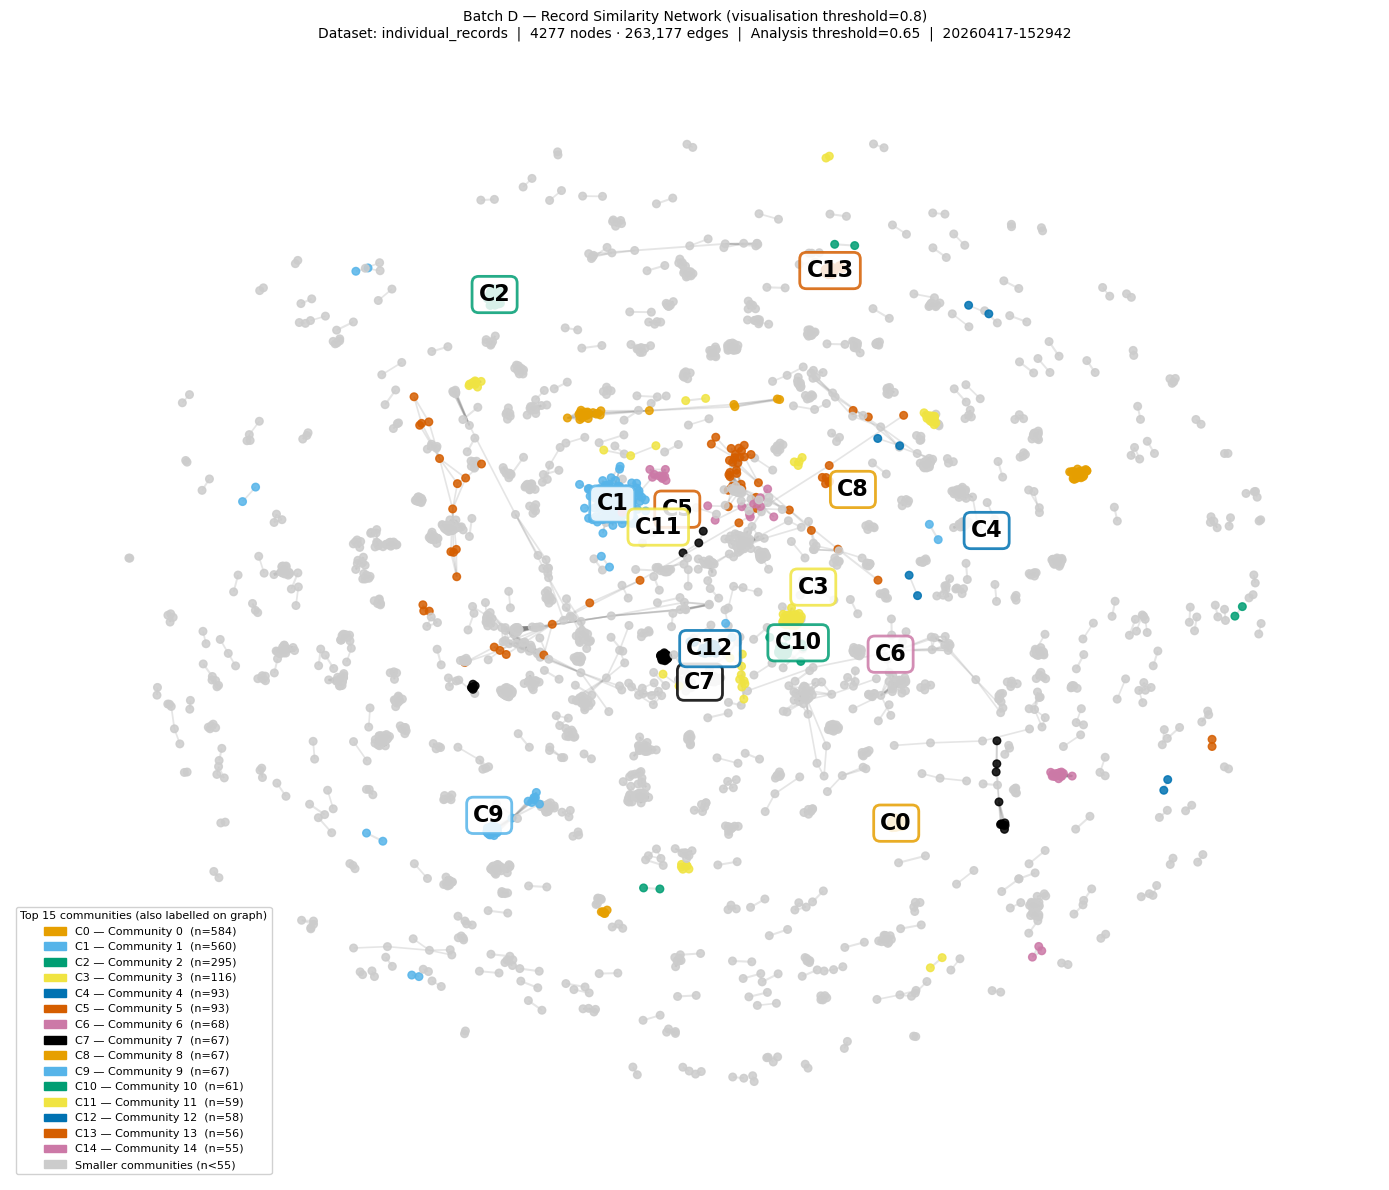

Saved to: /mnt/c/Users/jwb1n21/Dropbox/root/Southampton/Projects/ERC/code/visualisations/network_individual_records_20260417-152942.png

Note: network drawn using VIS_THRESHOLD=0.8 for readability.
Community detection used GRAPH_THRESHOLD=0.65 — colours are correct.
Nodes in grey belong to communities smaller than the top 15.


In [17]:
fig, ax = plt.subplots(figsize=(14, 12))

print(f"Computing graph layout ({G_vis.number_of_nodes()} nodes)...")
import time as _time
import numpy as np
_t0 = _time.time()
if G_vis.number_of_nodes() <= 1500:
    pos = nx.kamada_kawai_layout(G_vis, weight='weight')
else:
    pos = nx.spring_layout(G_vis, seed=42, k=0.3, iterations=50)
print(f"  Layout done in {_time.time()-_t0:.1f}s")

# Colour nodes: top-N communities get Okabe-Ito colours; others are grey
node_colors  = [comm_colour(partition.get(node, -1), top_n_ids=top_n_comm_ids)
                for node in G_vis.nodes()]
edge_weights = [G_vis[u][v]['weight'] for u, v in G_vis.edges()]

nx.draw_networkx_nodes(G_vis, pos, node_color=node_colors, node_size=30, alpha=0.85, ax=ax)
nx.draw_networkx_edges(G_vis, pos, width=[w * 1.5 for w in edge_weights],
                       alpha=0.20, edge_color='grey', ax=ax)

# ── Community centroid labels — top-N communities only ────────────────────────
for c in top_n_comm_ids:
    members = [n for n in G_vis.nodes() if partition.get(n) == c]
    if not members:
        continue
    xs = [pos[n][0] for n in members]
    ys = [pos[n][1] for n in members]
    cx, cy = float(np.mean(xs)), float(np.mean(ys))
    ax.text(
        cx, cy, f'C{c}',
        fontsize=16, fontweight='bold', ha='center', va='center', color='black',
        bbox=dict(boxstyle='round,pad=0.3', facecolor='white',
                  edgecolor=comm_colour(c), linewidth=2.0, alpha=0.85),
        zorder=5,
    )

# Legend: top-N communities only
legend_handles = [
    mpatches.Patch(color=comm_colour(c),
                   label=f'C{c} — Community {c}  (n={counts[c]})')
    for c in sorted(top_n_comm_ids, key=lambda x: -counts[x])
]
legend_handles.append(mpatches.Patch(color='#cccccc', label=f'Smaller communities (n<{counts[sorted(top_n_comm_ids, key=lambda x: -counts[x])[-1]]})'))
ax.legend(handles=legend_handles, loc='lower left', fontsize=8, framealpha=0.9,
          title=f'Top {TOP_N_COMM} communities (also labelled on graph)', title_fontsize=8)
ax.set_title(
    f'Batch D — Record Similarity Network (visualisation threshold={VIS_THRESHOLD})\n'
    f'Dataset: {DATASET_NAME}  |  {G_vis.number_of_nodes()} nodes · {G_vis.number_of_edges():,} edges  |  '
    f'Analysis threshold={GRAPH_THRESHOLD}  |  {RUN_DATETIME}',
    fontsize=10
)
ax.axis('off')

plt.tight_layout()
plt.savefig(NETWORK_PNG, dpi=150, bbox_inches='tight')
plt.show()
print(f"Saved to: {os.path.abspath(NETWORK_PNG)}")
print()
print(f"Note: network drawn using VIS_THRESHOLD={VIS_THRESHOLD} for readability.")
print(f"Community detection used GRAPH_THRESHOLD={GRAPH_THRESHOLD} — colours are correct.")
print(f"Nodes in grey belong to communities smaller than the top {TOP_N_COMM}.")


Meta-graph using META_THRESHOLD = 0.5 (GRAPH_THRESHOLD = 0.65)
Meta-graph: 20 community nodes, 18 inter-community edges
  8 communities have no cross-community edges at GRAPH_THRESHOLD=0.65
  Most-connected community pairs:
    C0 <-> C3 : 19295 cross-community connections
    C3 <-> C8 : 1684 cross-community connections
    C0 <-> C16 : 579 cross-community connections
    C6 <-> C9 : 52 cross-community connections
    C3 <-> C9 : 49 cross-community connections


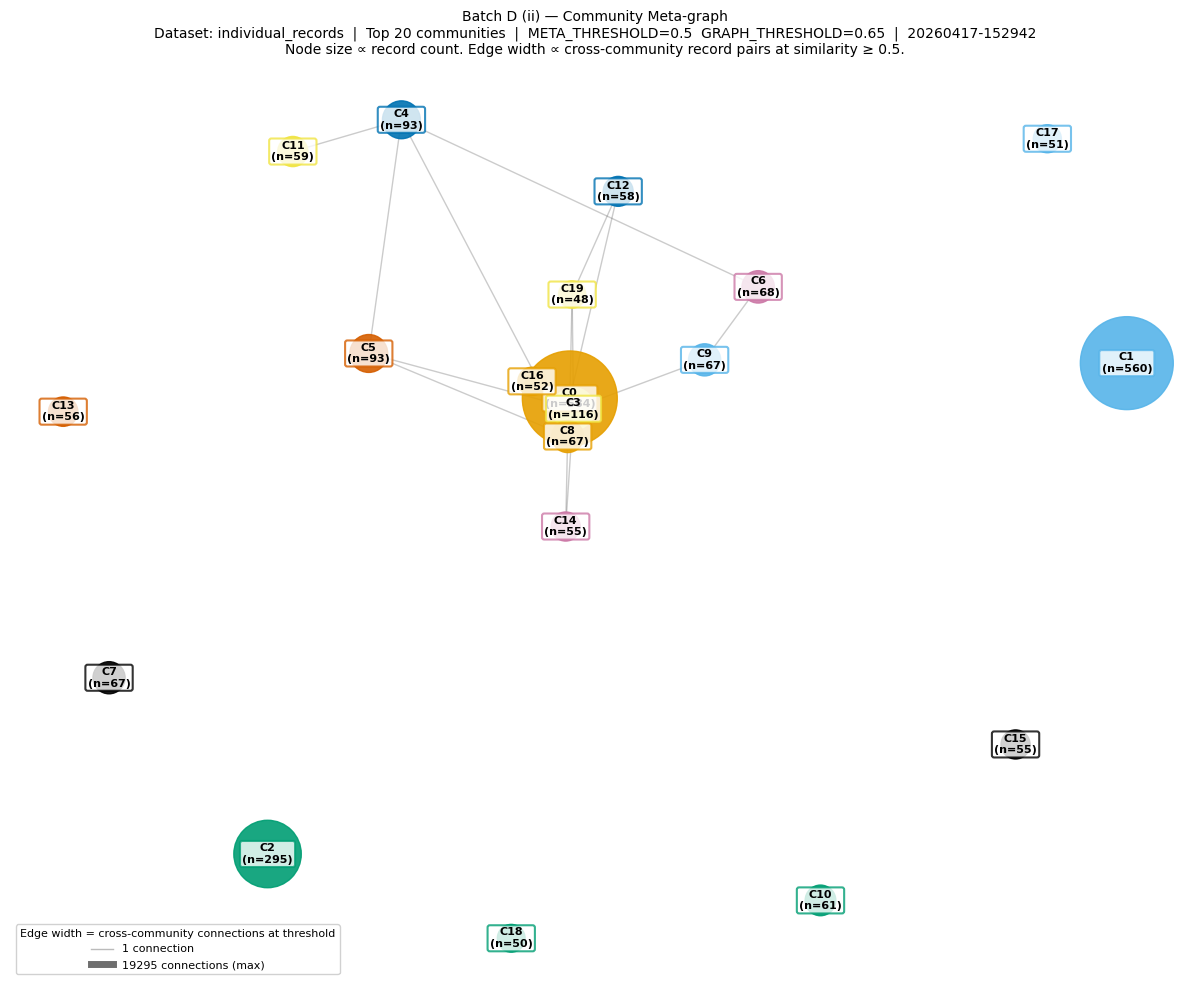

Saved to: /mnt/c/Users/jwb1n21/Dropbox/root/Southampton/Projects/ERC/code/visualisations/meta-graph_individual_records_20260417-152942.png


In [18]:
# ── Batch D (ii) — Community meta-graph ──────────────────────────────────────
# Draws the community-level structure: each node is a community (sized by record
# count), edges connect communities that have ANY pairwise similarity >= META_THRESHOLD,
# and edge width is proportional to the number of such cross-community record pairs.
#
# META_THRESHOLD defaults to BRIDGE_SUBTHRESH_LOW (typically 0.50) — well below
# GRAPH_THRESHOLD. This is intentional: in a high-modularity network (Q=0.65),
# the community algorithm has minimised edges at GRAPH_THRESHOLD, so querying G.edges()
# produces an empty meta-graph. Sub-threshold connections reveal the community
# neighbourhood structure that the analysis graph suppresses.

import networkx as nx
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np

# Resolve META_THRESHOLD at runtime
_meta_thresh = META_THRESHOLD if META_THRESHOLD is not None else BRIDGE_SUBTHRESH_LOW
print(f"Meta-graph using META_THRESHOLD = {_meta_thresh} (GRAPH_THRESHOLD = {GRAPH_THRESHOLD})")

top_meta_ids = set(c for c, _ in counts.most_common(META_TOP_N_COMM))

# Build community lookup: film_ref → community_id
_comm_lookup = dict(zip(
    pd.read_csv(COMMUNITIES_TSV, sep='\t')['film_ref'],
    pd.read_csv(COMMUNITIES_TSV, sep='\t')['community_id']
))

# Scan pairwise TSV for cross-community pairs at [_meta_thresh, 1.0)
meta_edge_counts = {}
_chunk_size = 50_000
for _chunk in pd.read_csv(PAIRWISE_TSV, sep='\t',
                           chunksize=_chunk_size,
                           usecols=['base_id', 'compare_id', 'sm_ratio']):
    _chunk = _chunk[_chunk['sm_ratio'] >= _meta_thresh]
    for _, row in _chunk.iterrows():
        cu = _comm_lookup.get(row['base_id'])
        cv = _comm_lookup.get(row['compare_id'])
        if cu is None or cv is None or cu == cv:
            continue
        if cu not in top_meta_ids or cv not in top_meta_ids:
            continue
        key = tuple(sorted([cu, cv]))
        meta_edge_counts[key] = meta_edge_counts.get(key, 0) + 1

G_meta = nx.Graph()
for c in top_meta_ids:
    G_meta.add_node(c, n_records=counts[c])
for (cu, cv), w in meta_edge_counts.items():
    G_meta.add_edge(cu, cv, weight=w)

n_meta_edges = G_meta.number_of_edges()
isolated = [c for c in top_meta_ids if G_meta.degree(c) == 0]
print(f"Meta-graph: {G_meta.number_of_nodes()} community nodes, {n_meta_edges} inter-community edges")
print(f"  {len(isolated)} communities have no cross-community edges at GRAPH_THRESHOLD={GRAPH_THRESHOLD}")
if meta_edge_counts:
    top_pairs = sorted(meta_edge_counts.items(), key=lambda x: -x[1])[:5]
    print("  Most-connected community pairs:")
    for (cu, cv), w in top_pairs:
        print(f"    C{cu} <-> C{cv} : {w} cross-community connections")

fig, ax = plt.subplots(figsize=(12, 10))
if n_meta_edges > 0:
    pos = nx.spring_layout(G_meta, seed=42, k=2.5, weight='weight', iterations=100)
else:
    pos = nx.circular_layout(G_meta)

node_sizes  = [G_meta.nodes[c]['n_records'] * 8 for c in G_meta.nodes()]
node_colors = [comm_colour(c) for c in G_meta.nodes()]

if n_meta_edges > 0:
    raw_weights = [G_meta[u][v]['weight'] for u, v in G_meta.edges()]
    max_w = max(raw_weights)
    for (u, v), w in zip(G_meta.edges(), raw_weights):
        lw    = 1.0 + (w / max_w) * 8
        alpha = 0.3 + (w / max_w) * 0.55
        nx.draw_networkx_edges(G_meta, pos, edgelist=[(u, v)],
                               width=lw, alpha=alpha, edge_color='#555555', ax=ax)

nx.draw_networkx_nodes(G_meta, pos, node_color=node_colors,
                       node_size=node_sizes, alpha=0.90, ax=ax)

for c in G_meta.nodes():
    x, y = pos[c]
    ax.text(x, y, f'C{c}\n(n={counts[c]})',
            fontsize=8, fontweight='bold', ha='center', va='center',
            bbox=dict(boxstyle='round,pad=0.2', facecolor='white',
                      edgecolor=comm_colour(c), linewidth=1.5, alpha=0.80), zorder=5)

if n_meta_edges > 0:
    ax.plot([], [], color='#555555', linewidth=1, alpha=0.4, label='1 connection')
    ax.plot([], [], color='#555555', linewidth=5, alpha=0.85,
            label=f'{max_w} connections (max)')
    ax.legend(fontsize=8, loc='lower left', framealpha=0.9,
              title='Edge width = cross-community connections at threshold', title_fontsize=8)

ax.set_title(
    f'Batch D (ii) — Community Meta-graph\n'
    f'Dataset: {DATASET_NAME}  |  Top {META_TOP_N_COMM} communities  |  '
    f'META_THRESHOLD={_meta_thresh}  GRAPH_THRESHOLD={GRAPH_THRESHOLD}  |  {RUN_DATETIME}\n'
    f'Node size ∝ record count. Edge width ∝ cross-community record pairs at similarity ≥ {_meta_thresh}.',
    fontsize=10
)
ax.axis('off')
plt.tight_layout()
meta_path = os.path.join(VIS_DIR, f'meta-graph_{DATASET_NAME}_{RUN_DATETIME}.png')
plt.savefig(meta_path, dpi=150, bbox_inches='tight')
plt.show()
print(f"Saved to: {os.path.abspath(meta_path)}")


---
## Batch E — Network centrality: hubs and bridge nodes

**Purpose**: Compute standard network centrality metrics to identify which records occupy
structurally significant positions in the similarity network, and to assess the internal
cohesion of each community.

**Why this matters**: Community detection tells you *which* records cluster together; centrality
analysis tells you *how* they are structured internally. Two communities of the same size can
have very different structures — one might be a dense core where every record is similar to
every other; another might be a chain where records are connected only to their immediate
neighbours. These structural differences carry interpretive weight for the knowledge-labour
argument: a dense community suggests a strong, coherent practice shared across many records;
a chain-like community may reflect gradual drift or a looser family resemblance.

Three metrics are computed:

- **Degree centrality**: The proportion of all other graph nodes to which a given node is
  connected. High degree nodes are records that are similar to many others — potential "model"
  records that other cataloguers may have imitated, or records produced by a particularly
  prolific cataloguer whose style diffuses across the collection.

- **Betweenness centrality**: The proportion of shortest paths between all pairs of nodes that
  pass through a given node. High betweenness nodes are structural bridges. In the context of
  community structure, the most interesting high-betweenness nodes are those sitting *between*
  communities — records similar enough to two distinct communities to connect them. These are
  the most analytically interesting candidates for qualitative inspection: they may represent
  transitional records, cataloguers trained in multiple traditions, or periods of stylistic
  change.

- **Eigenvector centrality**: A node's centrality weighted by the centrality of its neighbours.
  High eigenvector centrality nodes are influential not just because they are well-connected,
  but because they are connected to other well-connected records. This metric is sensitive to
  the core of the most densely connected part of the network.

**Interpreting the output**: Look for:
1. Whether the highest-degree nodes fall within a single community (concentrated hub) or are
   distributed across communities (distributed influence).
2. Whether bridge nodes (high betweenness, cross-community) form a recognisable group — do
   they share features? Are they older or newer records? Do they have distinctive genre tags?
3. Whether any community has low internal density, suggesting it is held together by a few
   chain-like connections rather than general mutual similarity.

**Requires**: `PAIRWISE_TSV` + `COMMUNITIES_TSV`  
**Produces**: `derived-data/centrality_{dataset}_{datetime}.tsv`;
`visualisations/centrality_{dataset}_{datetime}.png`

In [19]:
# ── Batch E setup: load graph and community assignments ────────────────────────
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np
import time as _time
import os

results_df  = pd.read_csv(PAIRWISE_TSV, sep='\t')
assignments = pd.read_csv(COMMUNITIES_TSV, sep='\t')

# Rebuild analysis graph
print(f"Building graph at GRAPH_THRESHOLD={GRAPH_THRESHOLD}...")
_t0 = _time.time()
graph_df = results_df[
    (results_df['sm_ratio'] >= GRAPH_THRESHOLD)
].copy()
G_b = nx.from_pandas_edgelist(graph_df, source='base_id', target='compare_id',
                               edge_attr='sm_ratio')
nx.set_edge_attributes(G_b, {(u,v): d['sm_ratio'] for u,v,d in G_b.edges(data=True)}, 'weight')
print(f"  {G_b.number_of_nodes():,} nodes, {G_b.number_of_edges():,} edges  ({_time.time()-_t0:.1f}s)")

partition_b   = dict(zip(assignments['film_ref'], assignments['community_id']))
comm_ids_uniq = sorted(assignments['community_id'].unique())
n_communities = len(comm_ids_uniq)
from collections import Counter
_counts_e = Counter(partition_b.values())

print(f"Communities: {n_communities} total")

# ── Centrality metrics ────────────────────────────────────────────────────────
print("\nComputing centrality metrics...")
print("  degree centrality...")
_t0 = _time.time()
degree_cent    = nx.degree_centrality(G_b)
print(f"    done ({_time.time()-_t0:.1f}s)")

print("  betweenness centrality (slow step — please wait)...")
_t0 = _time.time()
between_cent   = nx.betweenness_centrality(G_b, weight='weight', normalized=True)
print(f"    done ({_time.time()-_t0:.1f}s)")

print("  eigenvector centrality...")
_t0 = _time.time()
try:
    eigen_cent = nx.eigenvector_centrality(G_b, weight='weight', max_iter=1000)
except nx.PowerIterationFailedConvergence:
    eigen_cent = {n: 0.0 for n in G_b.nodes()}
    print("  ⚠ Eigenvector centrality did not converge — set to 0.0 for all nodes.")
print(f"    done ({_time.time()-_t0:.1f}s)")

# ── Per-community internal density ────────────────────────────────────────────
print("\n  computing community internal densities...")
def community_density(G, partition, comm_id):
    nodes = [n for n, c in partition.items() if c == comm_id]
    if len(nodes) < 2:
        return 0.0
    subgraph = G.subgraph(nodes)
    return nx.density(subgraph)

densities = {c: community_density(G_b, partition_b, c) for c in comm_ids_uniq}
print("  All centrality metrics complete.")

# ── Build centrality dataframe ────────────────────────────────────────────────
centrality_df = pd.DataFrame({
    'film_ref'          : list(G_b.nodes()),
    'community_id'      : [partition_b.get(n) for n in G_b.nodes()],
    'degree_centrality' : [degree_cent[n]  for n in G_b.nodes()],
    'betweenness'       : [between_cent[n] for n in G_b.nodes()],
    'eigenvector'       : [eigen_cent[n]   for n in G_b.nodes()],
}).sort_values('betweenness', ascending=False)

# Flag bridge nodes: high betweenness AND neighbour communities ≠ own community
def neighbour_communities(node, G, partition):
    return set(partition.get(nbr) for nbr in G.neighbors(node) if nbr in partition)

centrality_df['n_neighbour_communities'] = centrality_df['film_ref'].apply(
    lambda n: len(neighbour_communities(n, G_b, partition_b))
)
# Option B: betweenness-only bridge definition
# The previous definition required n_neighbour_communities > 1 (a direct above-threshold
# edge to a node in a different community). In a high-modularity graph (Q=0.65) the
# community algorithm specifically minimises such edges, so the condition was circular
# and almost always false. Betweenness alone is the correct signal: the top 1% by
# betweenness are the gateway nodes through which inter-community paths run.
# n_neighbour_communities is retained for reference (used in the sub-threshold scan).
centrality_df['is_bridge'] = (
    centrality_df['betweenness'] > centrality_df['betweenness'].quantile(BRIDGE_BETWEENNESS_PCT)
)

# Save
centrality_path = os.path.join(DERIVED_DATA_DIR,
                               f'centrality_{DATASET_NAME}_{RUN_DATETIME}.tsv')
centrality_df.to_csv(centrality_path, sep='\t', index=False)
print(f"\nCentrality metrics saved to: {os.path.abspath(centrality_path)}")

# ── Summary tables (filtered to MIN_COMM_SIZE) ────────────────────────────────
print(f"\n─── Community internal density (communities with n≥{MIN_COMM_SIZE}) ──────────────")
print("(Higher = more records are directly similar to each other within the community)")
for c in comm_ids_uniq:
    n = _counts_e[c]
    if n < MIN_COMM_SIZE:
        continue
    d = densities[c]
    bar = '█' * int(d * 30)
    print(f"  C{c} (n={n:3d})  density={d:.3f}  {bar}")

print("\n─── Top 10 hub nodes (highest degree centrality) ────────────────────")
print(centrality_df[['film_ref','community_id','degree_centrality','betweenness','eigenvector']]
      .sort_values('degree_centrality', ascending=False).head(10).to_string(index=False))

print("\n─── Top 10 bridge nodes (high betweenness, cross-community) ─────────")
bridges = centrality_df[centrality_df['is_bridge']].head(BRIDGE_TOP_N)
if len(bridges):
    print(bridges[['film_ref','community_id','betweenness',
                   'n_neighbour_communities']].to_string(index=False))
else:
    print("  No bridge nodes identified at current threshold.")


Building graph at GRAPH_THRESHOLD=0.65...
  5,585 nodes, 381,380 edges  (0.5s)
Communities: 587 total

Computing centrality metrics...
  degree centrality...
    done (0.0s)
  betweenness centrality (slow step — please wait)...
    done (120.0s)
  eigenvector centrality...
    done (3.9s)

  computing community internal densities...
  All centrality metrics complete.

Centrality metrics saved to: /mnt/c/Users/jwb1n21/Dropbox/root/Southampton/Projects/ERC/code/derived-data/centrality_individual_records_20260417-152942.tsv

─── Community internal density (communities with n≥10) ──────────────
(Higher = more records are directly similar to each other within the community)
  C0 (n=584)  density=0.993  █████████████████████████████
  C1 (n=560)  density=0.882  ██████████████████████████
  C2 (n=295)  density=0.944  ████████████████████████████
  C3 (n=116)  density=0.406  ████████████
  C4 (n= 93)  density=0.056  █
  C5 (n= 93)  density=0.201  ██████
  C6 (n= 68)  density=0.255  ███████
  C

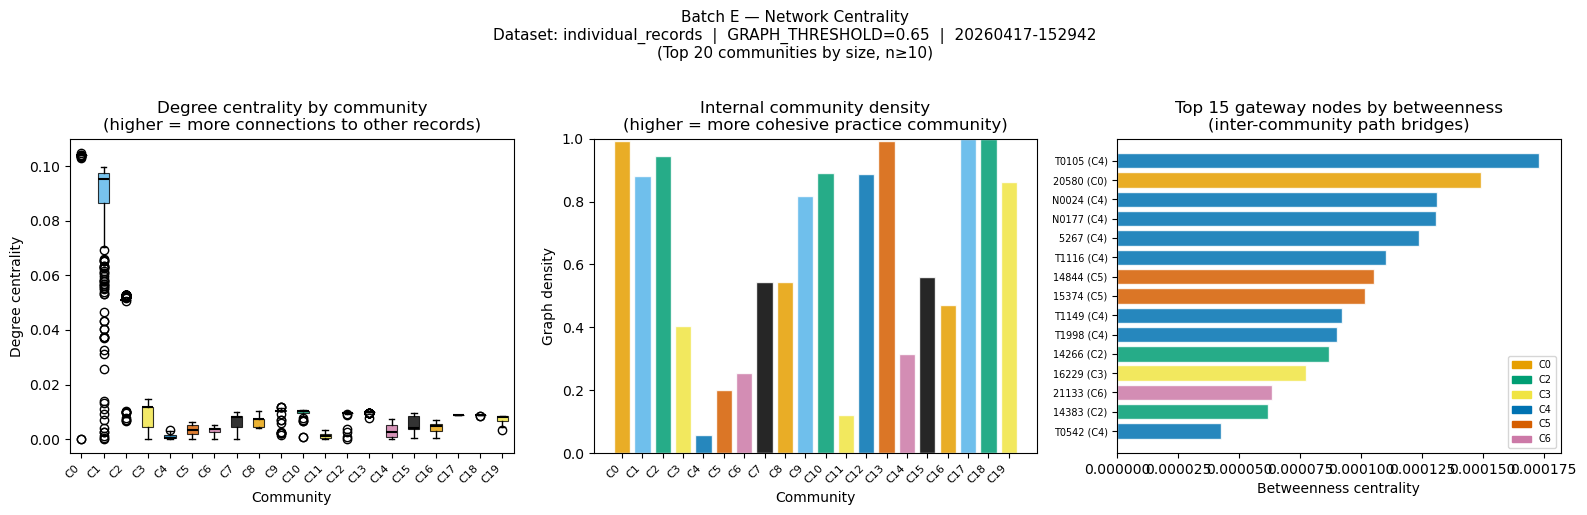

Saved to: /mnt/c/Users/jwb1n21/Dropbox/root/Southampton/Projects/ERC/code/visualisations/centrality_individual_records_20260417-152942.png

Next: open the centrality TSV and inspect bridge node record IDs qualitatively.
Bridge nodes are the most analytically interesting candidates for close reading.


In [20]:
# ── Batch E figure: centrality distributions and community density ─────────────
from collections import Counter as _Counter

# Select communities to show: top BOXPLOT_TOP_N by size, subject to MIN_COMM_SIZE
_counts_e2 = _Counter(partition_b.values())
plot_comm_e = [
    c for c, _ in _counts_e2.most_common(BOXPLOT_TOP_N)
    if _counts_e2[c] >= MIN_COMM_SIZE
]

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle(
    f'Batch E — Network Centrality\n'
    f'Dataset: {DATASET_NAME}  |  GRAPH_THRESHOLD={GRAPH_THRESHOLD}  |  {RUN_DATETIME}\n'
    f'(Top {len(plot_comm_e)} communities by size, n≥{MIN_COMM_SIZE})',
    fontsize=11, y=1.02
)

bar_colors = [comm_colour(c) for c in plot_comm_e]
xlabels_e  = [f'C{c}' for c in plot_comm_e]

# Panel 1: degree centrality distribution per community
ax = axes[0]
data_deg = [centrality_df[centrality_df['community_id'] == c]['degree_centrality'].values
            for c in plot_comm_e]
bp = ax.boxplot(data_deg, patch_artist=True,
                boxprops=dict(linewidth=0.8),
                medianprops=dict(color='black', linewidth=1.5))
for patch, c in zip(bp['boxes'], plot_comm_e):
    patch.set_facecolor(comm_colour(c)); patch.set_alpha(0.8)
ax.set_xticklabels(xlabels_e, rotation=45, ha='right', fontsize=8)
ax.set_title('Degree centrality by community\n(higher = more connections to other records)')
ax.set_xlabel('Community'); ax.set_ylabel('Degree centrality')

# Panel 2: internal community density
ax = axes[1]
ax.bar(xlabels_e, [densities[c] for c in plot_comm_e],
       color=bar_colors, alpha=0.85, edgecolor='white')
ax.set_title('Internal community density\n(higher = more cohesive practice community)')
ax.set_xlabel('Community'); ax.set_ylabel('Graph density')
ax.set_ylim(0, 1)
ax.set_xticklabels(xlabels_e, rotation=45, ha='right', fontsize=8)

# Panel 3: top bridge nodes by betweenness — ranked horizontal bar chart
# Replaces the degree-vs-betweenness scatter (unreadable at this scale).
# Shows top BRIDGE_TOP_N records by betweenness, coloured by community.
# These are the gateway records through which inter-community paths run.
ax = axes[2]
import math
top_bridges = centrality_df.nlargest(BRIDGE_TOP_N, 'betweenness')
bridge_bar_colors = [
    comm_colour(int(c)) if (c is not None and not (isinstance(c, float) and math.isnan(c)))
    else '#cccccc'
    for c in top_bridges['community_id']
]
ax.barh(range(len(top_bridges)), top_bridges['betweenness'],
        color=bridge_bar_colors, alpha=0.85, edgecolor='white')
ax.set_yticks(range(len(top_bridges)))
ax.set_yticklabels(
    [f"{str(row['film_ref']).replace('(filmRef)','').replace('.txt','').strip()} "
     f"(C{int(row['community_id'])})"
     for _, row in top_bridges.iterrows()],
    fontsize=7
)
ax.invert_yaxis()
ax.set_title(f'Top {BRIDGE_TOP_N} gateway nodes by betweenness\n(inter-community path bridges)')
ax.set_xlabel('Betweenness centrality')
_shown_comms_b = sorted(top_bridges['community_id'].dropna().unique())
legend_handles = [mpatches.Patch(color=comm_colour(int(c)), label=f'C{int(c)}')
                  for c in _shown_comms_b]
ax.legend(handles=legend_handles, fontsize=7, loc='lower right')

plt.tight_layout()
plot_path = os.path.join(VIS_DIR, f'centrality_{DATASET_NAME}_{RUN_DATETIME}.png')
plt.savefig(plot_path, dpi=150, bbox_inches='tight')
plt.show()
print(f"Saved to: {os.path.abspath(plot_path)}")
print()
print("Next: open the centrality TSV and inspect bridge node record IDs qualitatively.")
print("Bridge nodes are the most analytically interesting candidates for close reading.")


In [21]:
# ── Option A: Sub-threshold weak-bridge scan ──────────────────────────────────
# Scans the pairwise TSV for cross-community similarities in the window
# [BRIDGE_SUBTHRESH_LOW, GRAPH_THRESHOLD). These pairs are below the analysis
# threshold (no edge in the community graph) but above the noise floor.
#
# A record with sub-threshold connections to records in OTHER communities is a
# "weak bridge": it belongs clearly to one community but shares partial structural
# similarity with another cataloguing tradition. These are analytically important:
# they may represent transitional records, cataloguers trained in multiple styles,
# or records from periods of stylistic change.

import pandas as pd
from collections import defaultdict, Counter as _Counter2

print(f"Sub-threshold weak-bridge scan  [{BRIDGE_SUBTHRESH_LOW}, {GRAPH_THRESHOLD:.4f})")
print("Loading pairwise data...")
_sub_all = pd.read_csv(PAIRWISE_TSV, sep='\t')
_sub = _sub_all[
    (_sub_all['sm_ratio'] >= BRIDGE_SUBTHRESH_LOW) &
    (_sub_all['sm_ratio'] <  GRAPH_THRESHOLD)
].copy()
print(f"  {len(_sub):,} pairs in sub-threshold window  ({len(_sub_all):,} total pairwise pairs)")

_sub['comm_base']    = _sub['base_id'].map(partition_b)
_sub['comm_compare'] = _sub['compare_id'].map(partition_b)
_cross = _sub.dropna(subset=['comm_base', 'comm_compare'])
_cross = _cross[_cross['comm_base'] != _cross['comm_compare']]
print(f"  {len(_cross):,} cross-community sub-threshold pairs")
print()

# Per-record aggregation
_agg = defaultdict(lambda: {'n': 0, 'other': set(), 'own': None, 'sims': [], 'max': 0.0})
for _, row in _cross.iterrows():
    for node, own, other in [
        (row['base_id'],    row['comm_base'],    row['comm_compare']),
        (row['compare_id'], row['comm_compare'], row['comm_base'])
    ]:
        _agg[node]['n']    += 1
        _agg[node]['other'].add(int(other))
        _agg[node]['own']   = int(own)
        _agg[node]['sims'].append(row['sm_ratio'])
        _agg[node]['max']   = max(_agg[node]['max'], row['sm_ratio'])

_rows = [{
    'film_ref'            : ref,
    'own_community'       : s['own'],
    'n_cross_pairs'       : s['n'],
    'n_other_communities' : len(s['other']),
    'max_similarity'      : round(s['max'], 4),
    'mean_similarity'     : round(sum(s['sims']) / len(s['sims']), 4),
    'other_communities'   : ','.join(str(c) for c in sorted(s['other']))
} for ref, s in _agg.items() if s['own'] is not None]

scan_df = pd.DataFrame(_rows).sort_values('n_cross_pairs', ascending=False)

# Community-pair summary
comm_pair_counts = {}
for _, row in _cross.iterrows():
    key = tuple(sorted([int(row['comm_base']), int(row['comm_compare'])]))
    comm_pair_counts[key] = comm_pair_counts.get(key, 0) + 1

print("Top 10 community pairs by sub-threshold connection count:")
for (ca, cb), n in sorted(comm_pair_counts.items(), key=lambda x: -x[1])[:10]:
    print(f"  C{ca} <-> C{cb} : {n:4d} sub-threshold pairs")
print()

# Display top bridge candidates from top communities
_top_comm_set = set(c for c, _ in _Counter2(partition_b.values()).most_common(BOXPLOT_TOP_N))
scan_display  = scan_df[scan_df['own_community'].isin(_top_comm_set)]
print(f"Top {BRIDGE_TOP_N} weak-bridge candidates (from top {BOXPLOT_TOP_N} communities by size):")
print(scan_display.head(BRIDGE_TOP_N).to_string(index=False))
print()
print("  n_cross_pairs       : sub-threshold connections to other communities")
print("  n_other_communities : distinct other communities touched")
print("  max_similarity      : strongest sub-threshold connection to another community")
print("  other_communities   : which community IDs it touches")
print()
print("High n_other_communities = straddles multiple cataloguing traditions.")
print("High max_similarity      = one strong near-threshold connection to another community.")

_scan_path = os.path.join(DERIVED_DATA_DIR,
    f'bridge-scan-subthreshold_{DATASET_NAME}_{RUN_DATETIME}.tsv')
scan_df.to_csv(_scan_path, sep='\t', index=False)
print(f"\nFull scan saved to: {os.path.abspath(_scan_path)}")


Sub-threshold weak-bridge scan  [0.5, 0.6500)
Loading pairwise data...
  161,988 pairs in sub-threshold window  (2,474,236 total pairwise pairs)
  103,461 cross-community sub-threshold pairs

Top 10 community pairs by sub-threshold connection count:
  C0 <-> C3 : 19295 sub-threshold pairs
  C0 <-> C30 : 16211 sub-threshold pairs
  C0 <-> C33 : 15625 sub-threshold pairs
  C0 <-> C26 : 11112 sub-threshold pairs
  C0 <-> C180 : 2908 sub-threshold pairs
  C0 <-> C122 : 2706 sub-threshold pairs
  C0 <-> C236 : 1734 sub-threshold pairs
  C3 <-> C8 : 1684 sub-threshold pairs
  C0 <-> C483 : 1159 sub-threshold pairs
  C0 <-> C347 : 1156 sub-threshold pairs

Top 15 weak-bridge candidates (from top 20 communities by size):
      film_ref  own_community  n_cross_pairs  n_other_communities  max_similarity  mean_similarity                                                      other_communities
(filmRef)16178              3            696                   20          0.6054           0.5456       0,

In [22]:
# ── Batch E (ii) — Gateway node export: top BRIDGE_TOP_N records as plain text ─
# Fetches the description text for the top BRIDGE_TOP_N bridge nodes (ranked by
# betweenness), strips XML tags, and writes a single timestamped plain-text file
# to derived-data/ for close reading and printing.

import re, os

def _record_to_plaintext(film_ref, records_dir):
    """Load one record file, extract fields, return formatted plain text."""
    fname = film_ref.replace('(filmRef)', '') + '.txt'
    fpath = os.path.join(records_dir, fname)
    if not os.path.exists(fpath):
        return f"[File not found: {fname}]"
    raw = open(fpath, encoding='utf-8').read()
    def _tags(tag):
        return re.findall(rf'<dcterms:{tag}>([^<]+)</dcterms:{tag}>', raw)
    film_id  = next((v for v in _tags('identifier') if 'filmRef' in v), film_ref)
    url      = next((v for v in _tags('identifier') if 'http' in v), '')
    title    = ', '.join(_tags('title'))
    date     = ', '.join(_tags('date'))
    extent   = ', '.join(_tags('extent'))
    descs    = _tags('description')
    lines = [f"Record: {film_id}", f"URL:    {url}",
             f"Title:  {title}"]
    if date:   lines.append(f"Date:   {date}")
    if extent: lines.append(f"Extent: {extent}")
    if descs:
        lines.append("")
        lines.append("Description:")
        for d in descs:
            lines.append(f"  {d.strip()}")
    return '\n'.join(lines)

# ── Build output ──────────────────────────────────────────────────────────────
top_bridges = (centrality_df[centrality_df['is_bridge']]
               .sort_values('betweenness', ascending=False)
               .head(BRIDGE_TOP_N))

separator = '\n' + '─' * 60 + '\n\n'
blocks = []
for rank, (_, row) in enumerate(top_bridges.iterrows(), 1):
    ref   = row['film_ref']
    comm  = row['community_id']
    btwn  = row['betweenness']
    n_comm = row['n_neighbour_communities']
    header = (f"── Gateway node {rank} of {len(top_bridges)} ─────────────────────\n"
              f"Community: C{comm}  |  Betweenness: {btwn:.6f}  |  "
              f"Neighbour communities: {n_comm}")
    body = _record_to_plaintext(ref, RECORDS_DIR)
    blocks.append(header + '\n' + body)

output_text = separator.join(blocks)

_gw_path = os.path.join(
    DERIVED_DATA_DIR,
    f'gateway-nodes_{DATASET_NAME}_{RUN_DATETIME}.txt'
)
open(_gw_path, 'w', encoding='utf-8').write(output_text)
print(f"Gateway node export: {len(top_bridges)} records written to:")
print(f"  {os.path.abspath(_gw_path)}")
for rank, (_, row) in enumerate(top_bridges.iterrows(), 1):
    print(f"  {rank:2d}. {row['film_ref']}  C{row['community_id']}  "
          f"betw={row['betweenness']:.5f}")


Gateway node export: 15 records written to:
  /mnt/c/Users/jwb1n21/Dropbox/root/Southampton/Projects/ERC/code/derived-data/gateway-nodes_individual_records_20260417-152942.txt
   1. (filmRef)T0105  C4  betw=0.00017
   2. (filmRef)20580  C0  betw=0.00015
   3. (filmRef)N0024  C4  betw=0.00013
   4. (filmRef)N0177  C4  betw=0.00013
   5. (filmRef)5267  C4  betw=0.00012
   6. (filmRef)T1116  C4  betw=0.00011
   7. (filmRef)14844  C5  betw=0.00011
   8. (filmRef)15374  C5  betw=0.00010
   9. (filmRef)T1149  C4  betw=0.00009
  10. (filmRef)T1998  C4  betw=0.00009
  11. (filmRef)14266  C2  betw=0.00009
  12. (filmRef)16229  C3  betw=0.00008
  13. (filmRef)21133  C6  betw=0.00006
  14. (filmRef)14383  C2  betw=0.00006
  15. (filmRef)T0542  C4  betw=0.00004


---
## Batch F — TF-IDF cosine similarity cross-validation

**Purpose**: Test whether the communities detected via SequenceMatcher similarity are robust to
the choice of similarity metric. This is a direct methodological robustness check.

**Why this matters**: SequenceMatcher and TF-IDF cosine similarity measure different properties
of text. SequenceMatcher rewards shared *sequences of characters* — contiguous runs of text that
appear in the same order in both records. TF-IDF cosine similarity rewards shared *vocabulary*,
weighted by how distinctive each term is across the corpus. A cataloguing phrase like "non-fiction;
local topical" scores high on SequenceMatcher because the whole string matches; it scores high
on TF-IDF only if "non-fiction" and "topical" are relatively rare terms corpus-wide.

If both metrics produce similar community structure — measured by NMI between the two partitions
— then the communities are robust: they emerge regardless of whether you are measuring shared
phrasing or shared vocabulary, and both properties are genuine signals of shared practice. This
is a strong result.

If the partitions diverge significantly, the interpretation depends on which metric you trust
more for your research question. For detecting trained *formulaic language* (stock phrases,
genre openers, structural conventions), SequenceMatcher has theoretical priority: it captures
the exact repetition that convention produces. For detecting thematic or topical similarity
masquerading as practice, TF-IDF is more sensitive. Divergence between the two is therefore
itself informative: it tells you that your communities are picking up sequence structure, not
just vocabulary overlap.

**Method**:
1. Reconstruct description text from the original records in `RECORDS_DIR`.
2. Build a TF-IDF matrix across all records in the graph.
3. Compute pairwise cosine similarity, filtered to `TFIDF_THRESHOLD`.
4. Run Louvain community detection on the TF-IDF similarity graph.
5. Compute NMI between TF-IDF communities and the Leiden (SequenceMatcher) communities.

**Requires**: `RECORDS_DIR` + `COMMUNITIES_TSV`  
**Produces**: `derived-data/tfidf-communities_{dataset}_{datetime}.tsv`;
`visualisations/tfidf-comparison_{dataset}_{datetime}.png`

In [ ]:
# ── Batch F setup: load description text ──────────────────────────────────────
# Uses tfidf_utils.load_descriptions() rather than duplicating the XML-reading
# loop here. re.DOTALL handling for multi-line dcterms:description fields is
# handled inside that function.

import sys, os
import pandas as pd
import numpy as np
from collections import Counter

_nb_dir = os.path.dirname(os.path.abspath('__file__'))
if _nb_dir not in sys.path:
    sys.path.insert(0, _nb_dir)

from tfidf_utils import load_descriptions

# ── sklearn imports used by the TF-IDF graph cell below ──────────────────────
try:
    from sklearn.metrics.pairwise import cosine_similarity as sk_cosine
    from sklearn.metrics import normalized_mutual_info_score
except ImportError:
    import subprocess
    print("Installing scikit-learn \u2026")
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', 'scikit-learn', '-q',
                           '--break-system-packages'])
    from sklearn.metrics.pairwise import cosine_similarity as sk_cosine
    from sklearn.metrics import normalized_mutual_info_score

assignments  = pd.read_csv(COMMUNITIES_TSV, sep='\t')
leiden_part  = dict(zip(assignments['film_ref'], assignments['community_id']))

# Load all description text, then filter to records in the Leiden partition
_full_df = load_descriptions(RECORDS_DIR)
desc_df  = _full_df[_full_df['film_ref'].isin(leiden_part)].reset_index(drop=True)
del _full_df

print(f"Records matched to Leiden graph : {len(desc_df):,}")
n_empty = (desc_df['description_text'].str.strip().str.len() == 0).sum()
print(f"Records with empty description  : {n_empty:,}")

if len(desc_df) == 0:
    print()
    print("ERROR: No records matched. Check that RECORDS_DIR and COMMUNITIES_TSV")
    print("refer to the same dataset and that Batch B has been run.")

# Initialise cross-validation outputs so downstream cells never NameError
# even if this batch is run with an empty or non-overlapping dataset.
nmi_cv          = None
l_sm            = []
l_tf            = []
shared          = []
partition_tfidf = {}


In [ ]:
# ── Batch F: build TF-IDF graph and detect communities ─────────────────────────
# Uses tfidf_utils.fit_tfidf() with community_analysis-specific parameters:
#   min_df_range=(2,1), max_df=1.0 (no upper cutoff), max_features=None.
TFIDF_THRESHOLD = 0.15   # \u2190 tune if needed

if len(desc_df) == 0:
    raise RuntimeError(
        "desc_df is empty. Run the Batch F setup cell first and check that "
        "RECORDS_DIR and COMMUNITIES_TSV refer to the same dataset."
    )

import sys, os
_nb_dir = os.path.dirname(os.path.abspath('__file__'))
if _nb_dir not in sys.path:
    sys.path.insert(0, _nb_dir)

from tfidf_utils import fit_tfidf

try:
    import community.community_louvain as community_louvain
except ImportError:
    import subprocess
    print("Installing python-louvain \u2026")
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', 'python-louvain', '-q'])
    import community.community_louvain as community_louvain

import networkx as nx
import numpy as np

desc_df_clean = desc_df[
    desc_df['description_text'].str.strip().str.len() > 0
].reset_index(drop=True)
if len(desc_df_clean) < len(desc_df):
    print(f"Note: {len(desc_df) - len(desc_df_clean)} records with empty descriptions excluded.")

vectorizer, tfidf_matrix, _min_df = fit_tfidf(
    desc_df_clean['description_text'],
    min_df_range=(2, 1),
    max_df=1.0,
    max_features=None,
)
print(f"TF-IDF matrix : {tfidf_matrix.shape[0]} records \u00d7 {tfidf_matrix.shape[1]} terms  "
      f"(min_df={_min_df})")

# ── Batched cosine similarity \u2014 avoids materialising the full n\u00d7n matrix \u2014\u2014\u2014\u2014\u2014
film_refs = list(desc_df_clean['film_ref'])
n_rec     = len(film_refs)
BATCH_SIZE = 500   # rows to process at once; reduce if you hit memory limits

print(f"Building TF-IDF graph ({n_rec} records, batch size {BATCH_SIZE}) \u2026")
import time as _time
t0 = _time.time()

G_tfidf = nx.Graph()
n_edges = 0

for batch_start in range(0, n_rec, BATCH_SIZE):
    batch_end   = min(batch_start + BATCH_SIZE, n_rec)
    batch_mat   = tfidf_matrix[batch_start:batch_end]
    cos_batch   = sk_cosine(batch_mat, tfidf_matrix).astype(np.float32)

    for local_i in range(batch_end - batch_start):
        global_i = batch_start + local_i
        for global_j in range(global_i + 1, n_rec):
            sim = float(cos_batch[local_i, global_j])
            if sim >= TFIDF_THRESHOLD:
                G_tfidf.add_edge(film_refs[global_i], film_refs[global_j], weight=sim)
                n_edges += 1

    # Progress every 500 records
    if batch_end % 500 == 0 or batch_end == n_rec:
        elapsed = _time.time() - t0
        pct = batch_end / n_rec * 100
        print(f"  {batch_end}/{n_rec} ({pct:.0f}%) \u2014 {n_edges:,} edges \u2014 {elapsed:.0f}s")

elapsed = _time.time() - t0
print(f"TF-IDF graph  : {G_tfidf.number_of_nodes()} nodes, {n_edges:,} edges  "
      f"({elapsed:.1f}s, threshold={TFIDF_THRESHOLD})")

if G_tfidf.number_of_nodes() == 0:
    raise RuntimeError(
        f"No edges survived TFIDF_THRESHOLD={TFIDF_THRESHOLD}.\n"
        f"Lower the threshold (try 0.10) or check that descriptions are meaningful."
    )

partition_tfidf = community_louvain.best_partition(
    G_tfidf, weight='weight', resolution=RESOLUTION
)
Q_tfidf      = community_louvain.modularity(partition_tfidf, G_tfidf, weight='weight')
n_comm_tfidf = max(partition_tfidf.values()) + 1
print(f"TF-IDF communities : {n_comm_tfidf}  |  Q = {Q_tfidf:.4f}")

tfidf_comm_df = pd.DataFrame(
    [(k, v) for k, v in partition_tfidf.items()],
    columns=['film_ref', 'tfidf_community_id']
)
tfidf_path = os.path.join(DERIVED_DATA_DIR,
                           f'tfidf-communities_{DATASET_NAME}_{RUN_DATETIME}.tsv')
tfidf_comm_df.to_csv(tfidf_path, sep='\t', index=False)
print(f"Saved to: {os.path.abspath(tfidf_path)}")

shared = sorted(set(leiden_part) & set(partition_tfidf))
print(f"\nRecords in both partitions: {len(shared)}")
if len(shared) == 0:
    print("\u26a0 No shared records \u2014 check COMMUNITIES_TSV and RECORDS_DIR refer to the same dataset.")
else:
    l_sm   = [leiden_part[n]     for n in shared]
    l_tf   = [partition_tfidf[n] for n in shared]
    nmi_cv = normalized_mutual_info_score(l_sm, l_tf)
    print(f"\n\u2500\u2500\u2500 Cross-validation: SequenceMatcher vs TF-IDF (NMI) \u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500")
    print(f"NMI = {nmi_cv:.4f}  ", end='')
    if nmi_cv >= 0.85:
        print("\u2713 Strong agreement \u2014 communities robust to metric choice")
    elif nmi_cv >= 0.60:
        print("\u26a0 Moderate agreement \u2014 examine disagreements")
    else:
        print("\u2717 Low agreement \u2014 communities are metric-dependent; disclose in write-up")

print("\nBatch F complete.")


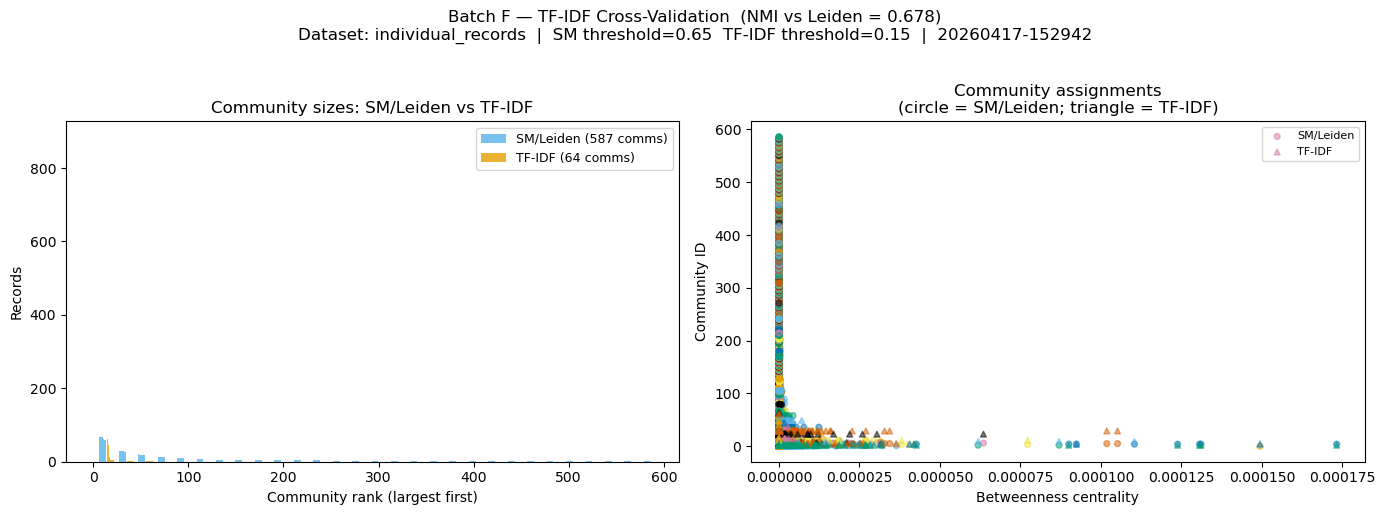

Saved to: /mnt/c/Users/jwb1n21/Dropbox/root/Southampton/Projects/ERC/code/visualisations/tfidf-comparison_individual_records_20260417-152942.png

Records where SM/Leiden and TF-IDF disagree are methodologically interesting:
inspect them to understand what each metric is detecting differently.


In [25]:
# ── Batch F figure: community size comparison and disagreement map ─────────────
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from collections import Counter

# Guard: only run if NMI was successfully computed
if nmi_cv is None:
    print("Batch F figure skipped: NMI could not be computed.")
    print("Re-run the Batch F setup and build cells first, then re-run this cell.")
else:
    nmi_label = f'{nmi_cv:.3f}'
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    fig.suptitle(
        f'Batch F — TF-IDF Cross-Validation  (NMI vs Leiden = {nmi_label})\n'
        f'Dataset: {DATASET_NAME}  |  SM threshold={GRAPH_THRESHOLD}  '
        f'TF-IDF threshold={TFIDF_THRESHOLD}  |  {RUN_DATETIME}',
        fontsize=12, y=1.02
    )

    # Panel 1: community size comparison
    ax = axes[0]
    sm_sizes    = sorted(Counter(leiden_part.values()).values(),    reverse=True)
    tfidf_sizes = sorted(Counter(partition_tfidf.values()).values(), reverse=True)
    x_sm = range(1, len(sm_sizes)    + 1)
    x_tf = range(1, len(tfidf_sizes) + 1)
    ax.bar([x - 0.2 for x in x_sm],  sm_sizes,    width=0.35,
           color=PALETTE[1], alpha=0.8, label=f'SM/Leiden ({len(sm_sizes)} comms)')
    ax.bar([x + 0.2 for x in x_tf],  tfidf_sizes, width=0.35,
           color=PALETTE[0], alpha=0.8, label=f'TF-IDF ({len(tfidf_sizes)} comms)')
    ax.set_title('Community sizes: SM/Leiden vs TF-IDF')
    ax.set_xlabel('Community rank (largest first)'); ax.set_ylabel('Records')
    ax.legend(fontsize=9)

    # Panel 2: disagreement map
    ax = axes[1]
    agree_df = pd.DataFrame({'film_ref': shared, 'sm_comm': l_sm, 'tfidf_comm': l_tf})
    if 'centrality_df' in dir() and centrality_df is not None:
        order_df = centrality_df[centrality_df['film_ref'].isin(shared)].set_index('film_ref')
        agree_df['betweenness'] = agree_df['film_ref'].map(order_df['betweenness'])
        x_vals = agree_df['betweenness'].fillna(0)
        x_label = 'Betweenness centrality'
    else:
        x_vals  = range(len(shared))
        x_label = 'Record index'

    ax.scatter(x_vals, agree_df['sm_comm'],
               c=[comm_colour(int(c)) for c in agree_df['sm_comm']],
               alpha=0.5, s=18, label='SM/Leiden', marker='o')
    ax.scatter(x_vals, agree_df['tfidf_comm'],
               c=[PALETTE[int(c) % len(PALETTE)] for c in agree_df['tfidf_comm']],
               alpha=0.5, s=18, label='TF-IDF', marker='^')
    ax.set_title('Community assignments\n(circle = SM/Leiden; triangle = TF-IDF)')
    ax.set_xlabel(x_label); ax.set_ylabel('Community ID')
    ax.legend(fontsize=8)

    plt.tight_layout()
    plot_path = os.path.join(VIS_DIR, f'tfidf-comparison_{DATASET_NAME}_{RUN_DATETIME}.png')
    plt.savefig(plot_path, dpi=150, bbox_inches='tight')
    plt.show()
    print(f"Saved to: {os.path.abspath(plot_path)}")
    print()
    print("Records where SM/Leiden and TF-IDF disagree are methodologically interesting:")
    print("inspect them to understand what each metric is detecting differently.")


In [26]:
# ── Batch F (ii) — Disagreement inspection ────────────────────────────────────
# Extracts all records where SM/Leiden and TF-IDF assign different communities,
# classifies each disagreement by type, ranks by interpretive significance, and
# presents the top candidates for qualitative close reading.
#
# Two types of disagreement:
#
#   Type 1 — Structure without vocabulary:
#     SM assigns to a large community (the record shares structural conventions
#     with many others) but TF-IDF assigns elsewhere (the record's vocabulary is
#     atypical within that SM community). This is the most analytically interesting
#     type: it suggests communities of practice that cut across subject matter —
#     exactly the research argument. The cataloguer learned structural habits from
#     one tradition but worked on content typical of another.
#
#   Type 2 — Vocabulary without structure:
#     TF-IDF assigns to a large community (shared vocabulary) but SM assigns
#     elsewhere (structurally distinctive). More likely to reflect records that
#     describe familiar content in an unusual structural format — possible template
#     deviation, record revision, or a short record where SM has little to work with.
#
# Severity ranking: records in large communities that disagree are more
# interpretively significant than noise disagreements in tiny communities.
# Betweenness centrality is used as the primary severity signal if available
# (high-betweenness disagreements sit at structural junctions); otherwise
# SM community size is used.

import pandas as pd
from collections import Counter

if nmi_cv is None:
    print("Batch F disagreement inspection skipped: NMI not computed.")
    print("Run the Batch F setup and build cells first.")
else:
    # ── Build agreement / disagreement table ──────────────────────────────────
    agree_df = pd.DataFrame({
        'film_ref' : shared,
        'sm_comm'  : l_sm,
        'tfidf_comm': l_tf
    })
    disagree_df = agree_df[agree_df['sm_comm'] != agree_df['tfidf_comm']].copy()

    n_total    = len(agree_df)
    n_disagree = len(disagree_df)
    print(f"Records in both partitions : {n_total:,}")
    print(f"Records that agree         : {n_total - n_disagree:,}  "
          f"({(1 - n_disagree/n_total)*100:.1f}%)")
    print(f"Records that disagree      : {n_disagree:,}  "
          f"({n_disagree/n_total*100:.1f}%)")
    print(f"NMI                        : {nmi_cv:.4f}")
    print()

    # ── Join description text ─────────────────────────────────────────────────
    _desc_src = desc_df_clean if 'desc_df_clean' in dir() and len(desc_df_clean) else desc_df
    _desc_map = dict(zip(_desc_src['film_ref'], _desc_src['description_text']))
    disagree_df['description'] = disagree_df['film_ref'].map(_desc_map).fillna('')

    # ── Community sizes ───────────────────────────────────────────────────────
    _sm_sizes = Counter(leiden_part.values())
    _tf_sizes = Counter(partition_tfidf.values())
    disagree_df['sm_comm_size']    = disagree_df['sm_comm'].map(_sm_sizes)
    disagree_df['tfidf_comm_size'] = disagree_df['tfidf_comm'].map(_tf_sizes)

    # ── Type classification ───────────────────────────────────────────────────
    # Type 1: SM community larger → record has established structural placement
    #         but unusual vocabulary → structure without vocabulary
    # Type 2: TF-IDF community larger → record has established vocabulary
    #         but unusual structure → vocabulary without structure
    disagree_df['type'] = disagree_df.apply(
        lambda r: 'Type 1  structure > vocab'
                  if r['sm_comm_size'] >= r['tfidf_comm_size']
                  else 'Type 2  vocab > structure',
        axis=1
    )

    # ── Severity: betweenness (preferred) or SM community size ────────────────
    if 'centrality_df' in dir() and centrality_df is not None:
        _cent_map = dict(zip(centrality_df['film_ref'], centrality_df['betweenness']))
        disagree_df['betweenness'] = disagree_df['film_ref'].map(_cent_map).fillna(0)
        _sev_col   = 'betweenness'
        _sev_label = 'betweenness centrality'
    else:
        disagree_df['betweenness'] = 0.0
        _sev_col   = 'sm_comm_size'
        _sev_label = 'SM community size'

    disagree_df = disagree_df.sort_values(_sev_col, ascending=False)

    # ── Type summary ──────────────────────────────────────────────────────────
    print("Disagreement type breakdown:")
    print(disagree_df['type'].value_counts().to_string())
    print()

    # ── Community profile lookup (from Batch C summary_plot if available) ─────
    _has_profiles = 'summary_plot' in dir() and summary_plot is not None
    _profile_cols = []
    if _has_profiles:
        _profile_cols = [c for c in
                         ['n_records', 'mean_word_count', 'pct_shotlist',
                          'mean_subjects', 'median_year']
                         if c in summary_plot.columns]

    # ── Close-reading output: top N disagreements ─────────────────────────────
    N_CLOSE = 5
    print(f"{'═'*72}")
    print(f"  Top {N_CLOSE} disagreements for close reading  (ranked by {_sev_label})")
    print(f"{'═'*72}")

    for rank, (_, row) in enumerate(disagree_df.head(N_CLOSE).iterrows(), 1):
        print(f"\n[{rank}]  {row['film_ref']}")
        print(f"     SM/Leiden  → C{int(row['sm_comm'])}  "
              f"(community size: {int(row['sm_comm_size'])})")
        print(f"     TF-IDF     → C{int(row['tfidf_comm'])}  "
              f"(community size: {int(row['tfidf_comm_size'])})")
        print(f"     Type       : {row['type']}")
        if row['betweenness'] > 0:
            print(f"     Betweenness: {row['betweenness']:.6f}")

        if _has_profiles:
            for label, cid in [('SM community  ', int(row['sm_comm'])),
                                ('TF-IDF community', int(row['tfidf_comm']))]:
                if cid in summary_plot.index:
                    p = summary_plot.loc[cid, _profile_cols]
                    parts = '  |  '.join(
                        f"{c.replace('_',' ')}={v:.2g}" for c, v in p.items()
                    )
                    print(f"     {label} profile: {parts}")

        desc = str(row['description']).strip()
        if desc:
            print(f"\n     Description:")
            lines = desc[:700].split('\n')
            for ln in lines:
                if ln.strip():
                    print(f"       {ln.strip()}")
            if len(desc) > 700:
                print(f"       [...{len(desc)-700} chars omitted...]")

    print(f"\n{'═'*72}")

    # ── Clustering: which SM communities have the highest disagreement rate? ──
    print()
    print("─── Disagreement rate by SM community ──────────────────────────────────")
    print("(Communities with high disagreement rates have internally diverse vocabulary,")
    print(" which supports the practice-community interpretation.)")
    print()
    _by_sm = (
        disagree_df.groupby('sm_comm')
        .agg(n_disagree=('film_ref', 'count'),
             n_type1=('type', lambda x: (x.str.startswith('Type 1')).sum()),
             comm_size=('sm_comm_size', 'first'))
        .assign(pct_disagree=lambda d: (d['n_disagree'] / d['comm_size'] * 100).round(1))
        .query('comm_size >= @MIN_COMM_SIZE')
        .sort_values('pct_disagree', ascending=False)
        .head(10)
    )
    _by_sm.index = [f'C{int(c)}' for c in _by_sm.index]
    print(_by_sm.rename(columns={
        'n_disagree': 'n disagree',
        'n_type1'   : 'n type-1',
        'comm_size' : 'comm size',
        'pct_disagree': '% disagree'
    }).to_string())
    print()
    print("─── Year clustering in disagreements ───────────────────────────────────")
    if 'features_df' in dir():
        _yr = features_df[['film_ref', 'year']].copy()
        _agree_yr  = agree_df[agree_df['sm_comm'] == agree_df['tfidf_comm']].merge(_yr, on='film_ref', how='left')
        _disagr_yr = disagree_df.merge(_yr, on='film_ref', how='left')
        print(f"  Median year — agreeing records   : {_agree_yr['year'].median():.0f}")
        print(f"  Median year — disagreeing records: {_disagr_yr['year'].median():.0f}")
        print("  (Substantial difference suggests temporal vocabulary drift within stable")
        print("   practice communities.)")
    else:
        print("  (features_df not in scope — run Batch C first for year clustering check.)")

    # ── Save ──────────────────────────────────────────────────────────────────
    _out_cols = ['film_ref', 'sm_comm', 'tfidf_comm', 'sm_comm_size',
                 'tfidf_comm_size', 'type', 'betweenness', 'description']
    _path = os.path.join(DERIVED_DATA_DIR,
                         f'disagreements-sm-vs-tfidf_{DATASET_NAME}_{RUN_DATETIME}.tsv')
    disagree_df[_out_cols].to_csv(_path, sep='\t', index=False)
    print(f"\nFull disagreement table (incl. description text) saved to:")
    print(f"  {os.path.abspath(_path)}")
    print()
    print("Close-reading guide:")
    print("  Type 1 — Ask: does this record FEEL structurally like its SM community?")
    print("    If yes: strong evidence for practice-driven community structure.")
    print("  Type 2 — Ask: is the structural departure meaningful or an artefact of")
    print("    record length / sparse text?")
    print("  Records disagreeing in LARGE SM communities are the most significant:")
    print("    they show the two metrics measuring genuinely different properties.")


Records in both partitions : 5,585
Records that agree         : 94  (1.7%)
Records that disagree      : 5,491  (98.3%)
NMI                        : 0.6779

Disagreement type breakdown:
type
Type 2  vocab > structure    5378
Type 1  structure > vocab     113

════════════════════════════════════════════════════════════════════════
  Top 5 disagreements for close reading  (ranked by betweenness centrality)
════════════════════════════════════════════════════════════════════════

[1]  (filmRef)T0105
     SM/Leiden  → C4  (community size: 93)
     TF-IDF     → C2  (community size: 415)
     Type       : Type 2  vocab > structure
     Betweenness: 0.000173
     SM community   profile: n records=93  |  mean word count=23  |  pct shotlist=0.99  |  mean subjects=0.32  |  median year=2e+03
     TF-IDF community profile: n records=3e+02  |  mean word count=31  |  pct shotlist=0  |  mean subjects=0.03  |  median year=2e+03

     Description:
       non-fiction Producer, Scottish Television. Shots

---
## Batch G — Validate that communities reflect practice, not subject matter

**Central question**: Do the communities produced by Louvain/Leiden detection cluster records by
*how they are written* (cataloguing practice, descriptive convention, knowledge-labour choices),
or merely by *what they describe* (subject matter)?

This distinction matters fundamentally for the project's intellectual claim. If communities
co-vary with topics — all the records about sport in one community, all the records about industry
in another — then the clustering is an artefact of content, and SM ratio is functioning as a
subject-similarity metric. If communities are topically diverse — records about many different
subjects grouped together — then the clustering must reflect something else: the language,
structure, and conventions of the descriptions themselves. That something else is practice.

**Method**: Extract all controlled-vocabulary subject headings from the original record files. Merge
with community assignments. For each community, compute three indicators of topical diversity:

1. **Shannon entropy** of the subject heading distribution. A community with one subject on every
   record has entropy of 0; a community where every record has a different subject has maximum entropy.
   Compare each community's entropy to the corpus-wide baseline (the entropy of the full dataset's
   subject distribution). Communities near the baseline are topically representative of the whole
   catalogue; communities well below it are topic-concentrated.

2. **Top-subject concentration**: the percentage of records in each community that share the single
   most common subject. A community where 60% of records share one subject is likely content-driven
   for that subject. A community where the most common subject appears in only 15–20% of records
   is consistent with practice-driven clustering.

3. **Subject prevalence heatmap**: for the top N most frequent subjects in the full corpus, what
   percentage of records in each community carry each subject? If the heatmap columns have similar
   shading across communities — subject X is equally common in all communities — then subjects are
   not driving community membership. If one community's column is markedly darker for a particular
   subject, that community may be topic-driven and warrants qualitative review.

**How to interpret the results**: A practice-driven result shows entropy close to the corpus
baseline, low top-subject concentration (below 30–40%), and roughly uniform heatmap columns.
A content-driven result shows entropy below baseline, high concentration, and distinctive heatmap
columns. Mixed results — some communities practice-driven, one or two with higher topic
concentration — are common and interpretable: the topically concentrated communities may reflect
a cataloguing campaign focused on a particular collection area rather than a general style.

**Requires**: `RECORDS_DIR` + `COMMUNITIES_TSV`  
**Produces**: `visualisations/subject-diversity_{dataset}_{datetime}.png`

In [27]:
# ── Batch G setup: extract subject headings from original records ───────────────
import os, re
import pandas as pd
from collections import Counter

assignments = pd.read_csv(COMMUNITIES_TSV, sep='\t')

print(f"Scanning {len(os.listdir(RECORDS_DIR)):,} records for subject headings — please wait...")
subject_records = []
n_missing = 0
for fname in sorted(os.listdir(RECORDS_DIR)):
    fpath = os.path.join(RECORDS_DIR, fname)
    with open(fpath, 'r', encoding='utf-8') as f:
        text = f.read()
    ref_match = re.search(r'\(filmRef\)([^<\s]+)', text)
    if not ref_match:
        n_missing += 1
        continue
    film_ref = '(filmRef)' + ref_match.group(1)
    subjects = re.findall(r'<dcterms:subject>([^<]+)</dcterms:subject>', text)
    for subj in subjects:
        subject_records.append({'film_ref': film_ref, 'subject': subj.strip()})

print(f"Scan complete.")
subjects_df = pd.DataFrame(subject_records)

# Merge with community assignments
merged_subj = subjects_df.merge(assignments, on='film_ref', how='inner')
comm_ids_uniq = sorted(assignments['community_id'].unique())
n_communities = len(comm_ids_uniq)

# Records with no subjects (un-indexed)
in_communities = assignments['film_ref'].unique()
records_no_subjects = set(in_communities) - set(subjects_df['film_ref'].unique())

print(f"Records in RECORDS_DIR         : {len(os.listdir(RECORDS_DIR))}")
print(f"Subject assignments extracted  : {len(subjects_df):,}")
print(f"Unique records with subjects   : {subjects_df['film_ref'].nunique()}")
print(f"Records in communities         : {len(in_communities)}")
print(f"Community records with subjects: {merged_subj['film_ref'].nunique()}")
print(f"Community records no subjects  : {len(records_no_subjects)}  (un-indexed or isolates)")
print(f"Unique subject terms (corpus)  : {subjects_df['subject'].nunique()}")
print(f"\nTop 10 subjects (corpus-wide):")
for subj, count in Counter(subjects_df['subject']).most_common(10):
    print(f"  {subj!r:45s}  {count:4d}")


Scanning 23,491 records for subject headings — please wait...
Scan complete.
Records in RECORDS_DIR         : 23491
Subject assignments extracted  : 22,690
Unique records with subjects   : 8870
Records in communities         : 5585
Community records with subjects: 1733
Community records no subjects  : 3852  (un-indexed or isolates)
Unique subject terms (corpus)  : 134

Top 10 subjects (corpus-wide):
  'Gaelic'                                       2105
  'Leisure and Recreation'                       1153
  'Glasgow'                                       991
  'Transport'                                     733
  'Employment, Industry and Industrial Relations'   731
  'Edinburgh'                                     720
  'Sporting Activities'                           639
  'Ships and Shipping'                            567
  'Education'                                     531
  'Celebrations, Traditions and Customs'          504


In [28]:
# ── Batch G: diversity metrics per community ────────────────────────────────────
import numpy as np
from scipy.stats import entropy as shannon_entropy

# Corpus-wide baseline: entropy of the overall subject distribution
corpus_counts = Counter(subjects_df['subject'])
corpus_ent = shannon_entropy(list(corpus_counts.values()), base=2)

metrics = []
for c in comm_ids_uniq:
    comm_subj = merged_subj[merged_subj['community_id'] == c]['subject']
    n_records  = merged_subj[merged_subj['community_id'] == c]['film_ref'].nunique()
    counts     = Counter(comm_subj)
    if not counts:
        metrics.append({'community': c, 'n_records': n_records,
                        'entropy': 0, 'n_unique_subjects': 0,
                        'top_subject': 'n/a', 'top_subject_pct': 0})
        continue
    ent             = shannon_entropy(list(counts.values()), base=2)
    top_subj, top_n = counts.most_common(1)[0]
    top_pct         = top_n / n_records * 100
    metrics.append({
        'community':        c,
        'n_records':        n_records,
        'entropy':          round(ent, 3),
        'n_unique_subjects': len(counts),
        'top_subject':      top_subj,
        'top_subject_pct':  round(top_pct, 1),
    })

metrics_df = pd.DataFrame(metrics).set_index('community')

print(f"Corpus-wide subject entropy (baseline): {corpus_ent:.3f} bits\n")
# Show only communities meeting minimum size
_m = assignments.groupby('community_id').size()
_show_comms_g = [c for c in comm_ids_uniq if _m.get(c, 0) >= MIN_COMM_SIZE]
print(f"Community subject diversity (n >= {MIN_COMM_SIZE}, {len(_show_comms_g)} communities):")
print(metrics_df.loc[_show_comms_g].to_string())
print()
print("Interpretation:")
print("  entropy close to corpus baseline → community is topically diverse → practice-driven")
print("  high top_subject_pct (> ~40%)    → community may be topic-driven → inspect manually")


Corpus-wide subject entropy (baseline): 6.003 bits

Community subject diversity (n >= 10, 95 communities):
           n_records  entropy  n_unique_subjects                                       top_subject  top_subject_pct
community                                                                                                          
0                166    0.000                  1                                            Gaelic            100.0
1                156    0.000                  1                                            Gaelic            100.0
2                 10    0.000                  1                                            Gaelic            100.0
3                 88    0.000                  1                                            Gaelic            100.0
4                 28    0.627                  4                                Ships and Shipping             96.4
5                 40    0.000                  1                                 

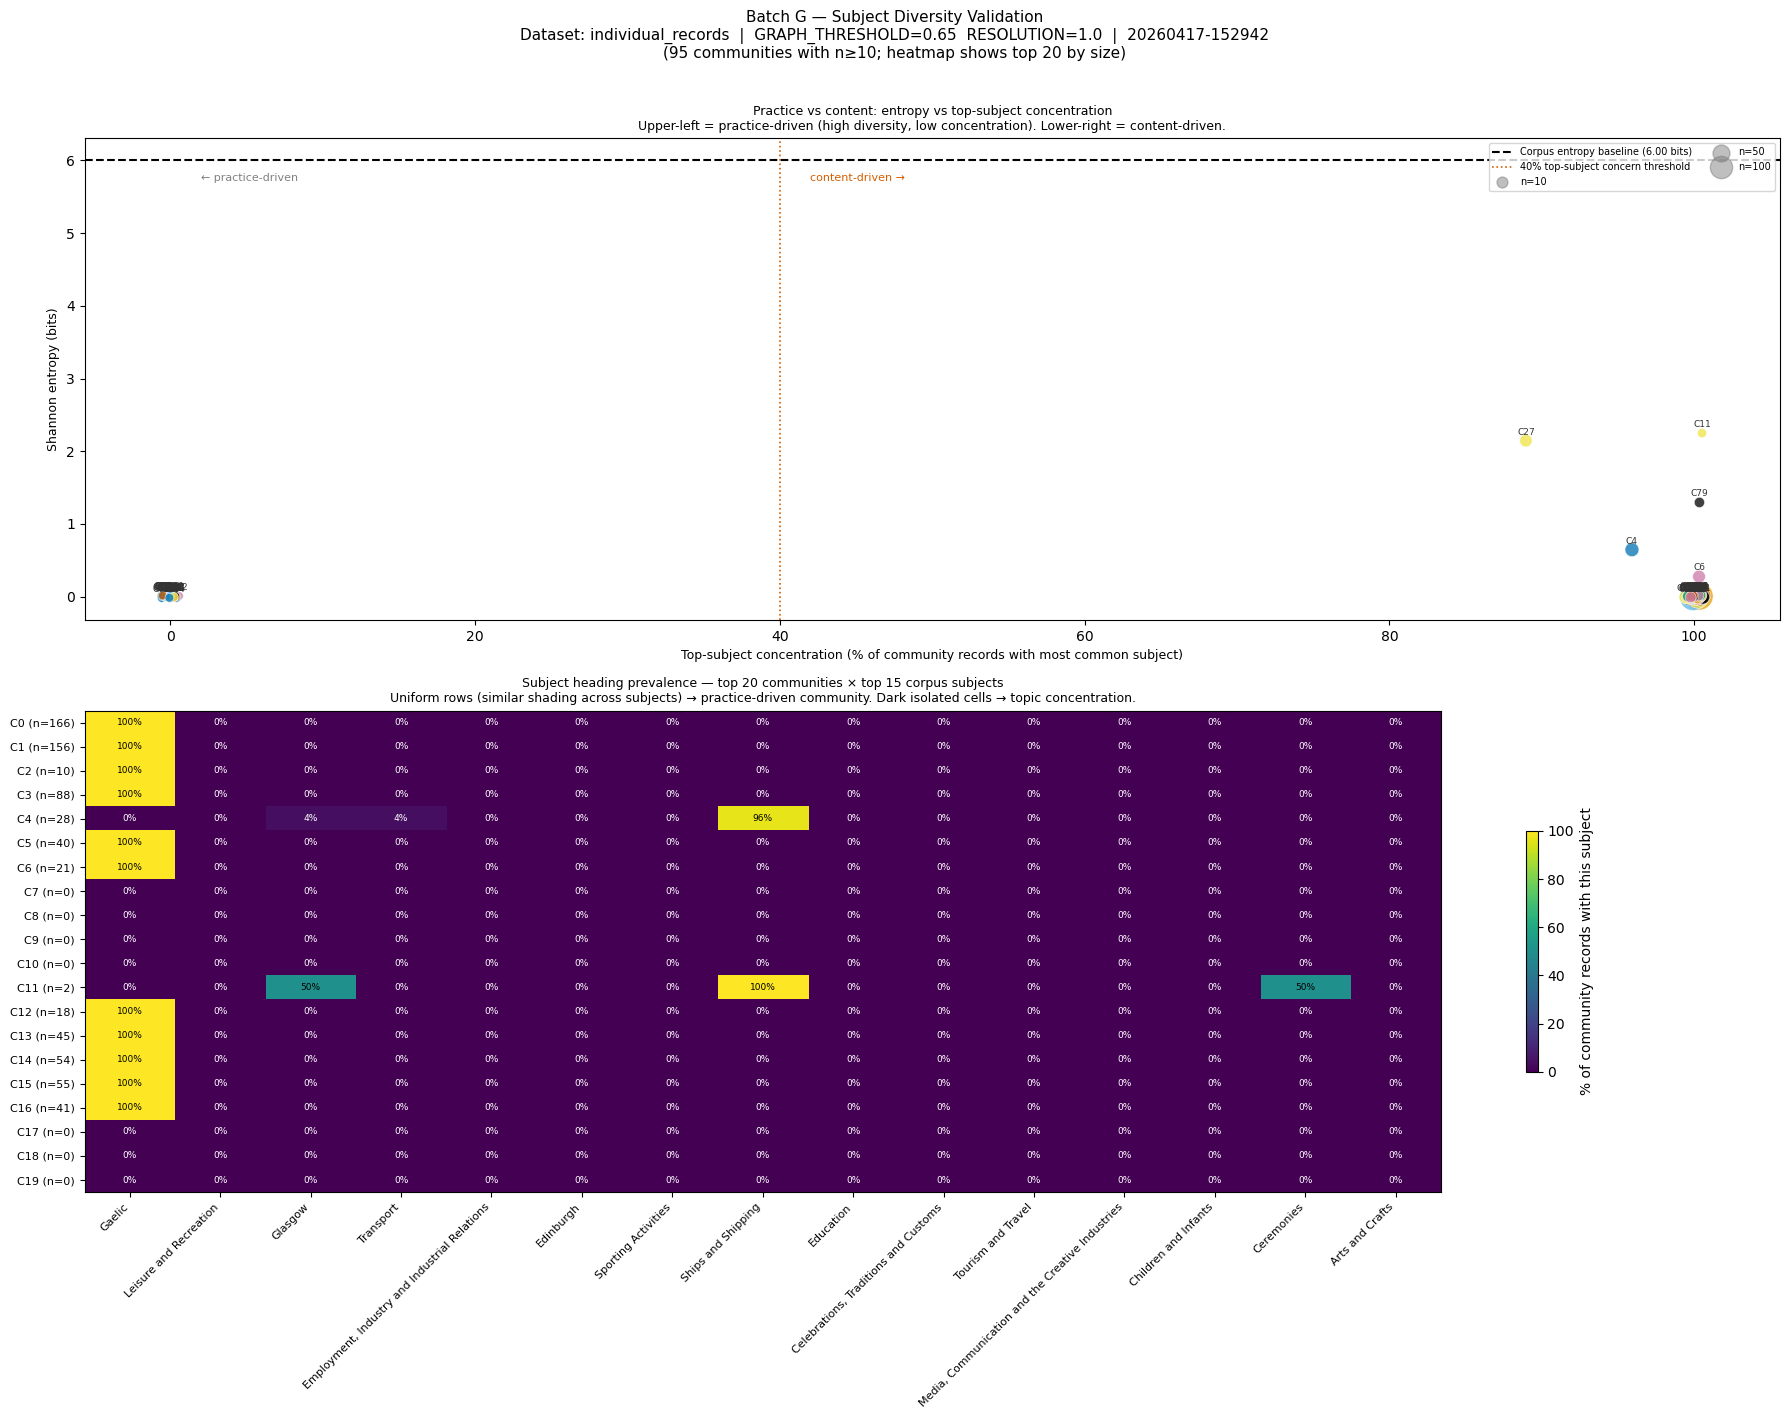

Saved to: /mnt/c/Users/jwb1n21/Dropbox/root/Southampton/Projects/ERC/code/visualisations/subject-diversity_individual_records_20260417-152942.png

BATCH G VERDICT TABLE
  Corpus entropy baseline: 6.003 bits
  Practice-driven:  entropy >= 5.103 (85% of baseline) AND top_subject_pct < 40%
  Content-driven:   entropy <  4.202 (70% of baseline) OR  top_subject_pct >= 40%
  Borderline:       everything else
  Community    n_records  entropy  top_subj%  top_subject                     verdict
------------------------------------------------------------------------
  C0                166    0.000     100.0%  Gaelic                          content-driven
  C1                156    0.000     100.0%  Gaelic                          content-driven
  C2                 10    0.000     100.0%  Gaelic                          content-driven
  C3                 88    0.000     100.0%  Gaelic                          content-driven
  C4                 28    0.627      96.4%  Ships and Shipping    

In [29]:
# ── Batch G: figure — scatter + heatmap + verdict table ────────────────────────
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np

TOP_N_SUBJECTS = 15   # subjects to show in heatmap

# Communities to show (MIN_COMM_SIZE filter), sorted largest-first
_size_g = assignments.groupby('community_id').size()
plot_comm_g = [c for c in comm_ids_uniq if _size_g.get(c, 0) >= MIN_COMM_SIZE]
plot_comm_g = sorted(plot_comm_g, key=lambda c: _size_g.get(c, 0), reverse=True)

# ── Build subject prevalence matrix ───────────────────────────────────────────
top_subjects = [s for s, _ in corpus_counts.most_common(TOP_N_SUBJECTS)]
n_per_comm   = merged_subj.groupby('community_id')['film_ref'].nunique()
heatmap_rows = []
for subj in top_subjects:
    row = {}
    subj_records = merged_subj[merged_subj['subject'] == subj]
    for c in plot_comm_g:
        n_with = subj_records[subj_records['community_id'] == c]['film_ref'].nunique()
        row[c]  = n_with / n_per_comm.get(c, 1) * 100
    heatmap_rows.append(row)
heatmap_df = pd.DataFrame(heatmap_rows, index=top_subjects, columns=plot_comm_g)

# ── Scatter: entropy vs top-subject concentration ─────────────────────────────
# Cap heatmap to PROFILE_TOP_N communities (largest by record count)
heatmap_comm = plot_comm_g[:PROFILE_TOP_N]
heatmap_display = heatmap_df[heatmap_comm]   # subjects (rows) × communities (cols)

fig = plt.figure(figsize=(18, 14))
fig.suptitle(
    f'Batch G — Subject Diversity Validation\n'
    f'Dataset: {DATASET_NAME}  |  GRAPH_THRESHOLD={GRAPH_THRESHOLD}  '
    f'RESOLUTION={RESOLUTION}  |  {RUN_DATETIME}\n'
    f'({len(plot_comm_g)} communities with n≥{MIN_COMM_SIZE}; heatmap shows top {PROFILE_TOP_N} by size)',
    fontsize=11, y=1.01
)

# -- Panel 1 (top-left): scatter -----------------------------------------------
ax_scatter = fig.add_subplot(2, 1, 1)

entropies    = [metrics_df.loc[c, 'entropy']         for c in plot_comm_g]
top_pcts     = [metrics_df.loc[c, 'top_subject_pct'] for c in plot_comm_g]
sizes        = [metrics_df.loc[c, 'n_records']       for c in plot_comm_g]
colors       = [comm_colour(c) for c in plot_comm_g]

# Scale bubble sizes: min 40, max 400
_s_arr = np.array(sizes, dtype=float)
if _s_arr.max() > _s_arr.min():
    bubble_sizes = 40 + 360 * (_s_arr - _s_arr.min()) / (_s_arr.max() - _s_arr.min())
else:
    bubble_sizes = np.full(len(_s_arr), 120.0)

# Small jitter so overlapping points (esp. zero-subject communities) spread apart
_rng = np.random.default_rng(42)   # fixed seed for reproducibility
_jitter_x = _rng.uniform(-0.6, 0.6, len(top_pcts))
_jitter_y = _rng.uniform(-0.02, 0.02, len(entropies))
top_pcts_j  = [x + j for x, j in zip(top_pcts,  _jitter_x)]
entropies_j = [y + j for y, j in zip(entropies, _jitter_y)]
sc = ax_scatter.scatter(top_pcts_j, entropies_j, s=bubble_sizes, c=colors,
                        alpha=0.75, edgecolors='white', linewidths=0.5)

# Corpus baseline and concern threshold
ax_scatter.axhline(corpus_ent, color='black', linewidth=1.5, linestyle='--',
                   label=f'Corpus entropy baseline ({corpus_ent:.2f} bits)')
ax_scatter.axvline(40, color=PALETTE[5], linewidth=1.2, linestyle=':',
                   label='40% top-subject concern threshold')

# Quadrant annotations
ax_scatter.text(2,  corpus_ent * 0.97,  '← practice-driven',
                fontsize=8, color='grey', va='top')
ax_scatter.text(42, corpus_ent * 0.97, 'content-driven →',
                fontsize=8, color=PALETTE[5], va='top')

# Label each community
for c, x, y in zip(plot_comm_g, top_pcts_j, entropies_j):
    ax_scatter.annotate(f'C{c}', (x, y), fontsize=6.5, ha='center', va='bottom',
                        xytext=(0, 3), textcoords='offset points', color='#333333')

ax_scatter.set_xlabel('Top-subject concentration (% of community records with most common subject)', fontsize=9)
ax_scatter.set_ylabel('Shannon entropy (bits)', fontsize=9)
ax_scatter.set_title(
    'Practice vs content: entropy vs top-subject concentration\n'
    'Upper-left = practice-driven (high diversity, low concentration). '    'Lower-right = content-driven.',
    fontsize=9
)
ax_scatter.legend(fontsize=8)

# Size legend (approximate)
for target_n in [10, 50, 100]:
    if target_n <= _s_arr.max():
        _sz = 40 + 360 * (target_n - _s_arr.min()) / max(_s_arr.max() - _s_arr.min(), 1)
        ax_scatter.scatter([], [], s=_sz, color='grey', alpha=0.5, label=f'n={target_n}')
ax_scatter.legend(fontsize=7, loc='upper right', ncol=2)

# -- Panel 2 (bottom): heatmap (communities as rows, subjects as columns) ------
ax_heat = fig.add_subplot(2, 1, 2)

# Transpose: rows = communities (y), columns = subjects (x)
heatmap_T = heatmap_display.T.values.astype(float)   # shape: (n_comm, n_subj)
community_labels = [f'C{c} (n={n_per_comm.get(c,0)})' for c in heatmap_comm]

im = ax_heat.imshow(heatmap_T, aspect='auto', cmap='viridis', vmin=0, vmax=100)

for i, c in enumerate(heatmap_comm):
    for j, subj in enumerate(top_subjects):
        val = heatmap_T[i, j]
        txt_color = 'white' if val < 40 else 'black'
        ax_heat.text(j, i, f'{val:.0f}%', ha='center', va='center',
                     fontsize=6.5, color=txt_color)

ax_heat.set_xticks(range(len(top_subjects)))
ax_heat.set_xticklabels(top_subjects, rotation=45, ha='right', fontsize=8)
ax_heat.set_yticks(range(len(heatmap_comm)))
ax_heat.set_yticklabels(community_labels, fontsize=8)
ax_heat.set_title(
    f'Subject heading prevalence — top {PROFILE_TOP_N} communities × top {TOP_N_SUBJECTS} corpus subjects\n'
    'Uniform rows (similar shading across subjects) → practice-driven community. '
    'Dark isolated cells → topic concentration.',
    fontsize=9
)
plt.colorbar(im, ax=ax_heat, label='% of community records with this subject', shrink=0.5)

plt.tight_layout()
plot_path = os.path.join(VIS_DIR, f'subject-diversity_{DATASET_NAME}_{RUN_DATETIME}.png')
plt.savefig(plot_path, dpi=150, bbox_inches='tight')
plt.show()
print(f"Saved to: {os.path.abspath(plot_path)}")

# ── Verdict table ─────────────────────────────────────────────────────────────
print()
print("=" * 72)
print("BATCH G VERDICT TABLE")
print(f"  Corpus entropy baseline: {corpus_ent:.3f} bits")
print(f"  Practice-driven:  entropy >= {corpus_ent*0.85:.3f} (85% of baseline) AND top_subject_pct < 40%")
print(f"  Content-driven:   entropy <  {corpus_ent*0.70:.3f} (70% of baseline) OR  top_subject_pct >= 40%")
print(f"  Borderline:       everything else")
print("=" * 72)
print(f"  {'Community':<12} {'n_records':>9} {'entropy':>8} {'top_subj%':>10}  {'top_subject':<30}  verdict")
print("-" * 72)

n_practice = 0; n_content = 0; n_border = 0
for c in plot_comm_g:
    ent = metrics_df.loc[c, 'entropy']
    pct = metrics_df.loc[c, 'top_subject_pct']
    top = str(metrics_df.loc[c, 'top_subject'])[:28]
    n   = int(metrics_df.loc[c, 'n_records'])
    if ent >= corpus_ent * 0.85 and pct < 40:
        verdict = "practice-driven"
        n_practice += 1
    elif ent < corpus_ent * 0.70 or pct >= 40:
        verdict = "content-driven"
        n_content += 1
    else:
        verdict = "borderline"
        n_border += 1
    print(f"  C{c:<10} {n:>9} {ent:>8.3f} {pct:>9.1f}%  {top:<30}  {verdict}")

print("=" * 72)
print(f"  Summary: {n_practice} practice-driven  |  {n_border} borderline  |  {n_content} content-driven")
print()
# ── Crowded-corner table: communities near origin (no/few subjects) ───────────
_corner = [
    (c, int(metrics_df.loc[c, 'n_records']),
        metrics_df.loc[c, 'entropy'],
        metrics_df.loc[c, 'top_subject_pct'],
        str(metrics_df.loc[c, 'top_subject'])[:30])
    for c in plot_comm_g
    if metrics_df.loc[c, 'top_subject_pct'] < 5 and
       metrics_df.loc[c, 'entropy'] < corpus_ent * 0.30
]
if _corner:
    print()
    print("─" * 72)
    print("CROWDED CORNER — communities near origin (entropy < 30% baseline, top_subject < 5%)")
    print("(these points overlap in the scatter; listed here for precise reading)")
    print(f"  {'Community':<12} {'n_records':>9} {'entropy':>8} {'top_subj%':>10}  {'top_subject':<30}")
    print("-" * 72)
    for c, n, ent, pct, top in _corner:
        print(f"  C{c:<10} {n:>9} {ent:>8.3f} {pct:>9.1f}%  {top:<30}")
    print("─" * 72)
    print(f"  Note: jitter of ±0.6% x / ±0.02 bits y applied to scatter for legibility.")

print("Interpretation:")
print("  A predominantly practice-driven result supports the core argument that")
print("  communities reflect cataloguing convention, not shared subject matter.")
print("  Content-driven communities warrant manual inspection — they may reflect")
print("  topic-specific cataloguing campaigns rather than stable practice communities.")


---
## Batch H — Year of creation: content proxy or practice proxy?

**Central question**: The `year` field in catalogue records records the *year of the film* (or
for other collections: year of publication, year the artwork was made). This is **not** the same
as the year the record was *catalogued*. Before treating year as a proxy for when cataloguing
happened — and therefore for which cataloguing norms were in force — this batch tests whether
the year variable is doing something else entirely.

Two possible confounds:

1. **Year as a content proxy**: Films from the 1930s describe different subjects than films from
   the 1990s. If communities cluster by year, this could simply reflect that the SequenceMatcher
   is picking up shared subject matter (films about wartime Britain, films about sport in a
   particular era) rather than shared cataloguing practice. In this case, `year` is a content
   variable and cannot be used to date cataloguing activity.

2. **Year as a practice proxy (legitimate)**: Cataloguing norms genuinely changed over time. If
   year correlates with *how* records are written (word count, structural features, controlled
   vocabulary depth) *independently of subject matter*, then year is doing useful work. This
   is the assumption embedded in panel 3 of Batch C's figure.

**Method**: Compute Spearman rank correlations between `year` and each knowledge-labour feature
(practice signals) and each subject-related variable (content signals). Spearman is appropriate
because year is ordinal and feature distributions are typically non-normal.

A practice-driven result shows strong correlations with structural features (`desc_word_count`,
`has_shotlist`, `n_desc_fields`) but weak correlations with subject signals. A content-driven
result shows the opposite. A mixed result — moderate correlations on both sides — means year
partially conflates the two and should be treated with caution.

**Requires**: `FEATURES_TSV` + `COMMUNITIES_TSV` + `RECORDS_DIR`  
**Produces**: `visualisations/year-correlation_{dataset}_{datetime}.png`


In [30]:
# ── Batch H setup: assemble year + practice + subject variables ────────────────
import os, re
import pandas as pd
import numpy as np
from scipy import stats
from collections import Counter

features_df  = pd.read_csv(FEATURES_TSV, sep='	')
assignments  = pd.read_csv(COMMUNITIES_TSV, sep='	')
merged_h     = features_df.merge(assignments, on='film_ref', how='inner')

# ── Practice features (how records are written) ────────────────────────────────
practice_cols = {
    'desc_word_count'  : 'Description word count',
    'n_desc_fields'    : 'N description fields',
    'has_shotlist'     : 'Has SHOTLIST (0/1)',
    'has_credit_line'  : 'Has credit line (0/1)',
    'has_timecodes'    : 'Has timecodes (0/1)',
    'n_subjects'       : 'N subject headings',
}
# Ensure all expected columns exist
practice_cols = {k: v for k, v in practice_cols.items() if k in merged_h.columns}

# ── Subject/content variables: re-extract from RECORDS_DIR ────────────────────
# We compute per-record subject count and presence of top-5 subjects as dummies.
subject_records = []
for fname in sorted(os.listdir(RECORDS_DIR)):
    fpath = os.path.join(RECORDS_DIR, fname)
    try:
        text = open(fpath, encoding='utf-8').read()
    except Exception:
        continue
    ref_match = re.search(r'\(filmRef\)([^<\s]+)', text)
    if not ref_match:
        continue
    film_ref = '(filmRef)' + ref_match.group(1)
    subjects = re.findall(r'<dcterms:subject>([^<]+)</dcterms:subject>', text)
    subject_records.append({'film_ref': film_ref, 'subjects': subjects})

subj_df = pd.DataFrame(subject_records)
subj_df['n_subjects_raw'] = subj_df['subjects'].apply(len)

# Top 5 corpus subjects → binary dummies (1 if record has that subject)
all_subj = [s for row in subj_df['subjects'] for s in row]
top5_subjects = [s for s, _ in Counter(all_subj).most_common(5)]
for subj in top5_subjects:
    col = 'subj_' + re.sub(r'[^a-zA-Z0-9]', '_', subj)[:25]
    subj_df[col] = subj_df['subjects'].apply(lambda ss: int(subj in ss))

subj_df = subj_df.drop(columns=['subjects'])
merged_h = merged_h.merge(subj_df, on='film_ref', how='left')

# Drop records with missing year (cannot compute correlation)
merged_h_yr = merged_h.dropna(subset=['year'])
print(f"Records with year data: {len(merged_h_yr)} of {len(merged_h)}")
print(f"Year range: {int(merged_h_yr['year'].min())} – {int(merged_h_yr['year'].max())}")
print(f"\nTop 5 corpus subjects (used as binary dummies):")
for s in top5_subjects:
    print(f"  {s}")


Records with year data: 3069 of 5585
Year range: 1926 – 2022

Top 5 corpus subjects (used as binary dummies):
  Gaelic
  Leisure and Recreation
  Glasgow
  Transport
  Employment, Industry and Industrial Relations


In [31]:
# ── Batch H: Spearman correlations — year vs practice and content signals ──────
from scipy.stats import spearmanr

content_cols = {
    'n_subjects_raw'  : 'N subject headings (raw)',
}
# Add subject dummy columns
for col in merged_h_yr.columns:
    if col.startswith('subj_'):
        label = col.replace('subj_', '').replace('_', ' ').strip()
        content_cols[col] = f'Subject: {label[:28]}'

all_cols = {**practice_cols, **content_cols}
results = []
year_vals = merged_h_yr['year'].values

for col, label in all_cols.items():
    if col not in merged_h_yr.columns:
        continue
    vals = merged_h_yr[col].fillna(0).values
    rho, p = spearmanr(year_vals, vals)
    category = 'Practice (how written)' if col in practice_cols else 'Content (what described)'
    results.append({'Feature': label, 'Category': category,
                    'Spearman rho': round(rho, 4), 'p-value': round(p, 4),
                    'Significant (p<0.05)': p < 0.05})

corr_df = pd.DataFrame(results).sort_values('Spearman rho', key=abs, ascending=False)
print("Spearman correlations: year vs feature")
print("=" * 70)
print(corr_df.to_string(index=False))
print()
print("Interpretation:")
print("  Large |rho| for practice features → year tracks cataloguing conventions over time")
print("  Large |rho| for content features  → year tracks subject matter, not practice")
print("  Both strong → year conflates the two; treat as a confounder, not a predictor")


Spearman correlations: year vs feature
                          Feature                 Category  Spearman rho  p-value  Significant (p<0.05)
             N description fields   Practice (how written)       -0.4600   0.0000                  True
               Has SHOTLIST (0/1)   Practice (how written)       -0.3462   0.0000                  True
              Has timecodes (0/1)   Practice (how written)       -0.3135   0.0000                  True
                  Subject: Gaelic Content (what described)        0.1511   0.0000                  True
Subject: Employment  Industry and Content (what described)       -0.1037   0.0000                  True
  Subject: Leisure and Recreation Content (what described)       -0.0689   0.0001                  True
            Has credit line (0/1)   Practice (how written)        0.0623   0.0006                  True
               Subject: Transport Content (what described)       -0.0593   0.0010                  True
           Description wo

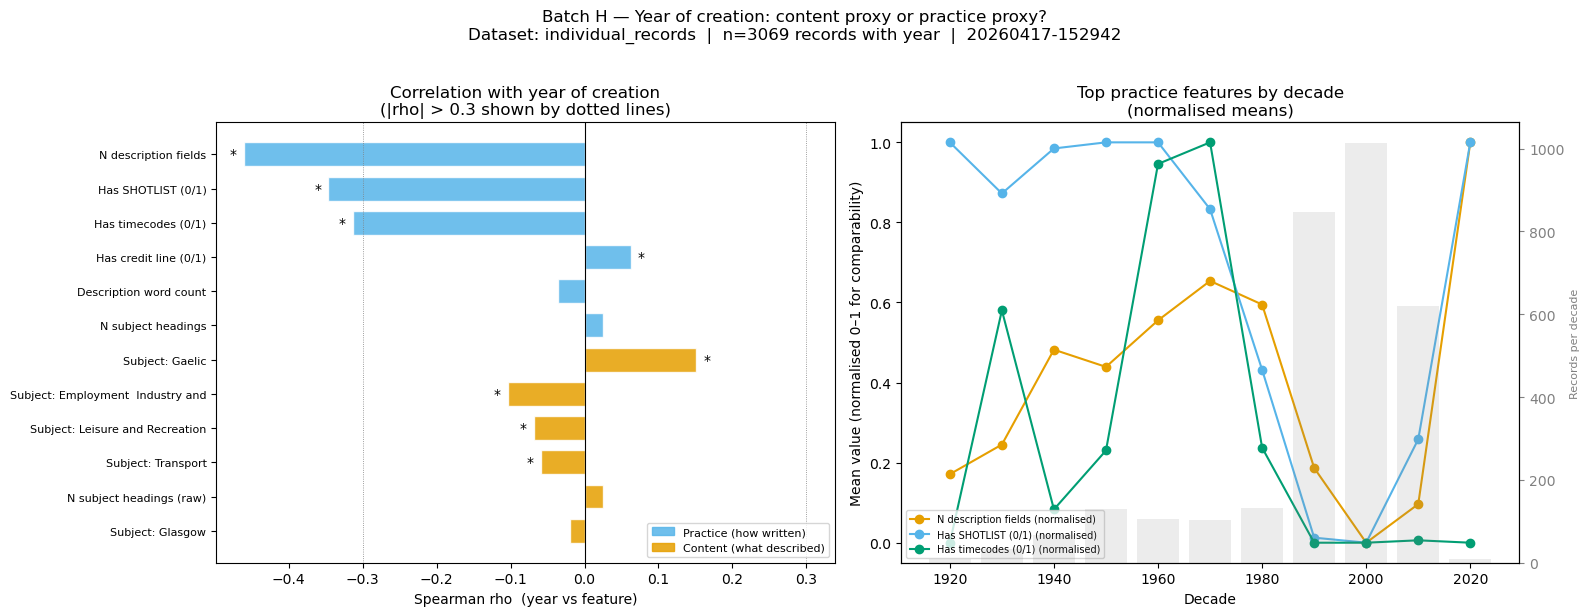

Saved to: /mnt/c/Users/jwb1n21/Dropbox/root/Southampton/Projects/ERC/code/visualisations/year-correlation_individual_records_20260417-152942.png

Key interpretive questions:
  1. Is the pattern in Panel 1 dominated by content or practice features?
  2. In Panel 2, do practice features trend monotonically with decade,
     or do they vary non-linearly (suggesting campaigns rather than drift)?
  3. If year correlates more with content than practice, remove or control
     for year in subsequent analyses, or replace it with a direct cataloguing-
     era variable if one can be reconstructed from the records.


In [32]:
# ── Batch H figure: correlation heatmap + decade-level practice trends ─────────
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle(
    f'Batch H — Year of creation: content proxy or practice proxy?\n'
    f'Dataset: {DATASET_NAME}  |  n={len(merged_h_yr)} records with year  |  {RUN_DATETIME}',
    fontsize=12, y=1.02
)

# ── Panel 1: Spearman rho bar chart, coloured by category ─────────────────────
ax = axes[0]
practice_rows = corr_df[corr_df['Category'] == 'Practice (how written)']
content_rows  = corr_df[corr_df['Category'] == 'Content (what described)']
ordered = pd.concat([practice_rows, content_rows]).reset_index(drop=True)
rhos    = ordered['Spearman rho'].values
labels  = ordered['Feature'].values
colors  = [PALETTE[1] if c == 'Practice (how written)' else PALETTE[0]
           for c in ordered['Category']]

y_pos = np.arange(len(ordered))
bars  = ax.barh(y_pos, rhos, color=colors, alpha=0.85, edgecolor='white', height=0.7)
ax.axvline(0, color='black', linewidth=0.8, linestyle='-')
ax.axvline( 0.3, color='grey', linewidth=0.6, linestyle=':')
ax.axvline(-0.3, color='grey', linewidth=0.6, linestyle=':')
ax.set_yticks(y_pos); ax.set_yticklabels(labels, fontsize=8)
ax.set_xlabel('Spearman rho  (year vs feature)')
ax.set_title('Correlation with year of creation\n(|rho| > 0.3 shown by dotted lines)')
ax.invert_yaxis()

practice_patch = mpatches.Patch(color=PALETTE[1], alpha=0.85, label='Practice (how written)')
content_patch  = mpatches.Patch(color=PALETTE[0], alpha=0.85, label='Content (what described)')
ax.legend(handles=[practice_patch, content_patch], fontsize=8, loc='lower right')

# Mark significant results
for i, (_, row) in enumerate(ordered.iterrows()):
    if row['Significant (p<0.05)']:
        ax.text(row['Spearman rho'] + (0.01 if row['Spearman rho'] >= 0 else -0.01),
                i, '*', va='center', ha='left' if row['Spearman rho'] >= 0 else 'right',
                fontsize=10, color='black')

# ── Panel 2: decade-level trends for top practice features ────────────────────
ax = axes[1]
merged_h_yr2 = merged_h_yr.copy()
merged_h_yr2['decade'] = (merged_h_yr2['year'] // 10 * 10).astype(int)
decade_groups = sorted(merged_h_yr2['decade'].unique())

# Select up to 3 practice features with largest |rho|
top_practice = practice_rows.reindex(
    practice_rows['Spearman rho'].abs().sort_values(ascending=False).index
).head(3)

for idx, (_, feat_row) in enumerate(top_practice.iterrows()):
    col   = [k for k, v in all_cols.items() if v == feat_row['Feature']]
    if not col or col[0] not in merged_h_yr2.columns:
        continue
    col = col[0]
    # Normalise to 0–1 range for comparability across features
    vals = merged_h_yr2.groupby('decade')[col].mean()
    vmin, vmax = vals.min(), vals.max()
    normed = (vals - vmin) / (vmax - vmin) if vmax > vmin else vals * 0
    ax.plot(normed.index, normed.values, marker='o', linewidth=1.5,
            color=PALETTE[idx], label=f'{feat_row["Feature"]} (normalised)')

ax.set_xlabel('Decade')
ax.set_ylabel('Mean value (normalised 0–1 for comparability)')
ax.set_title('Top practice features by decade\n(normalised means)')
ax.legend(fontsize=7)
# Mark decade sample sizes
ax2r = ax.twinx()
decade_n = merged_h_yr2.groupby('decade').size()
ax2r.bar(decade_n.index, decade_n.values, width=8, alpha=0.15,
         color='grey', label='N records')
ax2r.set_ylabel('Records per decade', fontsize=8, color='grey')
ax2r.tick_params(axis='y', colors='grey')

plt.tight_layout()
plot_path = os.path.join(VIS_DIR, f'year-correlation_{DATASET_NAME}_{RUN_DATETIME}.png')
plt.savefig(plot_path, dpi=150, bbox_inches='tight')
plt.show()
print(f"Saved to: {os.path.abspath(plot_path)}")
print()
print("Key interpretive questions:")
print("  1. Is the pattern in Panel 1 dominated by content or practice features?")
print("  2. In Panel 2, do practice features trend monotonically with decade,")
print("     or do they vary non-linearly (suggesting campaigns rather than drift)?")
print("  3. If year correlates more with content than practice, remove or control")
print("     for year in subsequent analyses, or replace it with a direct cataloguing-")
print("     era variable if one can be reconstructed from the records.")


---
## Batch I — Timecode convention analysis

**Question:** Do cataloguing communities differ systematically in *how they write timecodes*?

Timecode format is a micro-level convention — invisible to content analysis — that is learned and
reproduced within working groups. If communities differ in their preferred separator character
(colons vs periods), zero-padding discipline, or component count (two-part vs three-part), that
constitutes fine-grained evidence of distinct training regimes or institutional inheritance.

**Note on dates:** Publication year is used here as a temporal proxy. Accession dates would be
preferable (and could reveal campaign-level convention shifts), but are not yet available in this
dataset. The year analysis below should be read as an approximation pending primary-source
accession data.

The batch classifies each extracted timecode into one of six canonical format families:

| Label | Example |
|---|---|
| `HH:MM:SS (zero-padded)` | `01:23:45` |
| `H:MM:SS (unpadded)` | `1:23:45` |
| `HH.MM.SS (period sep.)` | `01.23.45` |
| `MM:SS / HH:MM (zero-padded)` | `01:23` |
| `M:SS / H:MM (unpadded)` | `1:23` |
| `SMPTE HH:MM:SS:FF` | `00:01:23:12` |

Three analytical outputs:
1. **Format mix per community** (stacked bar) — distinct colour profiles indicate distinct training regimes.
2. **Format usage by decade** (stacked bar) — step-changes may indicate policy shifts or cohort turnover.
3. **Convention discipline scatter** (entropy vs community size) — low-entropy communities use one format almost exclusively.

**Requires**: `RECORDS_DIR` + `COMMUNITIES_TSV` + `FEATURES_TSV` (uses `desc_df` from Batch F if already in memory; rebuilds otherwise)
**Produces**: `visualisations/timecode-conventions_{dataset}_{datetime}.png`

In [33]:
# ── Batch I setup: extract and classify timecode formats from SHOTLIST sections ─
import os, re
import pandas as pd
import numpy as np
from collections import Counter

COMMUNITIES_TSV = 'derived-data/communities_individual_records_20260316-151624.tsv'

# ── Rebuild description text if Batch F has not been run ──────────────────────
try:
    _ = desc_df
    print(f"Using desc_df from Batch F ({len(desc_df)} records).")
except NameError:
    _leiden_i = set(pd.read_csv(COMMUNITIES_TSV, sep='\t')['film_ref'])
    _desc_recs = []
    for fname in sorted(os.listdir(RECORDS_DIR)):
        fpath = os.path.join(RECORDS_DIR, fname)
        try:
            text = open(fpath, encoding='utf-8').read()
        except Exception:
            continue
        ref_match = re.search(r'\(filmRef\)([^<\s]+)', text)
        if not ref_match:
            continue
        film_ref = '(filmRef)' + ref_match.group(1)
        descs    = re.findall(r'<dcterms:description>(.*?)</dcterms:description>',
                              text, re.DOTALL)
        _desc_recs.append({'film_ref': film_ref,
                           'description_text': ' '.join(d.strip() for d in descs)})
    desc_df = pd.DataFrame(_desc_recs)
    desc_df = desc_df[desc_df['film_ref'].isin(_leiden_i)].reset_index(drop=True)
    print(f"Rebuilt desc_df: {len(desc_df)} records.")

# ── Load community and feature tables ─────────────────────────────────────────
_assignments_i = pd.read_csv(COMMUNITIES_TSV, sep='\t')
_features_i    = pd.read_csv(FEATURES_TSV, sep='\t')

# ── Regex patterns ─────────────────────────────────────────────────────────────
# SHOTLIST section: everything after "SHOTLIST" up to a blank line or end of text.
SHOTLIST_RE = re.compile(r'SHOTLIST[^:]*:(.*?)(?=\n\s*\n|\Z)', re.DOTALL | re.IGNORECASE)

# Timecode token: 1–2 digits, then one or more groups of separator + 2 digits.
# Matches HH:MM, HH:MM:SS, HH.MM.SS, HH:MM:SS:FF etc.
# Negative look-ahead/behind prevents matching plain years (1997) or decimals.
TIMECODE_RE = re.compile(
    r'(?<!\d)'
    r'(\d{1,2}[:.]\d{2}(?:[:.]\d{2}){0,2}'   # M.SS, H:MM, H:MM:SS, SMPTE
    r'|\.\d{2,3}'                              # .SS / .SSS (sub-minute, no leading digit)
    r')(?!\d)'
)


def classify_timecode(tc: str) -> str:
    """Return a canonical format-family label for one timecode string."""
    if tc.startswith('.'):
        return 'decimal (sub-minute .SS)'          # e.g. .23, .07
    sep_match = re.search(r'[:.;]', tc)
    if not sep_match:
        return 'other'
    sep    = sep_match.group()
    parts  = re.split(r'[:.;]', tc)
    n      = len(parts)
    padded = (len(parts[0]) == 2)                  # first component zero-padded

    if n >= 4:
        return 'SMPTE HH:MM:SS:FF'
    elif n == 3:
        if sep == '.':
            return 'decimal (M.SS)'
        return 'HH:MM:SS (zero-padded)' if padded else 'H:MM:SS (unpadded)'
    elif n == 2:
        if sep == '.':
            return 'decimal (M.SS)'
        return 'MM:SS / HH:MM (zero-padded)' if padded else 'M:SS / H:MM (unpadded)'
    return 'other'


# ── Extract timecodes per record ───────────────────────────────────────────────
tc_records = []
for _, row in desc_df.iterrows():
    text          = row['description_text']
    shotlist_hits = SHOTLIST_RE.findall(text)
    shotlist_text = ' '.join(shotlist_hits)

    timecodes  = TIMECODE_RE.findall(shotlist_text)
    fmt_counts = Counter(classify_timecode(tc) for tc in timecodes)

    tc_records.append({
        'film_ref'          : row['film_ref'],
        'has_shotlist_text' : len(shotlist_hits) > 0,
        'n_timecodes'       : len(timecodes),
        'dominant_format'   : fmt_counts.most_common(1)[0][0] if fmt_counts else None,
        'format_counts'     : dict(fmt_counts),
    })

tc_df = pd.DataFrame(tc_records)
tc_df = tc_df.merge(_assignments_i[['film_ref', 'community_id']], on='film_ref', how='left')
tc_df = tc_df.merge(_features_i[['film_ref', 'year']],            on='film_ref', how='left')

tc_with = tc_df[tc_df['n_timecodes'] > 0].copy()

# Overall format tallies (used by downstream cells)
all_fmts = Counter()
for d in tc_df['format_counts']:
    all_fmts.update(d)

print(f"Records in graph              : {len(tc_df)}")
print(f"Records with SHOTLIST header  : {int(tc_df['has_shotlist_text'].sum())}")
print(f"Records with ≥1 timecode      : {len(tc_with)}")
print()
print("Overall format distribution (all records):")
for fmt, n in all_fmts.most_common():
    bar = '█' * (n * 40 // max(all_fmts.values()))
    print(f"  {fmt:<35} {n:>5}  {bar}")

Using desc_df from Batch F (5585 records).
Records in graph              : 5585
Records with SHOTLIST header  : 1019
Records with ≥1 timecode      : 256

Overall format distribution (all records):
  decimal (M.SS)                        566  ████████████████████████████████████████
  HH:MM:SS (zero-padded)                 81  █████
  H:MM:SS (unpadded)                     43  ███
  decimal (sub-minute .SS)               41  ██
  MM:SS / HH:MM (zero-padded)            11  
  SMPTE HH:MM:SS:FF                       7  
  M:SS / H:MM (unpadded)                  4  


In [34]:
# ── Batch I: community-level format statistics ─────────────────────────────────
from scipy.stats import chi2_contingency
from scipy.stats import entropy as sp_entropy

MIN_TC_RECORDS = 5   # minimum timecoded records for a community to be included

# Ordered list of all format families (most common first, 'other' last)
all_format_families = [f for f, _ in all_fmts.most_common() if f != 'other']
if 'other' in all_fmts:
    all_format_families.append('other')

# ── Per-community format counts ────────────────────────────────────────────────
comm_fmt = {}
for comm_id, grp in tc_with.groupby('community_id'):
    counts = Counter()
    for d in grp['format_counts']:
        counts.update(d)
    comm_fmt[comm_id] = counts

comm_sizes = tc_with.groupby('community_id').size()
eligible   = comm_sizes[comm_sizes >= MIN_TC_RECORDS].index.tolist()
print(f"Communities with ≥{MIN_TC_RECORDS} timecoded records: {len(eligible)} "
      f"(of {comm_sizes.shape[0]} total with any timecodes)")

# ── Chi-square test: community × format family ────────────────────────────────
# Explicit shape avoids 1-D collapse when eligible is empty
contingency = np.zeros((len(eligible), len(all_format_families)), dtype=int)
for _i, _c in enumerate(eligible):
    for _j, _f in enumerate(all_format_families):
        contingency[_i, _j] = comm_fmt[_c].get(_f, 0)
nonzero_cols = contingency.sum(axis=0) > 0          # shape (n_formats,) — always 1-D
ct_trimmed   = contingency[:, nonzero_cols]
fmts_trimmed = [f for f, keep in zip(all_format_families, nonzero_cols.tolist()) if keep]

print(f"\nContingency table: {ct_trimmed.shape[0]} communities × {ct_trimmed.shape[1]} format families")

if ct_trimmed.shape[0] >= 2 and ct_trimmed.shape[1] >= 2:
    chi2, p_chi2, dof, expected = chi2_contingency(ct_trimmed)
    n_total   = ct_trimmed.sum()
    cramers_v = np.sqrt(chi2 / (n_total * (min(ct_trimmed.shape) - 1)))
    print(f"\nChi-square test of independence (community × format family):")
    print(f"  χ²({dof}) = {chi2:.2f},  p = {p_chi2:.4g},  Cramér's V = {cramers_v:.3f}")
    if p_chi2 < 0.001:
        print("  *** Highly significant: communities differ in timecode format conventions.")
    elif p_chi2 < 0.05:
        print("  *   Significant: communities differ in timecode format conventions.")
    else:
        print("      No significant difference across communities (p ≥ 0.05).")
    print(f"\n  Cramér's V interpretation: ", end='')
    if cramers_v < 0.1:
        print("negligible effect size")
    elif cramers_v < 0.3:
        print("small-to-moderate effect size")
    elif cramers_v < 0.5:
        print("moderate effect size")
    else:
        print("large effect size — strong community-level patterning")
else:
    chi2, p_chi2, cramers_v = np.nan, np.nan, np.nan
    print("  Insufficient data for chi-square test.")

# ── Shannon entropy per community ─────────────────────────────────────────────
# Low entropy = community uses one format almost exclusively (disciplined).
# High entropy = community uses multiple formats (mixed conventions or multiple cataloguers).
entropy_rows = []
for comm_id in eligible:
    counts = np.array([comm_fmt[comm_id].get(f, 0) for f in fmts_trimmed], dtype=float)
    total  = counts.sum()
    probs  = counts / total if total > 0 else counts
    ent    = float(sp_entropy(probs, base=2))
    dom    = fmts_trimmed[int(np.argmax(counts))] if total > 0 else 'n/a'
    entropy_rows.append({
        'community_id'   : comm_id,
        'n_timecoded'    : int(comm_sizes[comm_id]),
        'dominant_format': dom,
        'entropy_bits'   : round(ent, 3),
        **{f: int(comm_fmt[comm_id].get(f, 0)) for f in fmts_trimmed},
    })

entropy_df = pd.DataFrame(entropy_rows).sort_values('entropy_bits').reset_index(drop=True)

print(f"\nPer-community format entropy (low entropy = more consistent convention use):")
print(entropy_df[['community_id', 'n_timecoded', 'dominant_format', 'entropy_bits']]
      .to_string(index=False))
print(f"\nMedian entropy: {entropy_df['entropy_bits'].median():.3f} bits")
print(f"Most disciplined community : C{int(entropy_df.iloc[0]['community_id'])} "
      f"({entropy_df.iloc[0]['dominant_format']}, entropy={entropy_df.iloc[0]['entropy_bits']})")
print(f"Most mixed community       : C{int(entropy_df.iloc[-1]['community_id'])} "
      f"({entropy_df.iloc[-1]['dominant_format']}, entropy={entropy_df.iloc[-1]['entropy_bits']})")

Communities with ≥5 timecoded records: 5 (of 70 total with any timecodes)

Contingency table: 5 communities × 4 format families

Chi-square test of independence (community × format family):
  χ²(12) = 339.70,  p = 2.083e-65,  Cramér's V = 0.836
  *** Highly significant: communities differ in timecode format conventions.

  Cramér's V interpretation: large effect size — strong community-level patterning

Per-community format entropy (low entropy = more consistent convention use):
 community_id  n_timecoded        dominant_format  entropy_bits
           95            8 HH:MM:SS (zero-padded)         0.000
          127            6     H:MM:SS (unpadded)         0.000
          170            6         decimal (M.SS)         0.000
            4           69         decimal (M.SS)         0.391
           27           29         decimal (M.SS)         0.888

Median entropy: 0.000 bits
Most disciplined community : C95 (HH:MM:SS (zero-padded), entropy=0.0)
Most mixed community       : C27 

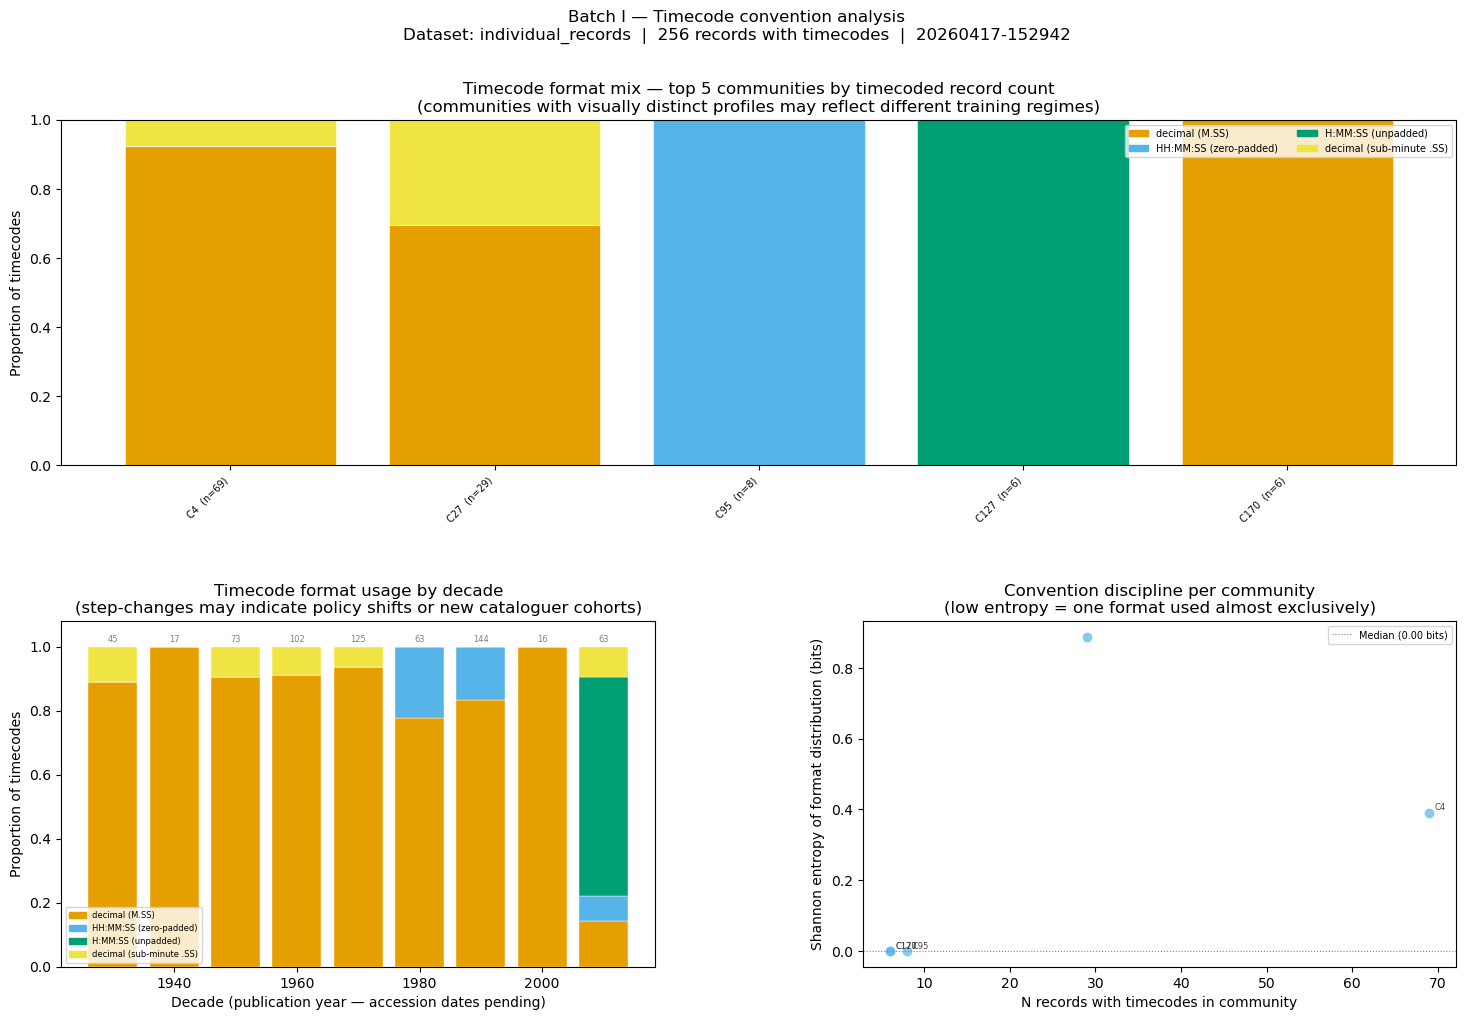

Saved to: /mnt/c/Users/jwb1n21/Dropbox/root/Southampton/Projects/ERC/code/visualisations/timecode-conventions_individual_records_20260417-152942.png

Key interpretive questions:
  Panel 1: Do communities show markedly different colour profiles?
           Distinct profiles → format convention is community-specific
           (evidence of distinct training regimes or working groups).

  Panel 2: Is there a step-change in format proportions at a particular decade?
           If so, this suggests a policy shift or new cataloguer cohort.
           Compare to accession dates once available from primary research.

  Panel 3: Communities near the x-axis (low entropy) use one format almost
           exclusively — possibly a single cataloguer or tightly supervised
           team. High-entropy, large communities may contain sub-groups.

  Chi-square result: Cramér's V = 0.836, p = 2.083e-65
  This is the headline statistic for the convention-divergence argument.


In [35]:
# ── Batch I figure: format distributions + temporal drift + entropy scatter ─────
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np

# Colour map: one colour per format family, consistent across all panels
fmt_colors = {f: PALETTE[i % len(PALETTE)] for i, f in enumerate(fmts_trimmed)}

# Graceful fallback: RUN_DATETIME is defined only when the session cell is run.
# When resuming from a prior run (session cell skipped), derive a label from
# the communities TSV mtime so figures are still timestamped consistently.
if 'RUN_DATETIME' in globals():
    _run_label = RUN_DATETIME
else:
    _mtime = os.path.getmtime(COMMUNITIES_TSV)
    _run_label = datetime.datetime.fromtimestamp(_mtime).strftime('%Y%m%d-%H%M%S') + ' (resumed)'

fig = plt.figure(figsize=(18, 11))
fig.suptitle(
    f'Batch I — Timecode convention analysis\n'
    f'Dataset: {DATASET_NAME}  |  {len(tc_with)} records with timecodes  |  {_run_label}',
    fontsize=12
)
gs = fig.add_gridspec(2, 2, hspace=0.45, wspace=0.35)
ax_bar  = fig.add_subplot(gs[0, :])   # full-width: stacked bar per community
ax_time = fig.add_subplot(gs[1, 0])   # format usage by decade
ax_ent  = fig.add_subplot(gs[1, 1])   # entropy vs community size

# ── Panel 1: stacked proportional bar — top communities by timecoded record count
TOP_N = min(20, len(eligible))
top_comms = entropy_df.nlargest(TOP_N, 'n_timecoded').reset_index(drop=True)

bar_data  = np.array([[comm_fmt[cid].get(f, 0) for f in fmts_trimmed]
                       for cid in top_comms['community_id']], dtype=float)
row_sums  = bar_data.sum(axis=1, keepdims=True)
bar_props = np.divide(bar_data, row_sums, where=row_sums > 0)

x       = np.arange(len(top_comms))
bottoms = np.zeros(len(top_comms))
for j, fmt in enumerate(fmts_trimmed):
    ax_bar.bar(x, bar_props[:, j], bottom=bottoms,
               color=fmt_colors[fmt], label=fmt, edgecolor='white', linewidth=0.4)
    bottoms += bar_props[:, j]

ax_bar.set_xticks(x)
ax_bar.set_xticklabels(
    [f"C{int(c)}  (n={int(n)})"
     for c, n in zip(top_comms['community_id'], top_comms['n_timecoded'])],
    rotation=45, ha='right', fontsize=7
)
ax_bar.set_ylabel('Proportion of timecodes')
ax_bar.set_ylim(0, 1)
ax_bar.set_title(
    f'Timecode format mix — top {TOP_N} communities by timecoded record count\n'
    f'(communities with visually distinct profiles may reflect different training regimes)'
)
legend_patches = [mpatches.Patch(color=fmt_colors[f], label=f) for f in fmts_trimmed]
ax_bar.legend(handles=legend_patches, loc='upper right', fontsize=7, ncol=2)

# ── Panel 2: format usage by publication decade ────────────────────────────────
tc_yr = tc_with.dropna(subset=['year']).copy()
tc_yr['decade'] = (tc_yr['year'] // 10 * 10).astype(int)

decade_fmt = {}
for dec, grp in tc_yr.groupby('decade'):
    counts = Counter()
    for d in grp['format_counts']:
        counts.update({f: v for f, v in d.items() if f in fmts_trimmed})
    decade_fmt[dec] = counts

decades     = sorted(decade_fmt)
decade_arr  = np.array([[decade_fmt[d].get(f, 0) for f in fmts_trimmed]
                         for d in decades], dtype=float)
dec_sums    = decade_arr.sum(axis=1, keepdims=True)
decade_norm = np.divide(decade_arr, dec_sums, where=dec_sums > 0)

bottoms2 = np.zeros(len(decades))
for j, fmt in enumerate(fmts_trimmed):
    ax_time.bar(decades, decade_norm[:, j], bottom=bottoms2,
                color=fmt_colors[fmt], label=fmt, width=8,
                edgecolor='white', linewidth=0.3)
    bottoms2 += decade_norm[:, j]

# Annotate bars with record counts
for dec, s in zip(decades, dec_sums.flatten()):
    ax_time.text(dec, 1.01, str(int(s)), ha='center', va='bottom', fontsize=6, color='grey')

ax_time.set_xlabel('Decade (publication year — accession dates pending)')
ax_time.set_ylabel('Proportion of timecodes')
ax_time.set_ylim(0, 1.08)
ax_time.set_title(
    'Timecode format usage by decade\n'
    '(step-changes may indicate policy shifts or new cataloguer cohorts)'
)
ax_time.legend(handles=legend_patches, fontsize=6, loc='lower left', ncol=1)

# ── Panel 3: entropy vs community size scatter ─────────────────────────────────
ax_ent.scatter(
    entropy_df['n_timecoded'], entropy_df['entropy_bits'],
    c=PALETTE[1], alpha=0.7, edgecolors='white', linewidths=0.5, s=55
)
# Label outliers: very low entropy or large communities
thresh_size = entropy_df['n_timecoded'].quantile(0.80)
for _, erow in entropy_df.iterrows():
    if erow['entropy_bits'] < 0.5 or erow['n_timecoded'] >= thresh_size:
        ax_ent.annotate(
            f"C{int(erow['community_id'])}",
            (erow['n_timecoded'], erow['entropy_bits']),
            fontsize=6, xytext=(4, 2), textcoords='offset points', color='#444'
        )
ax_ent.axhline(entropy_df['entropy_bits'].median(), color='grey',
               linestyle=':', linewidth=0.8, label=f'Median ({entropy_df["entropy_bits"].median():.2f} bits)')
ax_ent.set_xlabel('N records with timecodes in community')
ax_ent.set_ylabel('Shannon entropy of format distribution (bits)')
ax_ent.set_title(
    'Convention discipline per community\n'
    '(low entropy = one format used almost exclusively)'
)
ax_ent.legend(fontsize=7)

plot_path = os.path.join(VIS_DIR, f'timecode-conventions_{DATASET_NAME}_{_run_label}.png')
plt.savefig(plot_path, dpi=150, bbox_inches='tight')
plt.show()
print(f"Saved to: {os.path.abspath(plot_path)}")
print()
print("Key interpretive questions:")
print("  Panel 1: Do communities show markedly different colour profiles?")
print("           Distinct profiles → format convention is community-specific")
print("           (evidence of distinct training regimes or working groups).")
print()
print("  Panel 2: Is there a step-change in format proportions at a particular decade?")
print("           If so, this suggests a policy shift or new cataloguer cohort.")
print("           Compare to accession dates once available from primary research.")
print()
print("  Panel 3: Communities near the x-axis (low entropy) use one format almost")
print("           exclusively — possibly a single cataloguer or tightly supervised")
print("           team. High-entropy, large communities may contain sub-groups.")
if not np.isnan(cramers_v):
    print()
    print(f"  Chi-square result: Cramér's V = {cramers_v:.3f}, p = {p_chi2:.4g}")
    print("  This is the headline statistic for the convention-divergence argument.")

---
## Suggested next analytical steps

The current batches (A–I) establish community existence, profile communities by knowledge-labour
features, visualise the network, characterise hub and bridge nodes, cross-validate the similarity
metric, validate that communities reflect practice rather than subject matter, test whether
year-of-creation is a content or practice proxy, and analyse timecode format conventions as
micro-level evidence of distinct training regimes. The steps below deepen the interpretive
argument.

**1. Within-community TF-IDF language analysis**
Apply TF-IDF to `description_text` *within* each community to extract the words and phrases most
over-represented in each community relative to the corpus as a whole. This produces the linguistic
fingerprint of each cataloguing community — the distinctive phrasing, genre formulas, and
descriptive habits that set it apart — and provides direct textual evidence for the central
knowledge-labour argument.

**2. Isolated record analysis**
Records not assigned to any community (no above-threshold matches in Batch B) form a structurally
distinct group. Profile them separately — comparing their knowledge-labour features to community
members — to assess whether isolation is a data quality signal (very short or boilerplate records)
or a substantive finding (records produced by a cataloguer whose style leaves no trace elsewhere).

**3. Full-dataset run**
Change `RECORDS_DIR` in `pairwise_comparison_v4.ipynb` to the full-dataset directory and re-run
the pairwise computation, then re-run this notebook. All filenames update automatically via
`DATASET_NAME`. Community structure at full scale may differ substantially from the sample:
communities may merge, split, or reveal sub-structure, and new communities may emerge from records
not present in the sample. The null model test and TF-IDF cross-validation should both be re-run
at full scale before drawing final conclusions.

**4. Qualitative close-reading**
Select one record from each community that sits near the community centroid (high within-community
similarity, low between-community similarity) and one that sits on the periphery (high
between-community betweenness). Read both records in full and assess whether the community
assignment makes interpretive sense. This qualitative check is the final step before writing up:
it anchors the statistical structure in the actual language of the catalogue.